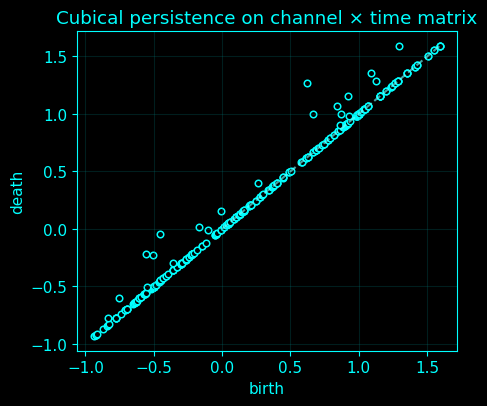

In [86]:
# Method 76: Cubical persistence on channel-time matrices

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_076():

    i = 76
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    nr, nc = _TOPO_IMG
    A = signal.resample(_topo_x.T, nc, axis=1)
    A = signal.resample(A, nr, axis=0)
    dg = _cubical_ph(A)
    _plot_diag(dg[1], 'Cubical persistence on channel × time matrix')
    return


_topology_method_076()
del _topology_method_076


### 77. Cubical persistence on EEG topographic maps

Alpha-band channel powers are interpolated onto the electrode disk and analyzed as a cubical scalar field. The interpolation provides a sampled scalp surface; persistence belongs to that interpolated field and is therefore a finite-resolution topographic estimate, not an invariant of the continuous scalp.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


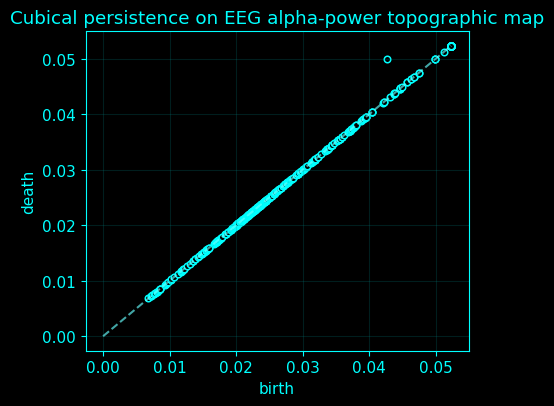

In [87]:
# Method 77: Cubical persistence on EEG topographic maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_077():

    i = 77
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    _plot_diag(dg[1], 'Cubical persistence on EEG alpha-power topographic map')
    return


_topology_method_077()
del _topology_method_077


### 78. Cubical persistence on bandpower topomaps

For each canonical frequency band, channel bandpower \(P_i=\int_{f_1}^{f_2}S_i(f)\,df\) is interpolated to a scalp map and converted to a cubical filtration. Comparing persistence summaries across bands measures changes in the topology of spatial power fields.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,band,H1_total,H1_max,entropy,count
0,delta,1.014372e-03,1.014372e-03,-1.000089e-12,1.0
1,theta,2.934364e-04,2.797985e-04,1.880073e-01,2.0
2,alpha,7.190156e-03,7.190156e-03,-1.000089e-12,1.0
3,beta,1.562260e-07,1.562260e-07,-1.000089e-12,1.0
4,gamma,2.889108e-04,2.889108e-04,-1.000089e-12,1.0


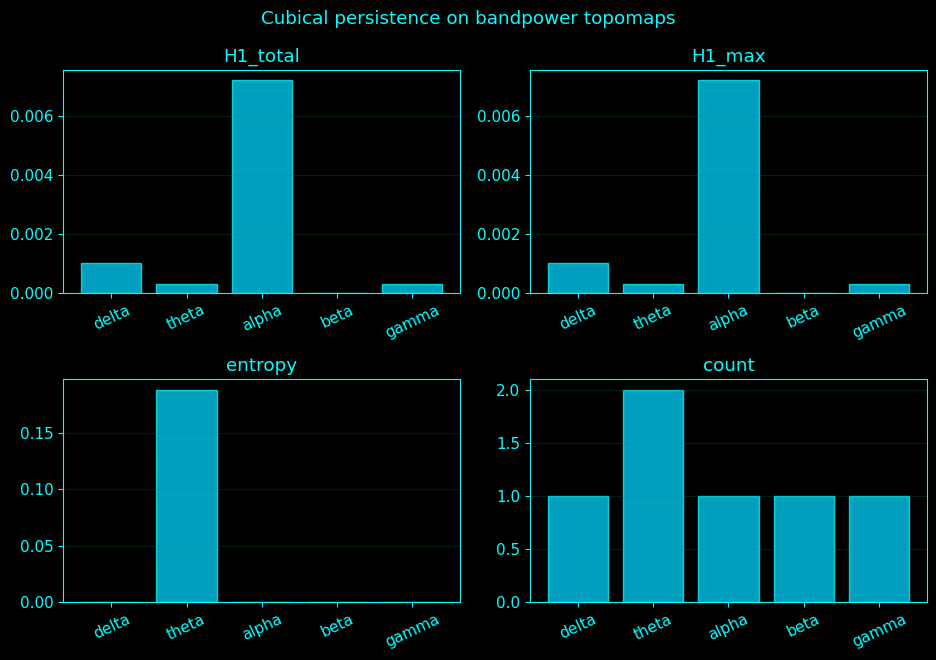

In [88]:
# Method 78: Cubical persistence on bandpower topomaps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_078():

    i = 78
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _feat(dgms):
        h1=dgms[1] if len(dgms)>1 else np.empty((0,2)); L=_life(h1)
        return np.array([L.sum(), L.max() if len(L) else 0.0, _pentropy(h1), float(len(L))])

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method mathematics and output.
    rows = []
    for bn, (lo, hi) in _TOPO_BANDS.items():
        if hi >= _topo_fs / 2:
            continue
        bp = _bandpower_values(_topo_x, lo, hi)
        _, _, Z, _ = _scalp_grid(bp, 25)
        dg = _cubical_ph(np.nan_to_num(Z, nan=np.nanmax(Z)))
        rows.append([bn, *_feat(dg)])
    out = pd.DataFrame(rows, columns=['band', 'H1_total', 'H1_max', 'entropy', 'count'])
    display(out)
    fig, axs = plt.subplots(2, 2, figsize=(9.5, 6.7), facecolor=TOPO_BG)
    axs = np.ravel(axs)
    for ax, col in zip(axs, ['H1_total', 'H1_max', 'entropy', 'count']):
        ax.bar(out['band'], out[col].to_numpy(float), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=25)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Cubical persistence on bandpower topomaps')
    plt.tight_layout()
    plt.show()
    return


_topology_method_078()
del _topology_method_078


### 79. Cubical persistence on coherence maps

Pairwise magnitude-squared coherence forms a symmetric matrix \(C_{ij}\in[0,1]\). The cell analyzes **superlevel** structure by applying cubical lower-star persistence to \(-C\), so large coherence values enter first.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


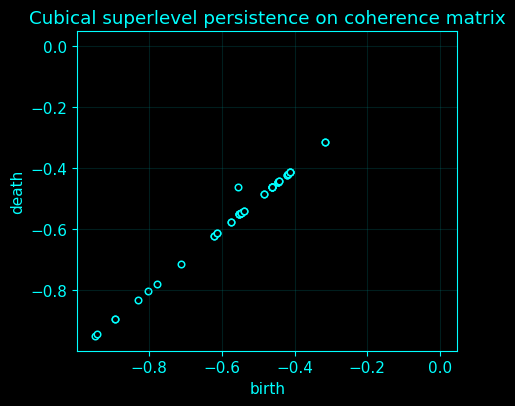

In [89]:
# Method 79: Cubical persistence on coherence maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_079():

    i = 79
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _fc_mats(seg):
        seg=np.asarray(seg,float); C=np.nan_to_num(np.corrcoef(seg.T));
        # coherence in alpha band
        n=seg.shape[1]; COH=np.eye(n); PLV=np.eye(n); PLI=np.eye(n); MI=np.eye(n)
        lo,hi=8,min(13,_topo_fs/2-.5); fil=np.column_stack([_filter_band(seg[:,j],lo,hi) for j in range(n)]) if hi>lo else seg
        ph=np.angle(signal.hilbert(fil,axis=0))
        # discretized MI on z-scored amplitudes
        bins=np.linspace(-2.5,2.5,9)
        disc=np.clip(np.digitize(seg,bins),0,len(bins))
        for i in range(n):
            for j in range(i+1,n):
                f,co=signal.coherence(seg[:,i],seg[:,j],fs=_topo_fs,nperseg=min(256,len(seg))); m=(f>=lo)&(f<=hi); cv=float(np.nanmean(co[m])) if np.any(m) else 0
                d=ph[:,i]-ph[:,j]; pv=abs(np.mean(np.exp(1j*d))); pli=abs(np.mean(np.sign(np.sin(d))))
                mi=mutual_info_score(disc[:,i],disc[:,j]);
                for M,v in [(COH,cv),(PLV,pv),(PLI,pli),(MI,mi)]: M[i,j]=M[j,i]=v
        if np.max(MI)>0: MI=MI/np.max(MI)
        return C,COH,PLV,PLI,MI

    def _fc_small(kind='coh'):
        nch=min(_topo_x.shape[1],18 if FAST_OPTION=='full' else 14 if FAST_OPTION=='balanced' else 10 if FAST_OPTION=='fast' else 8)
        seg=_topo_x[:, :nch]; C,COH,PLV,PLI,MI=_fc_mats(seg)
        return {'corr':C,'coh':COH,'plv':PLV,'pli':PLI,'mi':MI}[kind]

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    A = _fc_small('coh')
    dg = _cubical_ph(-A)
    _plot_diag(dg[1], 'Cubical superlevel persistence on coherence matrix')
    return


_topology_method_079()
del _topology_method_079


### 80. Cubical persistence on phase-synchrony maps

Phase-locking value is \(\mathrm{PLV}_{ij}=|N^{-1}\sum_t e^{i(\phi_i(t)-\phi_j(t))}|\). Its channel × channel matrix is treated as a scalar image and filtered in descending synchrony via \(-\mathrm{PLV}\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Phase-locking value measures how consistent the phase difference between two signals is across samples, trials, or windows. Each phase difference is converted to a unit complex number on the circle and these vectors are averaged. If phase differences are almost identical, the vectors point in the same direction and the average magnitude approaches one. If phase differences are widely spread, they cancel and the magnitude approaches zero. PLV ignores amplitude and does not establish causal influence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


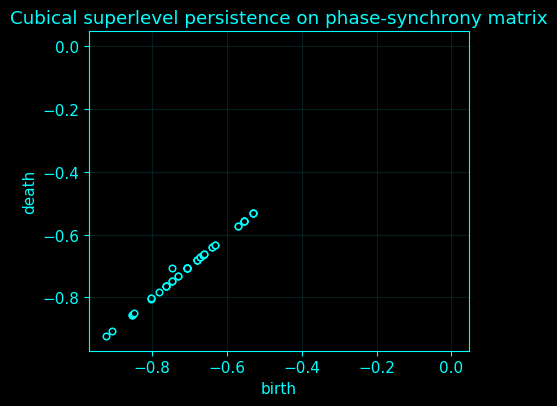

In [90]:
# Method 80: Cubical persistence on phase-synchrony maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_080():

    i = 80
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _fc_mats(seg):
        seg=np.asarray(seg,float); C=np.nan_to_num(np.corrcoef(seg.T));
        # coherence in alpha band
        n=seg.shape[1]; COH=np.eye(n); PLV=np.eye(n); PLI=np.eye(n); MI=np.eye(n)
        lo,hi=8,min(13,_topo_fs/2-.5); fil=np.column_stack([_filter_band(seg[:,j],lo,hi) for j in range(n)]) if hi>lo else seg
        ph=np.angle(signal.hilbert(fil,axis=0))
        # discretized MI on z-scored amplitudes
        bins=np.linspace(-2.5,2.5,9)
        disc=np.clip(np.digitize(seg,bins),0,len(bins))
        for i in range(n):
            for j in range(i+1,n):
                f,co=signal.coherence(seg[:,i],seg[:,j],fs=_topo_fs,nperseg=min(256,len(seg))); m=(f>=lo)&(f<=hi); cv=float(np.nanmean(co[m])) if np.any(m) else 0
                d=ph[:,i]-ph[:,j]; pv=abs(np.mean(np.exp(1j*d))); pli=abs(np.mean(np.sign(np.sin(d))))
                mi=mutual_info_score(disc[:,i],disc[:,j]);
                for M,v in [(COH,cv),(PLV,pv),(PLI,pli),(MI,mi)]: M[i,j]=M[j,i]=v
        if np.max(MI)>0: MI=MI/np.max(MI)
        return C,COH,PLV,PLI,MI

    def _fc_small(kind='coh'):
        nch=min(_topo_x.shape[1],18 if FAST_OPTION=='full' else 14 if FAST_OPTION=='balanced' else 10 if FAST_OPTION=='fast' else 8)
        seg=_topo_x[:, :nch]; C,COH,PLV,PLI,MI=_fc_mats(seg)
        return {'corr':C,'coh':COH,'plv':PLV,'pli':PLI,'mi':MI}[kind]

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    A = _fc_small('plv')
    dg = _cubical_ph(-A)
    _plot_diag(dg[1], 'Cubical superlevel persistence on phase-synchrony matrix')
    return


_topology_method_080()
del _topology_method_080


### 81. Cubical persistence on recurrence plots

A recurrence plot is built from pairwise distances between delay vectors. Cubical persistence on the distance image tracks connected low-distance recurrence regions and holes as the recurrence-distance threshold increases.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Recurrence analysis compares pairs of reconstructed states and marks them as recurrent when their distance is below a chosen threshold. The recurrence rate is simply the fraction of state pairs that satisfy this condition. Diagonal line structures indicate that similar state sequences evolve in similar ways for several steps, which motivates determinism-related measures. Vertical line structures indicate that the trajectory stays near a region of state space for several samples, which motivates laminarity-related measures. These quantities depend on embedding choices, distance scaling, and the recurrence threshold, so those settings should be held consistent when channels are compared.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


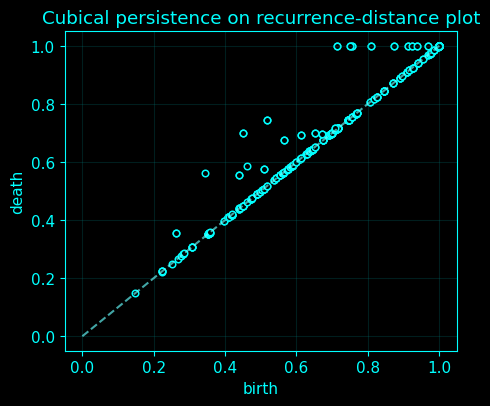

In [91]:
# Method 81: Cubical persistence on recurrence plots

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_081():

    i = 81
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _recurrence_image(y):
        X=_delay_embed(y,m=3,tau=max(1,int(.008*_topo_fs)),max_points=_TOPO_IMG[1])
        D=squareform(pdist(X)); s=np.quantile(D[D>0],.9) if np.any(D>0) else 1.0
        return np.clip(D/(s+TOPO_EPS),0,1)

    # Method mathematics and output.
    R = _recurrence_image(_topo_pc1)
    dg = _cubical_ph(R)
    _plot_diag(dg[1], 'Cubical persistence on recurrence-distance plot')
    return


_topology_method_081()
del _topology_method_081


### 82. Persistent homology of STFT spectrograms

STFT persistence here emphasizes **high-energy** time–frequency regions. Applying lower-star persistence to minus log STFT power is equivalent to a superlevel filtration of the original energy field: energetic peaks and ridges enter before background.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


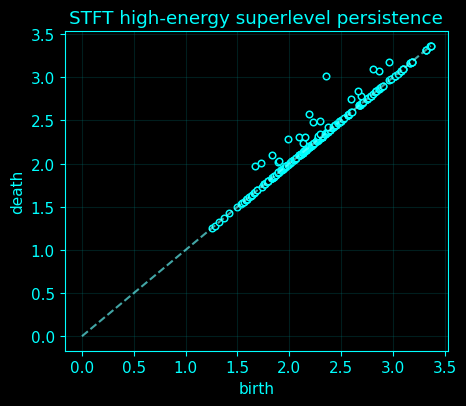

In [92]:
# Method 82: Persistent homology of STFT spectrograms

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_082():

    i = 82
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)

    # Method mathematics and output.
    dg = _cubical_ph(-_TOPO_SPEC)
    _plot_diag(dg[1], 'STFT high-energy superlevel persistence')
    return


_topology_method_082()
del _topology_method_082


### 83. Persistent homology of CWT scalograms

CWT persistence uses the same superlevel convention on Morlet scalogram energy. Persistent components or holes therefore summarize coherent high-energy wavelet structures across time and scale.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


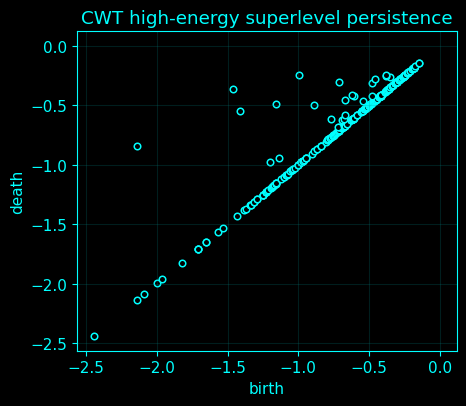

In [93]:
# Method 83: Persistent homology of CWT scalograms

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_083():

    i = 83
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _cwt_scalogram(y):
        y=np.asarray(y,float); nr,nc=_TOPO_IMG
        freqs=np.geomspace(2,min(40,_topo_fs/2-.5),nr)
        out=[]
        for f in freqs:
            s=max(2.0,6*_topo_fs/(2*np.pi*f)); half=int(min(len(y)//4,max(8,4*s)))
            tt=np.arange(-half,half+1); wav=np.exp(2j*np.pi*f*tt/_topo_fs)*np.exp(-(tt**2)/(2*s*s)); wav/=np.sqrt(np.sum(np.abs(wav)**2)+TOPO_EPS)
            out.append(np.abs(signal.fftconvolve(y,wav,mode='same'))**2)
        A=np.log1p(np.asarray(out)); A=signal.resample(A,nc,axis=1)
        return freqs,np.linspace(0,len(y)/_topo_fs,nc),A

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method-local derived quantities required by this method.
    _TOPO_CWT_F, _TOPO_CWT_T, _TOPO_CWT = _cwt_scalogram(_topo_pc1)

    # Method mathematics and output.
    dg = _cubical_ph(-_TOPO_CWT)
    _plot_diag(dg[1], 'CWT high-energy superlevel persistence')
    return


_topology_method_083()
del _topology_method_083


### 84. Persistent homology of comodulograms

The comodulogram stores phase–amplitude coupling over phase frequency \(f_p\) and amplitude frequency \(f_a\). Coupling is estimated by normalized mean-vector length \(|\langle A(t)e^{i\phi(t)}\rangle|/\langle A(t)\rangle\), and cubical superlevel persistence captures connected PAC regions and holes in this frequency–frequency field.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


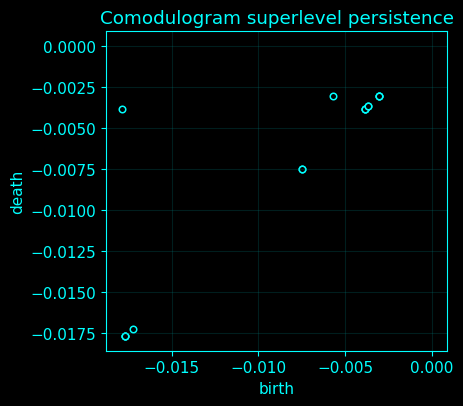

In [94]:
# Method 84: Persistent homology of comodulograms

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_084():

    i = 84
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _pac_comodulogram(y):
        phase_fs=np.array([4,6,8,10,12],float); amp_fs=np.array([18,24,30,36,42],float); A=np.zeros((len(phase_fs),len(amp_fs)))
        ny=_topo_fs/2
        for i,pf in enumerate(phase_fs):
            plo=max(.5,pf-1); phi=min(ny-.2,pf+1)
            if phi<=plo: continue
            ps=signal.butter(3,[plo,phi],btype='bandpass',fs=_topo_fs,output='sos'); ph=np.angle(signal.hilbert(signal.sosfiltfilt(ps,y)))
            for j,af in enumerate(amp_fs):
                alo=max(1,af-3); ahi=min(ny-.2,af+3)
                if ahi<=alo: continue
                aa=signal.butter(3,[alo,ahi],btype='bandpass',fs=_topo_fs,output='sos'); env=np.abs(signal.hilbert(signal.sosfiltfilt(aa,y)))
                # mean-vector-length PAC, normalized by mean amplitude
                A[i,j]=abs(np.mean(env*np.exp(1j*ph)))/(np.mean(env)+TOPO_EPS)
        return phase_fs,amp_fs,A

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    pf, af, A = _pac_comodulogram(_topo_pc1)
    dg = _cubical_ph(-A)
    _plot_diag(dg[1], ('Comodulogram' if i == 84 else 'Phase-amplitude coupling map') + ' superlevel persistence')
    return


_topology_method_084()
del _topology_method_084


### 85. Persistent homology of phase-amplitude coupling maps

The PAC map uses the same mathematically defined phase–amplitude coupling field, but the analysis is interpreted explicitly as topology of the coupling surface. The filtration is descending in PAC strength, implemented by lower-star persistence of the negated map.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


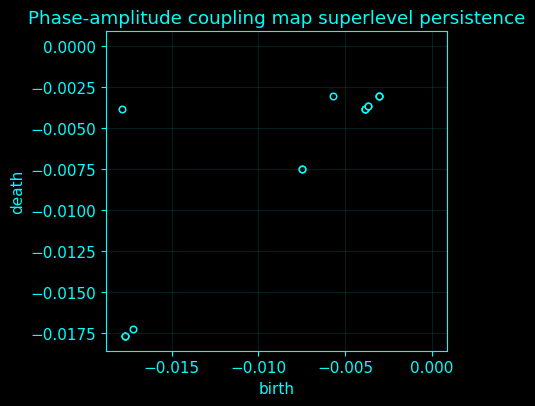

In [95]:
# Method 85: Persistent homology of phase-amplitude coupling maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_085():

    i = 85
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _pac_comodulogram(y):
        phase_fs=np.array([4,6,8,10,12],float); amp_fs=np.array([18,24,30,36,42],float); A=np.zeros((len(phase_fs),len(amp_fs)))
        ny=_topo_fs/2
        for i,pf in enumerate(phase_fs):
            plo=max(.5,pf-1); phi=min(ny-.2,pf+1)
            if phi<=plo: continue
            ps=signal.butter(3,[plo,phi],btype='bandpass',fs=_topo_fs,output='sos'); ph=np.angle(signal.hilbert(signal.sosfiltfilt(ps,y)))
            for j,af in enumerate(amp_fs):
                alo=max(1,af-3); ahi=min(ny-.2,af+3)
                if ahi<=alo: continue
                aa=signal.butter(3,[alo,ahi],btype='bandpass',fs=_topo_fs,output='sos'); env=np.abs(signal.hilbert(signal.sosfiltfilt(aa,y)))
                # mean-vector-length PAC, normalized by mean amplitude
                A[i,j]=abs(np.mean(env*np.exp(1j*ph)))/(np.mean(env)+TOPO_EPS)
        return phase_fs,amp_fs,A

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    pf, af, A = _pac_comodulogram(_topo_pc1)
    dg = _cubical_ph(-A)
    _plot_diag(dg[1], ('Comodulogram' if i == 84 else 'Phase-amplitude coupling map') + ' superlevel persistence')
    return


_topology_method_085()
del _topology_method_085


### 86. Persistent connected components of high-power regions

H0 persistence of the negated spectrogram tracks connected **high-power** components. A component born at a strong local maximum survives until it merges with a stronger component; its lifetime is therefore a multiscale prominence measure for energetic time–frequency regions.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,birth,death,lifetime
54,0.548339,1.578317,1.029978
189,1.176239,2.129196,0.952957
224,1.453416,2.215969,0.762553
43,0.814655,1.509076,0.694421
73,1.023660,1.684202,0.660542
212,1.672578,2.170541,0.497963
109,1.398749,1.852693,0.453943
9,0.746749,1.173202,0.426454
192,1.740586,2.138480,0.397894
13,0.902973,1.274145,0.371172


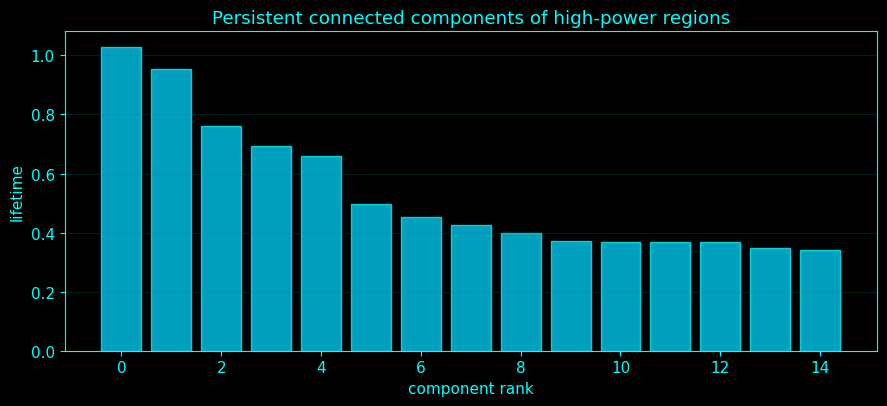

In [96]:
# Method 86: Persistent connected components of high-power regions

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_086():

    i = 86
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)

    # Method mathematics and output.
    dg = _cubical_ph(-_TOPO_SPEC)
    d0 = _finite(dg[0])
    out = pd.DataFrame({'birth': d0[:, 0], 'death': d0[:, 1], 'lifetime': d0[:, 1] - d0[:, 0]}).sort_values('lifetime', ascending=False).head(15)
    display(out)
    if len(out):
        fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=TOPO_BG)
        ax.bar(np.arange(len(out)), out['lifetime'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title('Persistent connected components of high-power regions')
        ax.set_xlabel('component rank')
        ax.set_ylabel('lifetime')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return


_topology_method_086()
del _topology_method_086


### 87. Persistent holes in time-frequency energy

H1 of the high-energy superlevel filtration detects holes enclosed by energetic ridges. A long lifetime \(d-b\) means the hole persists across a wide energy-threshold interval; it should not be interpreted as a literal physical void.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


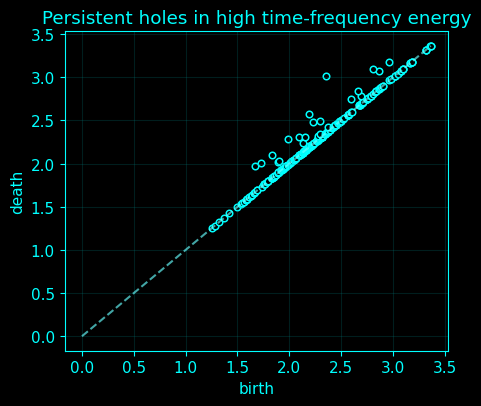

In [97]:
# Method 87: Persistent holes in time-frequency energy

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_087():

    i = 87
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)

    # Method mathematics and output.
    dg = _cubical_ph(-_TOPO_SPEC)
    _plot_diag(dg[1], 'Persistent holes in high time-frequency energy')
    return


_topology_method_087()
del _topology_method_087


### 88. Spectrogram Betti curves

For a persistence diagram \(D_1\), the Betti curve is \(\beta_1(a)=\#\{(b_i,d_i):b_i\le a<d_i\}\). This cell evaluates that curve for the spectrogram filtration.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


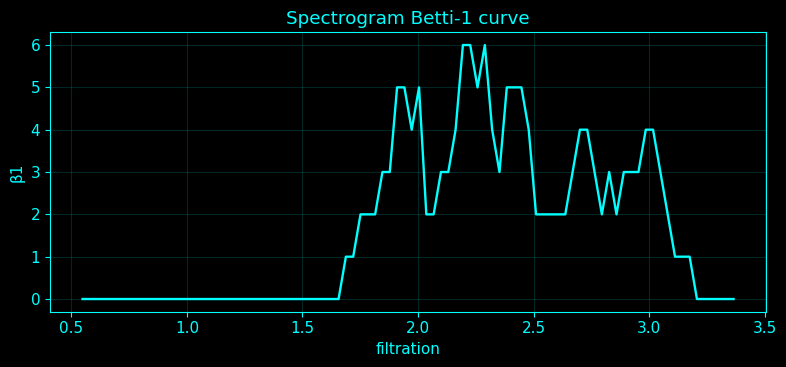

In [98]:
# Method 88: Spectrogram Betti curves

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_088():

    i = 88
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _betti_curve(dgm,epsgrid):
        d=np.asarray(dgm,float).reshape(-1,2)
        if not len(d): return np.zeros_like(epsgrid,float)
        return np.array([np.sum((d[:,0]<=e)&(e<d[:,1])) for e in epsgrid],float)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _cwt_scalogram(y):
        y=np.asarray(y,float); nr,nc=_TOPO_IMG
        freqs=np.geomspace(2,min(40,_topo_fs/2-.5),nr)
        out=[]
        for f in freqs:
            s=max(2.0,6*_topo_fs/(2*np.pi*f)); half=int(min(len(y)//4,max(8,4*s)))
            tt=np.arange(-half,half+1); wav=np.exp(2j*np.pi*f*tt/_topo_fs)*np.exp(-(tt**2)/(2*s*s)); wav/=np.sqrt(np.sum(np.abs(wav)**2)+TOPO_EPS)
            out.append(np.abs(signal.fftconvolve(y,wav,mode='same'))**2)
        A=np.log1p(np.asarray(out)); A=signal.resample(A,nc,axis=1)
        return freqs,np.linspace(0,len(y)/_topo_fs,nc),A

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)
    _TOPO_CWT_F, _TOPO_CWT_T, _TOPO_CWT = _cwt_scalogram(_topo_pc1)
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    A = {88: -_TOPO_SPEC, 89: -_TOPO_CWT, 90: np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP))}[i]
    dg = _cubical_ph(A)
    fin = np.hstack([_finite(d).ravel() for d in dg if len(_finite(d))])
    lo = float(np.min(fin)) if len(fin) else 0
    hi = float(np.max(fin)) if len(fin) else 1
    g = np.linspace(lo, hi, 90)
    _plot_line(g, _betti_curve(dg[1], g), {88: 'Spectrogram', 89: 'Scalogram', 90: 'Topomap'}[i] + ' Betti-1 curve', 'filtration', 'β1')
    return


_topology_method_088()
del _topology_method_088


### 89. Scalogram Betti curves

The scalogram Betti curve applies \(\beta_1(a)\) to the wavelet cubical persistence diagram, giving the number of loop classes alive at each scalar threshold.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


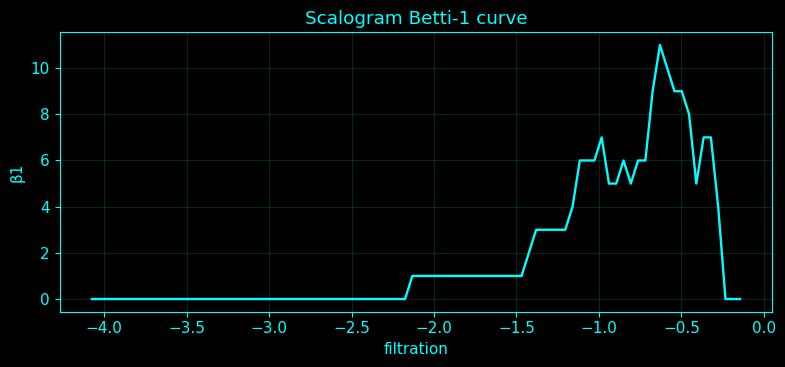

In [99]:
# Method 89: Scalogram Betti curves

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_089():

    i = 89
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _betti_curve(dgm,epsgrid):
        d=np.asarray(dgm,float).reshape(-1,2)
        if not len(d): return np.zeros_like(epsgrid,float)
        return np.array([np.sum((d[:,0]<=e)&(e<d[:,1])) for e in epsgrid],float)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _cwt_scalogram(y):
        y=np.asarray(y,float); nr,nc=_TOPO_IMG
        freqs=np.geomspace(2,min(40,_topo_fs/2-.5),nr)
        out=[]
        for f in freqs:
            s=max(2.0,6*_topo_fs/(2*np.pi*f)); half=int(min(len(y)//4,max(8,4*s)))
            tt=np.arange(-half,half+1); wav=np.exp(2j*np.pi*f*tt/_topo_fs)*np.exp(-(tt**2)/(2*s*s)); wav/=np.sqrt(np.sum(np.abs(wav)**2)+TOPO_EPS)
            out.append(np.abs(signal.fftconvolve(y,wav,mode='same'))**2)
        A=np.log1p(np.asarray(out)); A=signal.resample(A,nc,axis=1)
        return freqs,np.linspace(0,len(y)/_topo_fs,nc),A

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)
    _TOPO_CWT_F, _TOPO_CWT_T, _TOPO_CWT = _cwt_scalogram(_topo_pc1)
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    A = {88: -_TOPO_SPEC, 89: -_TOPO_CWT, 90: np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP))}[i]
    dg = _cubical_ph(A)
    fin = np.hstack([_finite(d).ravel() for d in dg if len(_finite(d))])
    lo = float(np.min(fin)) if len(fin) else 0
    hi = float(np.max(fin)) if len(fin) else 1
    g = np.linspace(lo, hi, 90)
    _plot_line(g, _betti_curve(dg[1], g), {88: 'Spectrogram', 89: 'Scalogram', 90: 'Topomap'}[i] + ' Betti-1 curve', 'filtration', 'β1')
    return


_topology_method_089()
del _topology_method_089


### 90. Topomap Betti curves

The topomap Betti curve counts H1 classes alive as the scalp-field threshold varies. It is a one-dimensional summary of the full topographic persistence diagram.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


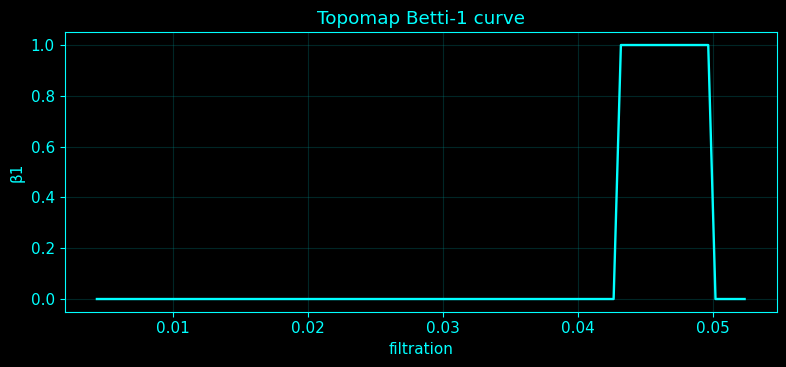

In [100]:
# Method 90: Topomap Betti curves

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_090():

    i = 90
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _betti_curve(dgm,epsgrid):
        d=np.asarray(dgm,float).reshape(-1,2)
        if not len(d): return np.zeros_like(epsgrid,float)
        return np.array([np.sum((d[:,0]<=e)&(e<d[:,1])) for e in epsgrid],float)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _cwt_scalogram(y):
        y=np.asarray(y,float); nr,nc=_TOPO_IMG
        freqs=np.geomspace(2,min(40,_topo_fs/2-.5),nr)
        out=[]
        for f in freqs:
            s=max(2.0,6*_topo_fs/(2*np.pi*f)); half=int(min(len(y)//4,max(8,4*s)))
            tt=np.arange(-half,half+1); wav=np.exp(2j*np.pi*f*tt/_topo_fs)*np.exp(-(tt**2)/(2*s*s)); wav/=np.sqrt(np.sum(np.abs(wav)**2)+TOPO_EPS)
            out.append(np.abs(signal.fftconvolve(y,wav,mode='same'))**2)
        A=np.log1p(np.asarray(out)); A=signal.resample(A,nc,axis=1)
        return freqs,np.linspace(0,len(y)/_topo_fs,nc),A

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)
    _TOPO_CWT_F, _TOPO_CWT_T, _TOPO_CWT = _cwt_scalogram(_topo_pc1)
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    A = {88: -_TOPO_SPEC, 89: -_TOPO_CWT, 90: np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP))}[i]
    dg = _cubical_ph(A)
    fin = np.hstack([_finite(d).ravel() for d in dg if len(_finite(d))])
    lo = float(np.min(fin)) if len(fin) else 0
    hi = float(np.max(fin)) if len(fin) else 1
    g = np.linspace(lo, hi, 90)
    _plot_line(g, _betti_curve(dg[1], g), {88: 'Spectrogram', 89: 'Scalogram', 90: 'Topomap'}[i] + ' Betti-1 curve', 'filtration', 'β1')
    return


_topology_method_090()
del _topology_method_090


### 91. Topomap persistence diagrams

A topomap persistence diagram records each finite H1 class as \((b_i,d_i)\). Distance from the diagonal equals lifetime up to a factor \(1/\sqrt2\), so points far from the diagonal represent spatial loop structure stable over a broader threshold interval.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


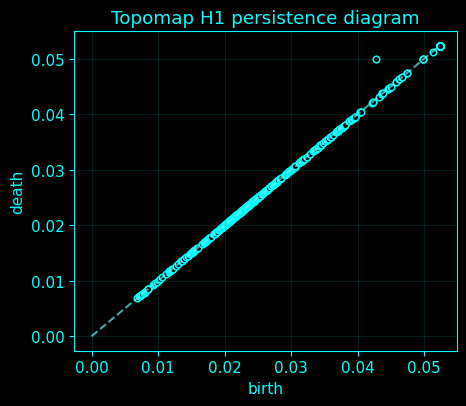

In [101]:
# Method 91: Topomap persistence diagrams

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_091():

    i = 91
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    _plot_diag(dg[1], 'Topomap H1 persistence diagram')
    return


_topology_method_091()
del _topology_method_091


### 92. Topographic persistence entropy

Topographic persistence entropy normalizes H1 lifetimes \(\ell_i=d_i-b_i\) to \(p_i=\ell_i/\sum_j\ell_j\) and computes \(H=-\sum_i p_i\log p_i\). It measures dispersion of persistence across classes, not Shannon entropy of the EEG amplitudes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


In [102]:
# Method 92: Topographic persistence entropy

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_092():

    i = 92
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    print('Topographic H1 persistence entropy =', _pentropy(dg[1]))
    return


_topology_method_092()
del _topology_method_092


Topographic H1 persistence entropy = -1.000088900581841e-12


### 93. Topographic persistence landscapes

A persistence landscape converts each interval \((b_i,d_i)\) to the tent function \(f_i(t)=\max(0,\min(t-b_i,d_i-t))\). The kth landscape \(\lambda_k(t)\) is the kth largest tent value at \(t\), producing stable vector-valued summaries suitable for averaging.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


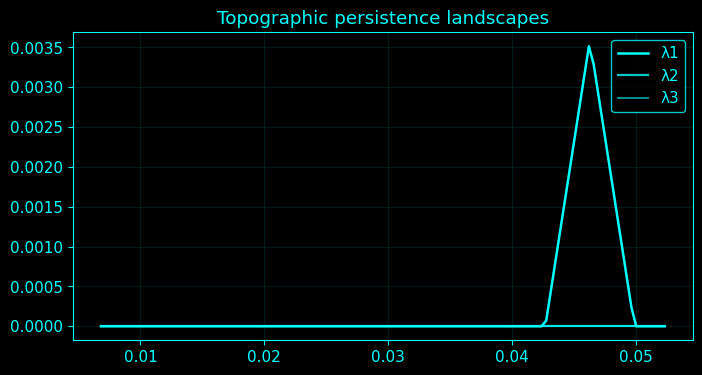

In [103]:
# Method 93: Topographic persistence landscapes

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_093():

    i = 93
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _landscape(dgm,grid,kmax=3):
        d=_finite(dgm); L=np.zeros((kmax,len(grid)))
        for q,t in enumerate(grid):
            tents=np.sort([max(0.0,min(t-b,de-t)) for b,de in d])[::-1]
            L[:min(kmax,len(tents)),q]=tents[:kmax]
        return L

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    d = _finite(dg[1])
    mx = float(np.max(d)) if len(d) else 1.0
    mn = float(np.min(d)) if len(d) else 0.0
    g = np.linspace(mn, mx, 120)
    L = _landscape(dg[1], g, 3)
    fig, ax = plt.subplots(figsize=(8, 4))
    [ax.plot(g, L[k], label=f'λ{k + 1}', color=TOPO_ACCENT, alpha=1 - 0.22 * k, linewidth=1.8 - 0.2 * k) for k in range(3)]
    ax.legend()
    ax.set_title('Topographic persistence landscapes')
    ax.grid(alpha=0.2)
    plt.show()
    return


_topology_method_093()
del _topology_method_093


### 94. Topographic persistence images

A persistence image maps each point to birth–persistence coordinates \((b_i,d_i-b_i)\), places a Gaussian kernel there, weights it by persistence, and sums the kernels on a grid. It is a finite-dimensional smooth representation of the diagram.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


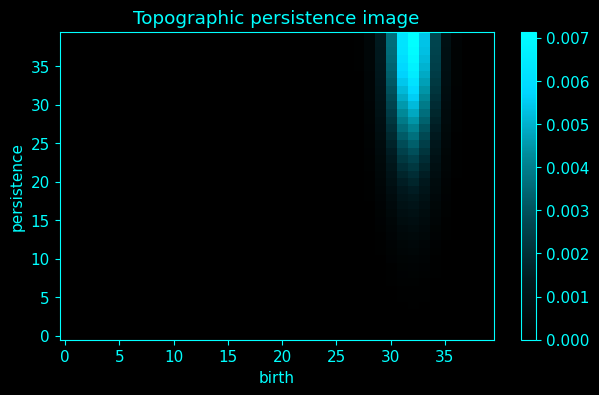

In [104]:
# Method 94: Topographic persistence images

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_094():

    i = 94
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _persistence_image(dgm,n=40,sigma=.04):
        d=_finite(dgm)
        if not len(d): return np.zeros((n,n)),np.linspace(0,1,n),np.linspace(0,1,n)
        bp=np.column_stack([d[:,0],d[:,1]-d[:,0]]); xmax=max(TOPO_EPS,float(np.max(bp[:,0]))); ymax=max(TOPO_EPS,float(np.max(bp[:,1])))
        x=np.linspace(0,xmax,n); y=np.linspace(0,ymax,n); X,Y=np.meshgrid(x,y); I=np.zeros_like(X)
        sig=max(sigma*max(xmax,ymax),TOPO_EPS)
        for b,pers in bp: I += pers*np.exp(-((X-b)**2+(Y-pers)**2)/(2*sig**2))
        return I,x,y

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    I, _, _ = _persistence_image(dg[1])
    _imshow(I, 'Topographic persistence image', 'birth', 'persistence')
    return


_topology_method_094()
del _topology_method_094


### 95. Topological scalp asymmetry

The alpha-power scalp field is split into left and right hemispheric halves; the right half is mirrored into the left coordinate frame. Cubical persistence is computed on both fields, and asymmetry is quantified by differences in the H1 persistence feature vector \(z=[TP_1,L_{\max},H_{pers},N_1]\). This is a topological asymmetry measure rather than a conventional power-ratio asymmetry index.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,feature,left,mirrored_right,absolute_difference
0,H1_total,0.0,0.0,0.0
1,H1_max,0.0,0.0,0.0
2,H1_entropy,0.0,0.0,0.0
3,H1_count,0.0,0.0,0.0


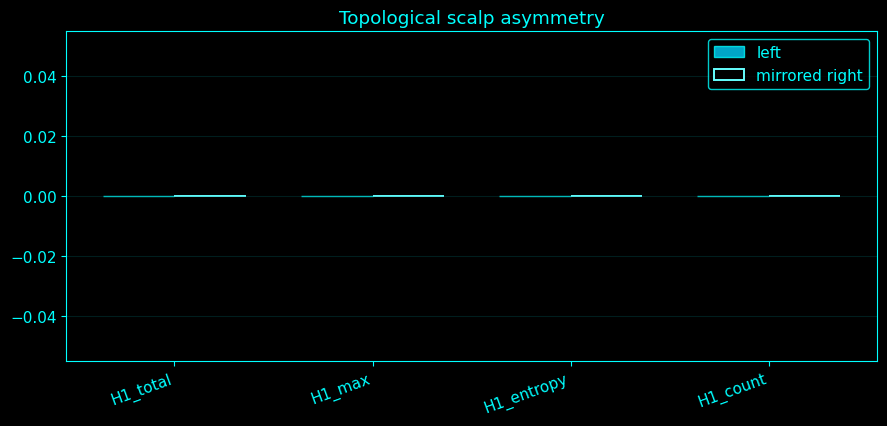

In [105]:
# Method 95: Topological scalp asymmetry

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_095():

    i = 95
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _feat(dgms):
        h1=dgms[1] if len(dgms)>1 else np.empty((0,2)); L=_life(h1)
        return np.array([L.sum(), L.max() if len(L) else 0.0, _pentropy(h1), float(len(L))])

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    Z = _TOPO_TOPOMAP.copy()
    M = _TOPO_SCALP_MASK
    mid = Z.shape[1] // 2
    L = Z[:, :mid + 1]
    ML = M[:, :mid + 1]
    R = np.fliplr(Z[:, -mid - 1:])
    MR = np.fliplr(M[:, -mid - 1:])
    fill = float(np.nanmax(Z))
    dgL = _cubical_ph(np.where(ML, L, fill))
    dgR = _cubical_ph(np.where(MR, R, fill))
    fL = _feat(dgL)
    fR = _feat(dgR)
    out = pd.DataFrame({'feature': ['H1_total', 'H1_max', 'H1_entropy', 'H1_count'], 'left': fL, 'mirrored_right': fR, 'absolute_difference': np.abs(fL - fR)})
    display(out)
    x = np.arange(len(out))
    w = 0.36
    fig, ax = plt.subplots(figsize=(9, 4.4), facecolor=TOPO_BG)
    ax.bar(x - w / 2, out['left'], width=w, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.78, label='left')
    ax.bar(x + w / 2, out['mirrored_right'], width=w, color=TOPO_BG, edgecolor=TOPO_CYAN_SOFT, linewidth=1.4, label='mirrored right')
    ax.set_xticks(x)
    ax.set_xticklabels(out['feature'], rotation=20, ha='right')
    ax.set_title('Topological scalp asymmetry')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_095()
del _topology_method_095


### 96. Topological microstates from scalp maps

Topological microstates cluster sliding-window **topological feature vectors** derived from alpha-power scalp maps. K-means minimizes within-state squared Euclidean dispersion in standardized persistence features; these are topology-derived states, distinct from conventional GFP-peak EEG microstates.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,time_s,topological_microstate
0,1.40,1
1,2.64,3
2,3.88,1
3,5.12,0
4,6.36,1
5,7.60,0
6,8.84,0
7,10.08,0
8,11.32,0
9,12.56,2


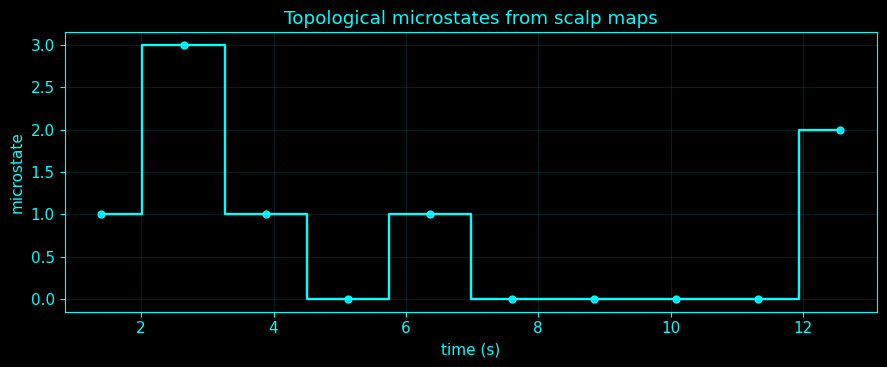

In [106]:
# Method 96: Topological microstates from scalp maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_096():

    i = 96
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _feat(dgms):
        h1=dgms[1] if len(dgms)>1 else np.empty((0,2)); L=_life(h1)
        return np.array([L.sum(), L.max() if len(L) else 0.0, _pentropy(h1), float(len(L))])

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    # Method mathematics and output.
    nw = min(_TOPO_SPEED['windows'], 18)
    feats = []
    times = []
    for st, en, w in _windows(np.arange(len(_topo_x)), nw):
        bp = _bandpower_values(_topo_x[st:en], 8, min(13, _topo_fs / 2 - 0.5))
        _, _, Z, _ = _scalp_grid(bp, 19)
        dg = _cubical_ph(np.nan_to_num(Z, nan=np.nanmax(Z)))
        feats.append(_feat(dg))
        times.append((st + en) / (2 * _topo_fs))
    Zs = np.asarray(feats)
    k = min(4, len(Zs))
    lab = KMeans(k, n_init=10, random_state=0).fit_predict((Zs - Zs.mean(0)) / (Zs.std(0) + TOPO_EPS))
    out = pd.DataFrame({'time_s': times, 'topological_microstate': lab})
    display(out)
    fig, ax = plt.subplots(figsize=(9, 3.8), facecolor=TOPO_BG)
    ax.step(out['time_s'], out['topological_microstate'], where='mid', color=TOPO_ACCENT, linewidth=1.7)
    ax.scatter(out['time_s'], out['topological_microstate'], s=24, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT)
    ax.set_title('Topological microstates from scalp maps')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('microstate')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_096()
del _topology_method_096


### 97. Euler characteristic curves

For a finite cubical complex, Euler characteristic is \(\chi=V-E+F\). Thresholding a scalar field at successive levels yields the Euler characteristic curve \(\chi(a)\), a fast topological summary related to alternating Betti numbers \(\chi=\beta_0-\beta_1\) in a planar complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


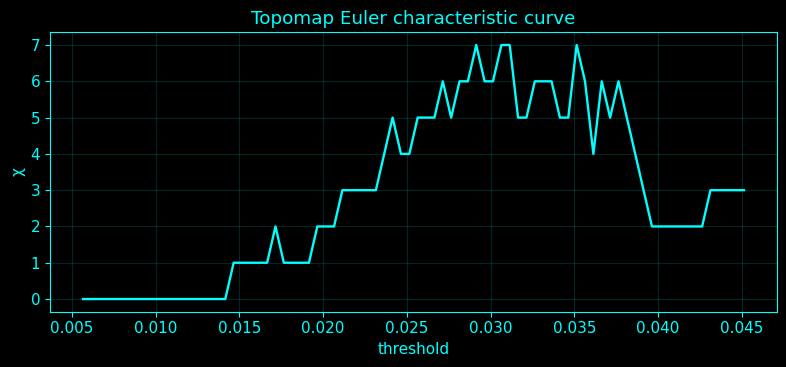

In [107]:
# Method 97: Euler characteristic curves

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_097():

    i = 97
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    g, chi = _ec_curve_field(_TOPO_TOPOMAP, superlevel=True)
    _plot_line(g, chi, 'Topomap Euler characteristic curve', 'threshold', 'χ')
    return


_topology_method_097()
del _topology_method_097


### 98. Euler characteristic surfaces

An Euler characteristic surface records \(\chi(t,a)\) over both time window \(t\) and scalar threshold \(a\). It is the Euler analogue of a CROCKER surface: changes indicate time-varying topology of thresholded time–frequency fields.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


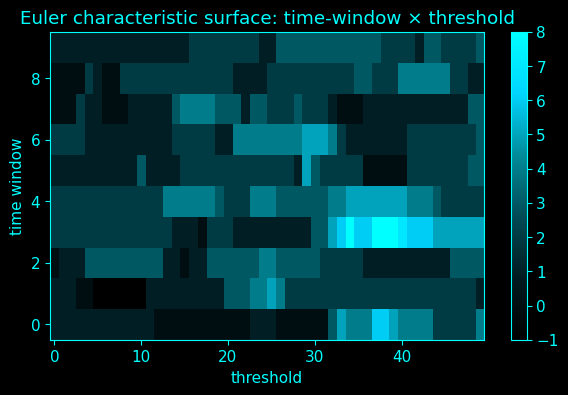

In [108]:
# Method 98: Euler characteristic surfaces

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_098():

    i = 98
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    # Method mathematics and output.
    nw = min(_TOPO_SPEED['windows'], 14)
    rows = []
    for a, (st, en, w) in enumerate(_windows(_topo_pc1, nw)):
        _, _, A = _tf_spectrogram(w)
        g, c = _ec_curve_field(A, grid=np.linspace(np.quantile(A, 0.1), np.quantile(A, 0.9), 50), superlevel=True)
        rows.append(c)
    _imshow(np.asarray(rows), 'Euler characteristic surface: time-window × threshold', 'threshold', 'time window')
    return


_topology_method_098()
del _topology_method_098


### 99. Euler characteristic transform

The Euler characteristic transform (ECT) maps a shape to Euler curves of directional height filtrations. For direction \(u\), \(ECT(u,t)=\chi(K\cap\{x:u\cdot x\le t\})\). The cell applies this to the high-alpha cubical scalp region over multiple planar directions.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


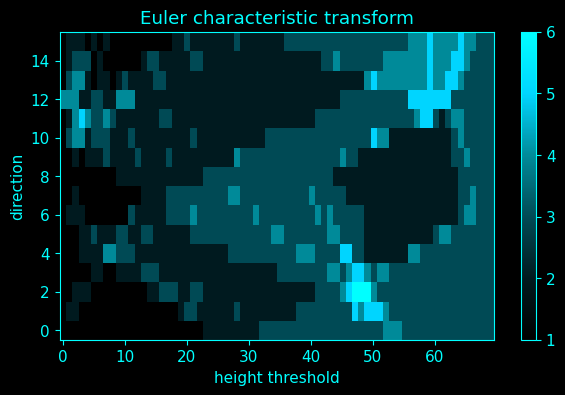

In [109]:
# Method 99: Euler characteristic transform

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_099():

    i = 99
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ect_from_mask(mask,Xg,Yg,nang=12,nlev=60):
        mask=np.asarray(mask,bool); ang=np.linspace(0,np.pi,nang,endpoint=False); out=[]
        for th in ang:
            H=Xg*np.cos(th)+Yg*np.sin(th); hv=H[mask]
            levels=np.linspace(float(hv.min()),float(hv.max()),nlev) if len(hv) else np.linspace(-1,1,nlev)
            out.append([_ec_binary_vertices(mask & (H<=u)) for u in levels])
        return ang,np.asarray(out,float)

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    mask = _TOPO_SCALP_MASK & (_TOPO_TOPOMAP >= np.nanmedian(_TOPO_TOPOMAP))
    ang, E = _ect_from_mask(mask, _TOPO_XG, _TOPO_YG, nang=16, nlev=70)
    _imshow(E, 'Smooth Euler characteristic transform' if i == 100 else 'Euler characteristic transform', 'height threshold', 'direction')
    return


_topology_method_099()
del _topology_method_099


### 100. Smooth Euler characteristic transform

The smooth ECT convolves each directional Euler curve along its threshold coordinate with a Gaussian kernel. Smoothing reduces discretization jumps while preserving the directional organization; it is a regularized descriptor rather than a new topological invariant.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


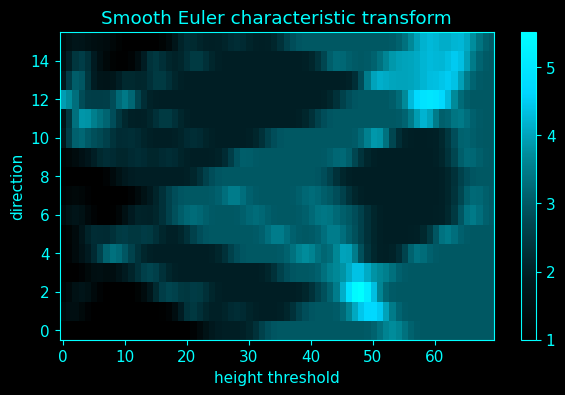

In [110]:
# Method 100: Smooth Euler characteristic transform

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_100():

    i = 100
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ect_from_mask(mask,Xg,Yg,nang=12,nlev=60):
        mask=np.asarray(mask,bool); ang=np.linspace(0,np.pi,nang,endpoint=False); out=[]
        for th in ang:
            H=Xg*np.cos(th)+Yg*np.sin(th); hv=H[mask]
            levels=np.linspace(float(hv.min()),float(hv.max()),nlev) if len(hv) else np.linspace(-1,1,nlev)
            out.append([_ec_binary_vertices(mask & (H<=u)) for u in levels])
        return ang,np.asarray(out,float)

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    mask = _TOPO_SCALP_MASK & (_TOPO_TOPOMAP >= np.nanmedian(_TOPO_TOPOMAP))
    ang, E = _ect_from_mask(mask, _TOPO_XG, _TOPO_YG, nang=16, nlev=70)
    E = gaussian_filter1d(E, sigma=1.4, axis=1, mode='nearest')
    _imshow(E, 'Smooth Euler characteristic transform' if i == 100 else 'Euler characteristic transform', 'height threshold', 'direction')
    return


_topology_method_100()
del _topology_method_100


### 101. Euler integral summaries

For a nonnegative tame function, one upper-Euler-integral convention is \(\int f\,\lceil d\chi\rceil=\int_0^\infty \chi(\{f\ge u\})\,du\). The notebook approximates this threshold integral numerically after rescaling the spectrogram field to \([0,1]\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [111]:
# Method 101: Euler integral summaries

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_101():

    i = 101
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)

    # Method mathematics and output.
    A = _TOPO_SPEC - np.nanmin(_TOPO_SPEC)
    A = A / (np.nanmax(A) + TOPO_EPS)
    u, chi = _ec_curve_field(A, grid=np.linspace(0, 1, 100), superlevel=True)
    eint = float(np.trapezoid(chi, u))
    print('Upper Euler integral approximation ∫ χ({f≥u}) du =', eint)
    return


_topology_method_101()
del _topology_method_101


Upper Euler integral approximation ∫ χ({f≥u}) du = 3.964646464646465


### 102. Euler curves for bandpower topomaps

Bandpower topomap Euler curves apply \(\chi(a)=V(a)-E(a)+F(a)\) separately to each band-specific spatial power field. Integrals and extrema of the curves provide compact cross-band topological summaries.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,band,Euler_curve_integral,chi_max,chi_min
0,delta,0.859746,8.0,-1.0
1,theta,0.241706,9.0,0.0
2,alpha,0.127036,7.0,0.0
3,beta,0.184508,5.0,-1.0
4,gamma,0.138229,6.0,-1.0


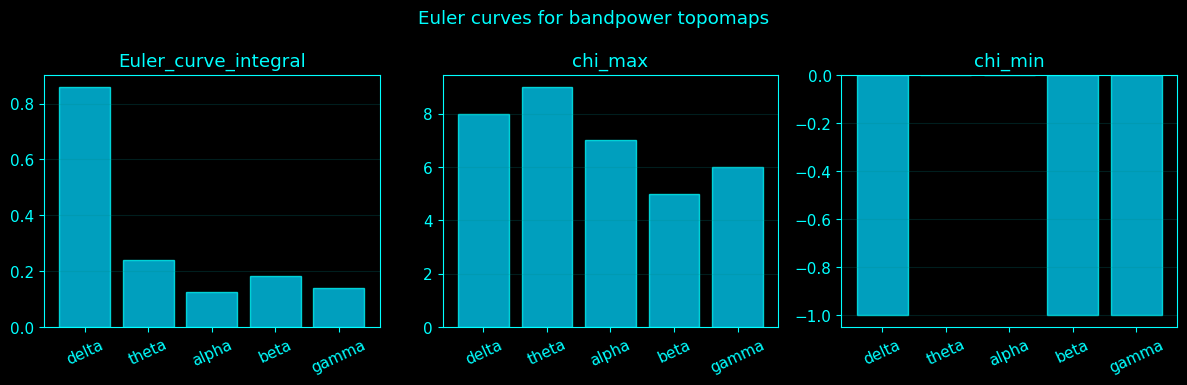

In [112]:
# Method 102: Euler curves for bandpower topomaps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_102():

    i = 102
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method mathematics and output.
    rows = []
    for bn, (lo, hi) in _TOPO_BANDS.items():
        if hi >= _topo_fs / 2:
            continue
        _, _, Z, _ = _scalp_grid(_bandpower_values(_topo_x, lo, hi), 21)
        g, c = _ec_curve_field(Z, superlevel=True)
        rows.append([bn, float(np.trapezoid(c, g)), float(np.max(c)), float(np.min(c))])
    out = pd.DataFrame(rows, columns=['band', 'Euler_curve_integral', 'chi_max', 'chi_min'])
    display(out)
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.9), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['Euler_curve_integral', 'chi_max', 'chi_min']):
        ax.bar(out['band'], out[col], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=25)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Euler curves for bandpower topomaps')
    plt.tight_layout()
    plt.show()
    return


_topology_method_102()
del _topology_method_102


### 103. Euler curves for spectrograms

The spectrogram Euler curve thresholds the time–frequency scalar field directly and computes cubical Euler characteristic at each threshold, avoiding explicit persistence pairing while retaining alternating-Betti information.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


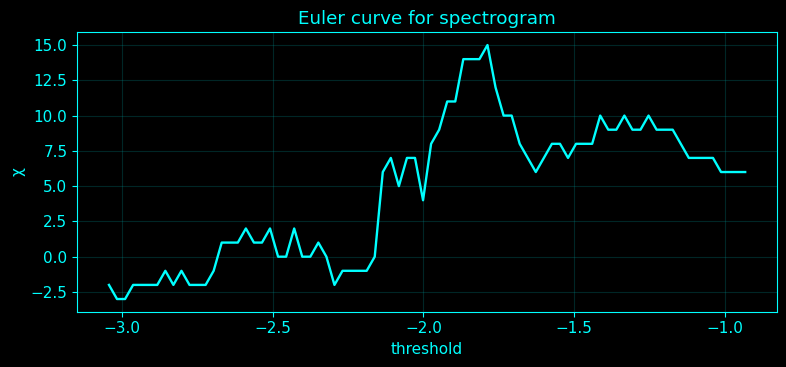

In [113]:
# Method 103: Euler curves for spectrograms

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_103():

    i = 103
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)

    # Method mathematics and output.
    A = _TOPO_SPEC
    name = 'spectrogram'
    g, c = _ec_curve_field(A, superlevel=True)
    _plot_line(g, c, f'Euler curve for {name}', 'threshold', 'χ')
    return


_topology_method_103()
del _topology_method_103


### 104. Euler curves for scalograms

The scalogram Euler curve is the analogous threshold-Euler summary for the Morlet time–scale energy field.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


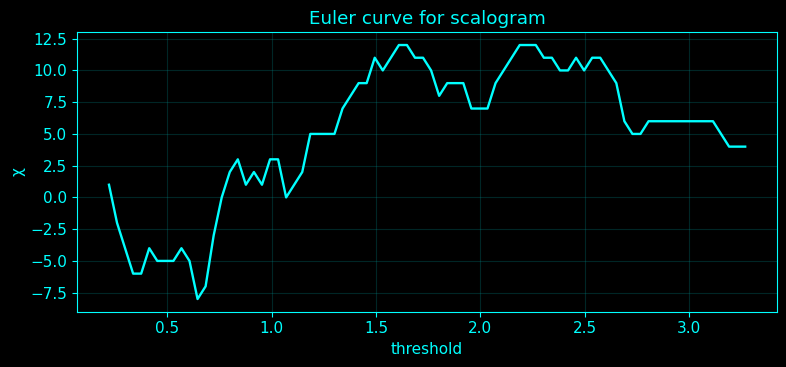

In [114]:
# Method 104: Euler curves for scalograms

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_104():

    i = 104
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _cwt_scalogram(y):
        y=np.asarray(y,float); nr,nc=_TOPO_IMG
        freqs=np.geomspace(2,min(40,_topo_fs/2-.5),nr)
        out=[]
        for f in freqs:
            s=max(2.0,6*_topo_fs/(2*np.pi*f)); half=int(min(len(y)//4,max(8,4*s)))
            tt=np.arange(-half,half+1); wav=np.exp(2j*np.pi*f*tt/_topo_fs)*np.exp(-(tt**2)/(2*s*s)); wav/=np.sqrt(np.sum(np.abs(wav)**2)+TOPO_EPS)
            out.append(np.abs(signal.fftconvolve(y,wav,mode='same'))**2)
        A=np.log1p(np.asarray(out)); A=signal.resample(A,nc,axis=1)
        return freqs,np.linspace(0,len(y)/_topo_fs,nc),A

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method-local derived quantities required by this method.
    _TOPO_CWT_F, _TOPO_CWT_T, _TOPO_CWT = _cwt_scalogram(_topo_pc1)

    # Method mathematics and output.
    A = _TOPO_CWT
    name = 'scalogram'
    g, c = _ec_curve_field(A, superlevel=True)
    _plot_line(g, c, f'Euler curve for {name}', 'threshold', 'χ')
    return


_topology_method_104()
del _topology_method_104


### 105. Euler curves for channel-time matrices

The channel–time Euler curve treats the resampled multichannel amplitude matrix as a cubical field and records \(\chi\) across amplitude thresholds. Its interpretation depends on the fixed channel ordering used for the image.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


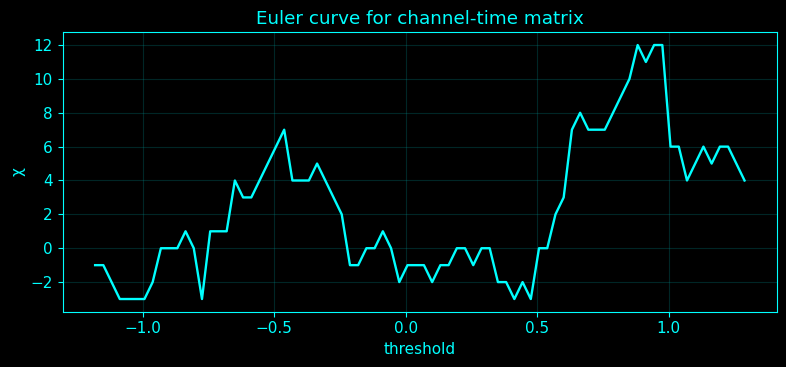

In [115]:
# Method 105: Euler curves for channel-time matrices

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_105():

    i = 105
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    nr, nc = _TOPO_IMG
    A = signal.resample(signal.resample(_topo_x.T, nc, axis=1), nr, axis=0)
    name = 'channel-time matrix'
    g, c = _ec_curve_field(A, superlevel=True)
    _plot_line(g, c, f'Euler curve for {name}', 'threshold', 'χ')
    return


_topology_method_105()
del _topology_method_105


### 106. Euler curves for coherence networks

For a coherence flag complex truncated at triangles, \(\chi=V-E+F\), where \(F\) is the number of 3-cliques. Evaluating this across coherence-dissimilarity thresholds gives the network Euler curve.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Coherence is a frequency-specific measure of linear association between two signals. It compares the magnitude of their cross-spectrum with the power spectra of the individual signals. Values near one mean that a stable linear relationship at that frequency explains a large fraction of the spectral activity, while values near zero indicate weak consistency. High coherence can arise from common input, volume conduction, or shared reference effects, so it should not automatically be interpreted as direct connectivity.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


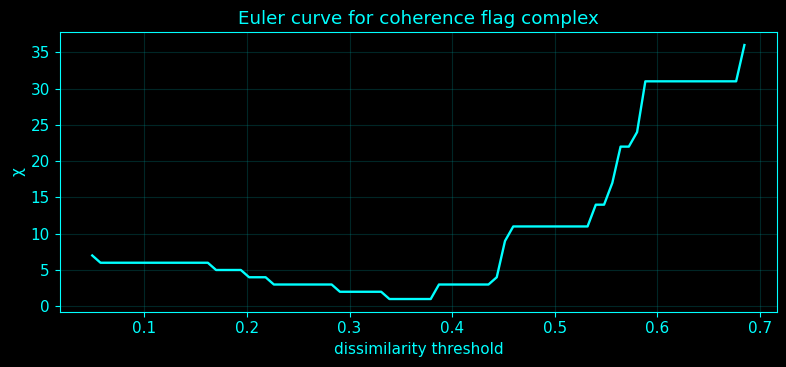

In [116]:
# Method 106: Euler curves for coherence networks

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_106():

    i = 106
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _fc_mats(seg):
        seg=np.asarray(seg,float); C=np.nan_to_num(np.corrcoef(seg.T));
        # coherence in alpha band
        n=seg.shape[1]; COH=np.eye(n); PLV=np.eye(n); PLI=np.eye(n); MI=np.eye(n)
        lo,hi=8,min(13,_topo_fs/2-.5); fil=np.column_stack([_filter_band(seg[:,j],lo,hi) for j in range(n)]) if hi>lo else seg
        ph=np.angle(signal.hilbert(fil,axis=0))
        # discretized MI on z-scored amplitudes
        bins=np.linspace(-2.5,2.5,9)
        disc=np.clip(np.digitize(seg,bins),0,len(bins))
        for i in range(n):
            for j in range(i+1,n):
                f,co=signal.coherence(seg[:,i],seg[:,j],fs=_topo_fs,nperseg=min(256,len(seg))); m=(f>=lo)&(f<=hi); cv=float(np.nanmean(co[m])) if np.any(m) else 0
                d=ph[:,i]-ph[:,j]; pv=abs(np.mean(np.exp(1j*d))); pli=abs(np.mean(np.sign(np.sin(d))))
                mi=mutual_info_score(disc[:,i],disc[:,j]);
                for M,v in [(COH,cv),(PLV,pv),(PLI,pli),(MI,mi)]: M[i,j]=M[j,i]=v
        if np.max(MI)>0: MI=MI/np.max(MI)
        return C,COH,PLV,PLI,MI

    def _fc_small(kind='coh'):
        nch=min(_topo_x.shape[1],18 if FAST_OPTION=='full' else 14 if FAST_OPTION=='balanced' else 10 if FAST_OPTION=='fast' else 8)
        seg=_topo_x[:, :nch]; C,COH,PLV,PLI,MI=_fc_mats(seg)
        return {'corr':C,'coh':COH,'plv':PLV,'pli':PLI,'mi':MI}[kind]

    def _euler_flag_curve(D,grid):
        D=np.asarray(D,float); n=len(D); vals=[]
        for e in grid:
            A=(D<=e)&np.isfinite(D); np.fill_diagonal(A,False); V=n; E=int(np.sum(np.triu(A,1))); T=0
            for i in range(n):
                for j in range(i+1,n):
                    if A[i,j]: T+=int(np.sum(A[i,j+1:]&A[j,j+1:]))
            vals.append(V-E+T)
        return np.asarray(vals)

    def _flag_ec_curve_similarity(S,n=80):
        S=np.asarray(S,float); D=1-np.clip(np.abs(S),0,1); np.fill_diagonal(D,0); vals=D[np.triu_indices_from(D,1)]; grid=np.linspace(vals.min(),vals.max(),n); return grid,_euler_flag_curve(D,grid)

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _fc_small('coh')
    g, c = _flag_ec_curve_similarity(S)
    _plot_line(g, c, 'Euler curve for coherence flag complex', 'dissimilarity threshold', 'χ')
    return


_topology_method_106()
del _topology_method_106


### 107. Euler-based topological fingerprints

The Euler fingerprint concatenates standardized summaries of several Euler curves (integral, mean, spread, and range) from spectrogram, scalogram, and scalp fields. It is a feature vector built from Euler topology, not a claim that these heterogeneous domains are the same complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,Euler_integral,chi_mean,chi_sd,chi_range
spectrogram,9.864100,4.6375,4.960453,18.0
scalogram,15.681815,5.1125,5.479493,20.0
topomap,0.115654,2.9125,2.292345,7.0


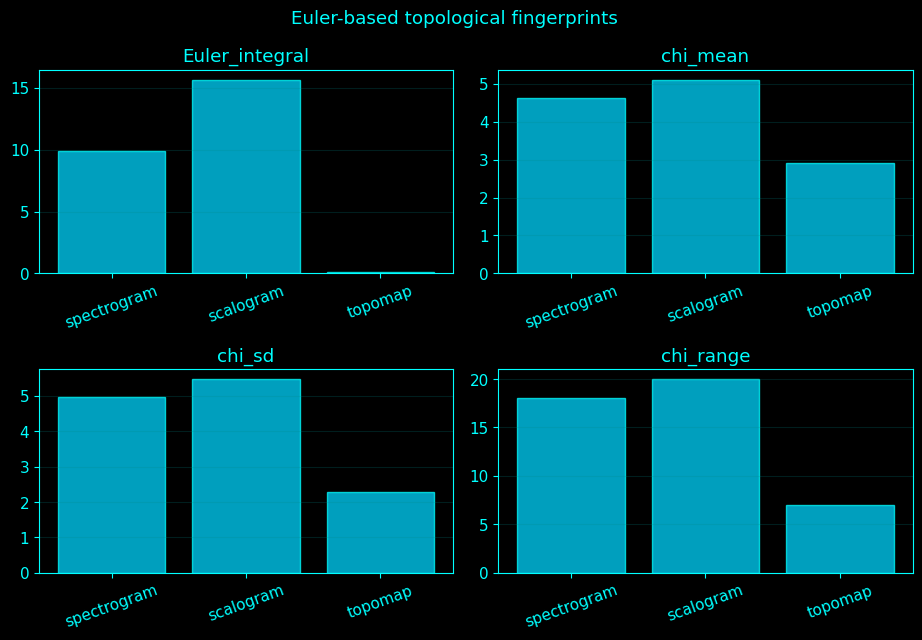

In [117]:
# Method 107: Euler-based topological fingerprints

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_107():

    i = 107
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _cwt_scalogram(y):
        y=np.asarray(y,float); nr,nc=_TOPO_IMG
        freqs=np.geomspace(2,min(40,_topo_fs/2-.5),nr)
        out=[]
        for f in freqs:
            s=max(2.0,6*_topo_fs/(2*np.pi*f)); half=int(min(len(y)//4,max(8,4*s)))
            tt=np.arange(-half,half+1); wav=np.exp(2j*np.pi*f*tt/_topo_fs)*np.exp(-(tt**2)/(2*s*s)); wav/=np.sqrt(np.sum(np.abs(wav)**2)+TOPO_EPS)
            out.append(np.abs(signal.fftconvolve(y,wav,mode='same'))**2)
        A=np.log1p(np.asarray(out)); A=signal.resample(A,nc,axis=1)
        return freqs,np.linspace(0,len(y)/_topo_fs,nc),A

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    def _tf_spectrogram(y):
        y=np.asarray(y,float)
        nr,nc=_TOPO_IMG
        nper=min(len(y), 512 if FAST_OPTION=='full' else 384 if FAST_OPTION=='balanced' else 256 if FAST_OPTION=='fast' else 192)
        nover=nper//2
        f,t,S=signal.spectrogram(y,fs=_topo_fs,nperseg=nper,noverlap=nover,scaling='density',mode='psd')
        m=(f>=1)&(f<=min(45,_topo_fs/2-.5)); A=np.log10(S[m]+TOPO_EPS)
        return f[m],t,signal.resample(signal.resample(A,nr,axis=0),nc,axis=1)

    # Method-local derived quantities required by this method.
    _TOPO_SPEC_F, _TOPO_SPEC_T, _TOPO_SPEC = _tf_spectrogram(_topo_pc1)
    _TOPO_CWT_F, _TOPO_CWT_T, _TOPO_CWT = _cwt_scalogram(_topo_pc1)
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    curves = []
    labels = []
    for name, A in [('spectrogram', _TOPO_SPEC), ('scalogram', _TOPO_CWT), ('topomap', _TOPO_TOPOMAP)]:
        g, c = _ec_curve_field(A, superlevel=True)
        curves.append([np.trapezoid(c, g), np.mean(c), np.std(c), np.max(c) - np.min(c)])
        labels.append(name)
    out = pd.DataFrame(curves, index=labels, columns=['Euler_integral', 'chi_mean', 'chi_sd', 'chi_range'])
    display(out)
    fig, axs = plt.subplots(2, 2, figsize=(9.5, 6.5), facecolor=TOPO_BG)
    axs = np.ravel(axs)
    for ax, col in zip(axs, out.columns):
        ax.bar(out.index, out[col].to_numpy(float), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=20)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Euler-based topological fingerprints')
    plt.tight_layout()
    plt.show()
    return


_topology_method_107()
del _topology_method_107


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — Mapper/Reeb/Morse helpers for topology methods 108–132</h3>
<p>This foundation builds finite-cover Mapper graphs, Reeb/merge-tree approximations, and discrete Morse/Morse–Smale summaries. Mapper forms the nerve of clusters in overlapping inverse-image cover sets; merge trees track connected components of sublevel/superlevel sets with the elder rule. Discrete criticality is estimated from lower/upper links rather than equating every local extremum with a smooth Morse critical point.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [118]:
# =======================================================
# TOPOLOGY CATALOGUE CONSTANTS/IMPORTS — methods 108–132
# No shared mathematical helper functions.
# =======================================================
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

_TOPO_MAPPER_POINTS = {'full':180, 'balanced':130, 'fast':90, 'ultra':60}[FAST_OPTION]
_TOPO_MAPPER_RES = {'full':10, 'balanced':8, 'fast':7, 'ultra':6}[FAST_OPTION]
_RING = [(-1,-1),(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1)]


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — topology methods 108–132</h3>
<p>This cell routes catalogue indices to the Mapper, Reeb/merge-tree, and discrete Morse/Morse–Smale implementations. Cover resolution, overlap, and sampling budgets may change with speed mode, but the topological construction itself does not.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


### 108. Mapper graph

Mapper summarizes a point cloud using a filter (lens) \(f:X\to\mathbb R\), an overlapping cover \(\{U_\alpha\}\) of the filter range, and clustering inside each preimage \(f^{-1}(U_\alpha)\). Each cluster is a node; nodes are connected when their underlying sample sets intersect. The graph therefore depends on lens, cover and clustering choices.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


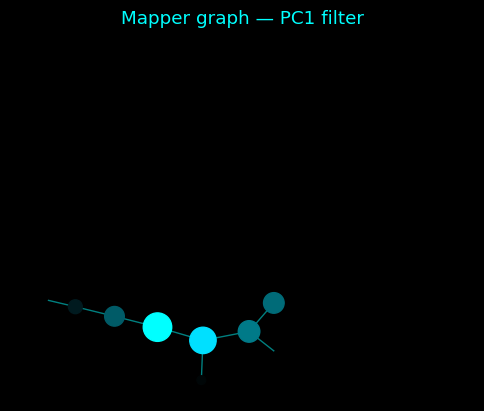

{'nodes': np.float64(11.0), 'edges': np.float64(8.0), 'components': np.float64(3.0), 'beta1': np.float64(0.0)}


In [119]:
# Method 108: Mapper graph

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_108():

    i = 108
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    def _mapper_summary(G):
        beta1=G.number_of_edges()-G.number_of_nodes()+nx.number_connected_components(G) if G.number_of_nodes() else 0
        return np.array([G.number_of_nodes(),G.number_of_edges(),nx.number_connected_components(G) if G.number_of_nodes() else 0,beta1],float)

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    G = _mapper_graph(X, lens('pc1'), res, ov)
    _draw_graph(G, 'Mapper graph — PC1 filter')
    print(dict(zip(['nodes', 'edges', 'components', 'beta1'], _mapper_summary(G))))
    return


_topology_method_108()
del _topology_method_108


### 109. Multi-filter Mapper

Multi-filter Mapper uses a vector-valued lens \(f:X\to\mathbb R^2\). The cover is a product of overlapping intervals in the two filter coordinates, and clusters are computed in each box preimage. This can separate structures that overlap in either filter alone.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


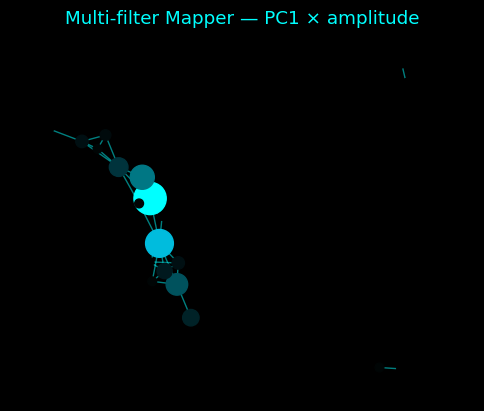

In [120]:
# Method 109: Multi-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_109():

    i = 109
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    G = _mapper_graph(X, np.column_stack([lens('pc1'), lens('amplitude')]), max(4, res - 1), ov)
    _draw_graph(G, 'Multi-filter Mapper — PC1 × amplitude')
    return


_topology_method_109()
del _topology_method_109


### 110. Time-filter Mapper

Time-filter Mapper takes normalized sample time as the lens. The resulting graph organizes portions of the state cloud according to temporal progression while still clustering in multivariate PCA state space.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


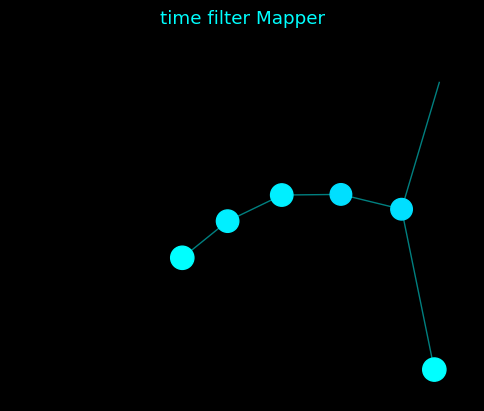

In [121]:
# Method 110: Time-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_110():

    i = 110
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_110()
del _topology_method_110


### 111. Amplitude-filter Mapper

Amplitude-filter Mapper uses multichannel state norm \(\|x_t\|_2\) as the lens, so overlapping amplitude ranges form the cover while clustering uses the underlying PCA state coordinates.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


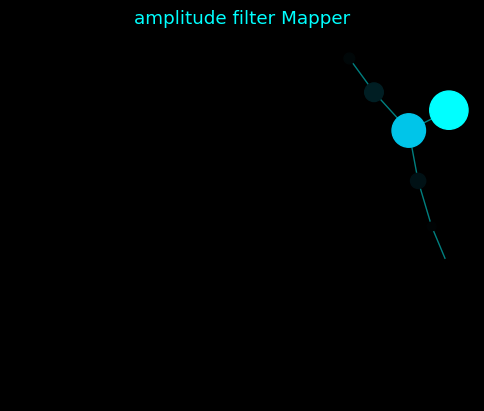

In [122]:
# Method 111: Amplitude-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_111():

    i = 111
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_111()
del _topology_method_111


### 112. Bandpower-filter Mapper

Bandpower-filter Mapper uses a locally sampled alpha-envelope statistic as the filter. The lens changes the cover only; Mapper clusters remain based on the multivariate state-space geometry.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


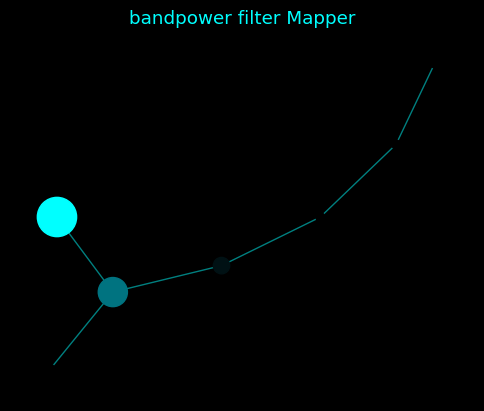

In [123]:
# Method 112: Bandpower-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_112():

    i = 112
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_112()
del _topology_method_112


### 113. Entropy-filter Mapper

Entropy-filter Mapper uses local amplitude-distribution entropy \(H=-\sum_b p_b\log p_b\) as its lens. It therefore organizes state-space clusters by local signal-complexity level without equating entropy itself with topology.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


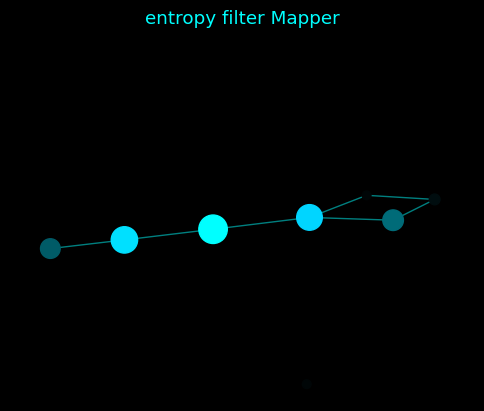

In [124]:
# Method 113: Entropy-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_113():

    i = 113
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_113()
del _topology_method_113


### 114. Fractal-dimension-filter Mapper

Fractal-dimension-filter Mapper uses a local Katz-style curve-dimension estimate as the lens. For a window with path length \(L\), maximum excursion \(d\), and \(N\) samples, the estimator is \(D_K=\log_{10}N/[\log_{10}N+\log_{10}(d/L)]\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A fractal-dimension estimator asks how the apparent geometric complexity of a signal changes with the scale at which it is measured. Higuchi's method constructs several down-sampled curves using step size k, estimates their lengths, and examines how length follows a power law with scale. The slope on a log-log plot becomes the dimension estimate. For a one-dimensional time-series graph, larger values generally correspond to a rougher, more irregular trace, but the estimate is affected by noise, record length, and the range of scales used for fitting.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


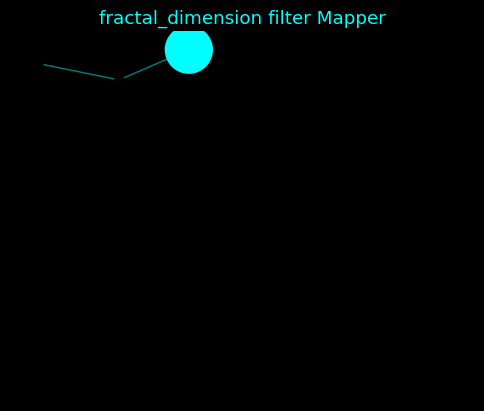

In [125]:
# Method 114: Fractal-dimension-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_114():

    i = 114
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_114()
del _topology_method_114


### 115. Spectral-centroid-filter Mapper

Spectral-centroid-filter Mapper uses local spectral centroid \(f_c=\sum_f fP(f)/\sum_fP(f)\) as the lens. The Mapper graph then describes multivariate state connectivity across overlapping centroid ranges.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


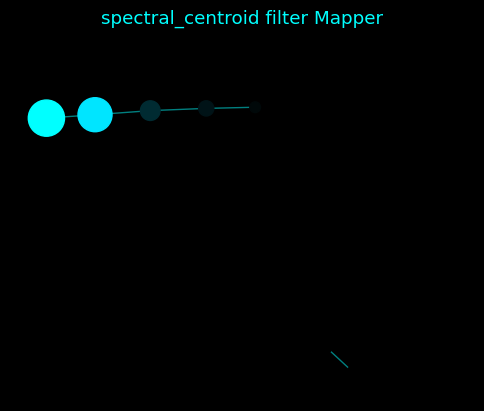

In [126]:
# Method 115: Spectral-centroid-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_115():

    i = 115
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_115()
del _topology_method_115


### 116. PC-filter Mapper

PC-filter Mapper uses the first PCA score as a scalar lens. PCA supplies only the filter coordinate; the Mapper nerve is still built from overlapping cover preimages and within-bin clustering.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


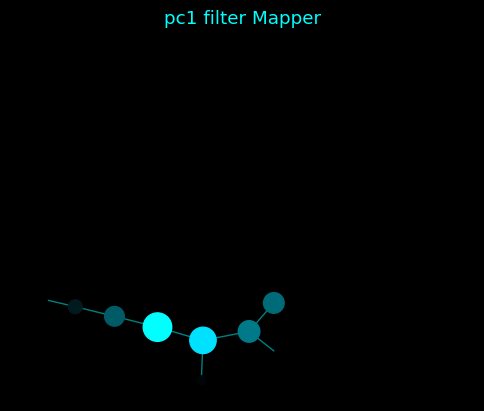

In [127]:
# Method 116: PC-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_116():

    i = 116
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_116()
del _topology_method_116


### 117. UMAP-filter Mapper

UMAP-filter Mapper uses the first coordinate of UMAP when the package is available. Otherwise this notebook explicitly uses its fuzzy-kNN spectral fallback and labels it as such; the fallback is not claimed to reproduce UMAP's cross-entropy optimization.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


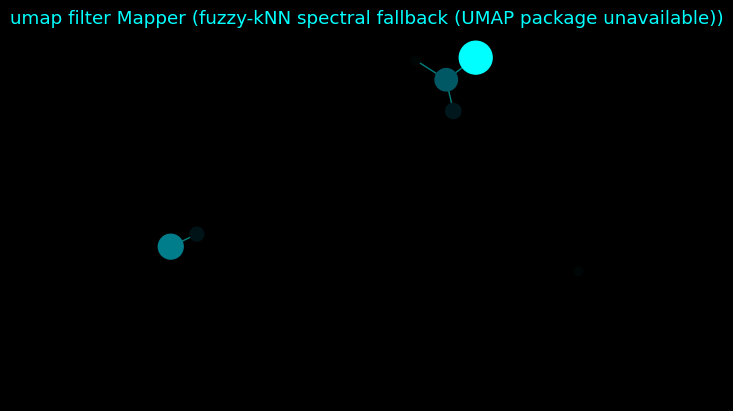

In [128]:
# Method 117: UMAP-filter Mapper

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_117():

    i = 117
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    name = {110: 'time', 111: 'amplitude', 112: 'bandpower', 113: 'entropy', 114: 'fractal_dimension', 115: 'spectral_centroid', 116: 'pc1', 117: 'umap'}[i]
    G = _mapper_graph(X, lens(name), res, ov)
    _draw_graph(G, f'{name} filter Mapper' + (f' ({umap_label})' if i == 117 else ''))
    return


_topology_method_117()
del _topology_method_117


### 118. Mapper stability sweep

Mapper stability is assessed by varying both cover resolution and overlap (gain) and recording graph summaries \((|V|,|E|,\beta_0,\beta_1)\), where \(\beta_1=|E|-|V|+\beta_0\) for a graph. Stable regions are less sensitive to cover hyperparameters.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,resolution,overlap,nodes,edges,components,beta1
0,4,0.20,7.0,3.0,4.0,0.0
1,4,0.35,6.0,3.0,3.0,0.0
2,4,0.50,6.0,4.0,2.0,0.0
3,5,0.20,10.0,6.0,4.0,0.0
4,5,0.35,8.0,4.0,4.0,0.0
5,5,0.50,7.0,4.0,3.0,0.0
6,6,0.20,10.0,6.0,4.0,0.0
7,6,0.35,11.0,8.0,3.0,0.0
8,6,0.50,11.0,8.0,3.0,0.0
9,7,0.20,14.0,8.0,6.0,0.0


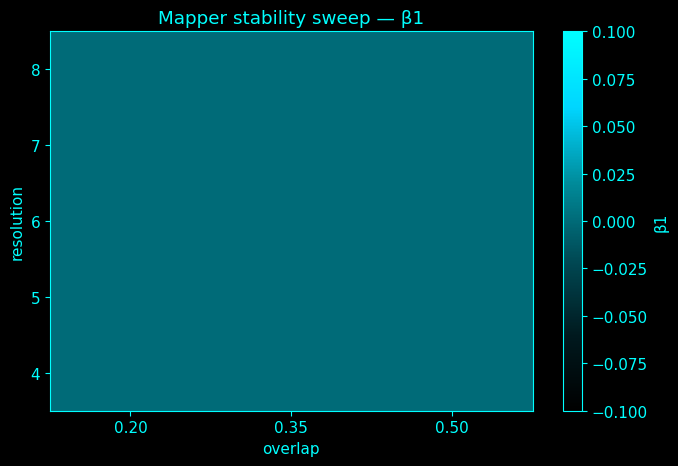

In [129]:
# Method 118: Mapper stability sweep

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_118():

    i = 118
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    def _mapper_summary(G):
        beta1=G.number_of_edges()-G.number_of_nodes()+nx.number_connected_components(G) if G.number_of_nodes() else 0
        return np.array([G.number_of_nodes(),G.number_of_edges(),nx.number_connected_components(G) if G.number_of_nodes() else 0,beta1],float)

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    def lens(name):
        return F[name]
    rows = []
    for rr in range(max(4, res - 2), res + 3):
        for oo in [0.2, 0.35, 0.5]:
            rows.append([rr, oo, *_mapper_summary(_mapper_graph(X, lens('pc1'), rr, oo))])
    out = pd.DataFrame(rows, columns=['resolution', 'overlap', 'nodes', 'edges', 'components', 'beta1'])
    display(out)
    piv = out.pivot(index='resolution', columns='overlap', values='beta1')
    fig, ax = plt.subplots(figsize=(7, 4.8), facecolor=TOPO_BG)
    im = ax.imshow(piv.to_numpy(float), cmap=TOPO_CMAP, aspect='auto', origin='lower')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel('overlap')
    ax.set_ylabel('resolution')
    ax.set_title('Mapper stability sweep — β1')
    cb = plt.colorbar(im, ax=ax)
    cb.set_label('β1', color=TOPO_ACCENT)
    plt.tight_layout()
    plt.show()
    return


_topology_method_118()
del _topology_method_118


### 119. Mapper cover-resolution sweep

The cover-resolution sweep changes the number of filter intervals while fixing overlap. Higher resolution narrows cover sets and can split Mapper nodes; lower resolution merges more data before clustering.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,cover_intervals,nodes,edges,components,beta1
0,4,6.0,3.0,3.0,0.0
1,5,8.0,4.0,4.0,0.0
2,6,11.0,8.0,3.0,0.0
3,7,12.0,9.0,3.0,0.0
4,8,14.0,10.0,4.0,0.0
5,9,16.0,11.0,5.0,0.0
6,10,18.0,13.0,5.0,0.0


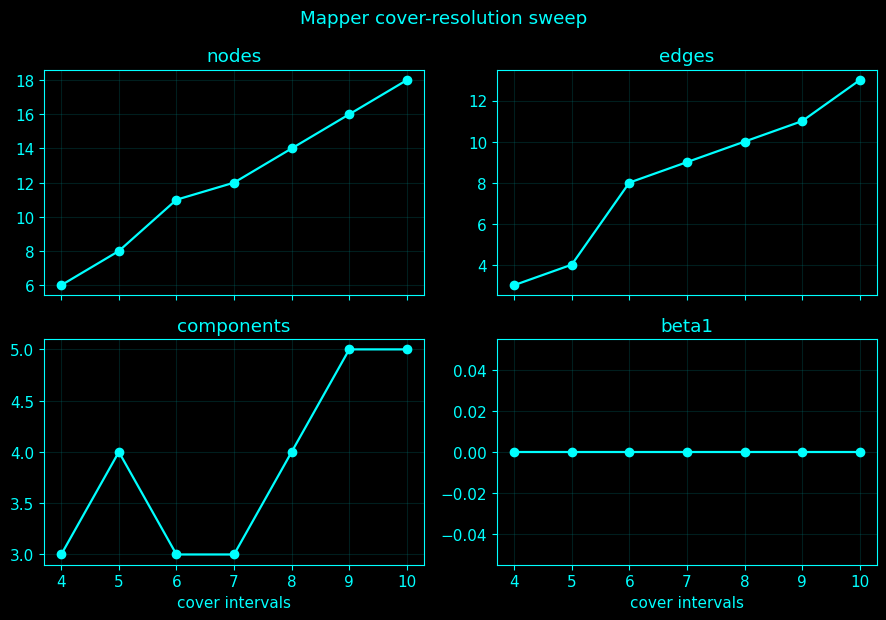

In [130]:
# Method 119: Mapper cover-resolution sweep

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_119():

    i = 119
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    def _mapper_summary(G):
        beta1=G.number_of_edges()-G.number_of_nodes()+nx.number_connected_components(G) if G.number_of_nodes() else 0
        return np.array([G.number_of_nodes(),G.number_of_edges(),nx.number_connected_components(G) if G.number_of_nodes() else 0,beta1],float)

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    rows = []
    for rr in range(4, res + 5):
        rows.append([rr, *_mapper_summary(_mapper_graph(X, lens('pc1'), rr, ov))])
    out = pd.DataFrame(rows, columns=['cover_intervals', 'nodes', 'edges', 'components', 'beta1'])
    display(out)
    fig, axs = plt.subplots(2, 2, figsize=(9, 6.3), sharex=True, facecolor=TOPO_BG)
    axs = np.ravel(axs)
    for ax, col in zip(axs, ['nodes', 'edges', 'components', 'beta1']):
        ax.plot(out['cover_intervals'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.6)
        ax.set_title(col)
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    axs[2].set_xlabel('cover intervals')
    axs[3].set_xlabel('cover intervals')
    fig.suptitle('Mapper cover-resolution sweep')
    plt.tight_layout()
    plt.show()
    return


_topology_method_119()
del _topology_method_119


### 120. Mapper gain sweep

Mapper gain is the fractional overlap between adjacent cover intervals. Increasing overlap creates more shared observations between cover elements and therefore can add nerve edges; the sweep reports how graph topology responds.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,gain_overlap,nodes,edges,components,beta1
0,0.100000,9.0,5.0,4.0,0.0
1,0.191667,10.0,6.0,4.0,0.0
2,0.283333,11.0,7.0,4.0,0.0
3,0.375000,10.0,7.0,3.0,0.0
4,0.466667,11.0,8.0,3.0,0.0
5,0.558333,8.0,9.0,3.0,4.0
6,0.650000,8.0,9.0,3.0,4.0


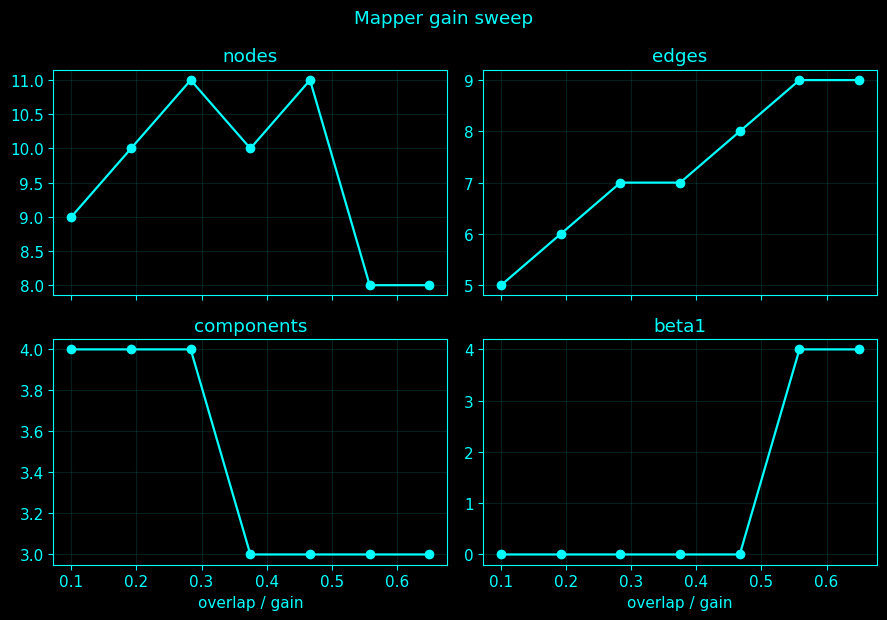

In [131]:
# Method 120: Mapper gain sweep

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_120():

    i = 120
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    def _mapper_summary(G):
        beta1=G.number_of_edges()-G.number_of_nodes()+nx.number_connected_components(G) if G.number_of_nodes() else 0
        return np.array([G.number_of_nodes(),G.number_of_edges(),nx.number_connected_components(G) if G.number_of_nodes() else 0,beta1],float)

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    def lens(name):
        return F[name]
    rows = []
    for oo in np.linspace(0.1, 0.65, 7):
        rows.append([oo, *_mapper_summary(_mapper_graph(X, lens('pc1'), res, float(oo)))])
    out = pd.DataFrame(rows, columns=['gain_overlap', 'nodes', 'edges', 'components', 'beta1'])
    display(out)
    fig, axs = plt.subplots(2, 2, figsize=(9, 6.3), sharex=True, facecolor=TOPO_BG)
    axs = np.ravel(axs)
    for ax, col in zip(axs, ['nodes', 'edges', 'components', 'beta1']):
        ax.plot(out['gain_overlap'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.6)
        ax.set_title(col)
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    axs[2].set_xlabel('overlap / gain')
    axs[3].set_xlabel('overlap / gain')
    fig.suptitle('Mapper gain sweep')
    plt.tight_layout()
    plt.show()
    return


_topology_method_120()
del _topology_method_120


### 121. Mapper node signal summaries

Mapper node summaries aggregate the original observations represented by each node. The notebook reports node size and mean amplitude, alpha envelope and entropy, linking graph structure back to signal quantities without redefining those quantities as topological invariants.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,node,size,mean_amplitude,mean_alpha_envelope,mean_entropy
0,0,11,6.611308,0.171625,2.222513
1,1,1,5.074027,0.052757,2.258751
2,2,2,4.379320,0.104716,2.272527
3,3,12,4.577798,0.148320,2.243817
4,4,18,3.139461,0.154715,2.255638
5,5,21,3.575540,0.128702,2.227160
6,6,10,5.373678,0.143417,2.291290
7,7,1,7.516011,0.065052,2.213406
8,8,5,7.068156,0.132012,2.237197
9,9,1,10.124126,0.079347,2.150616


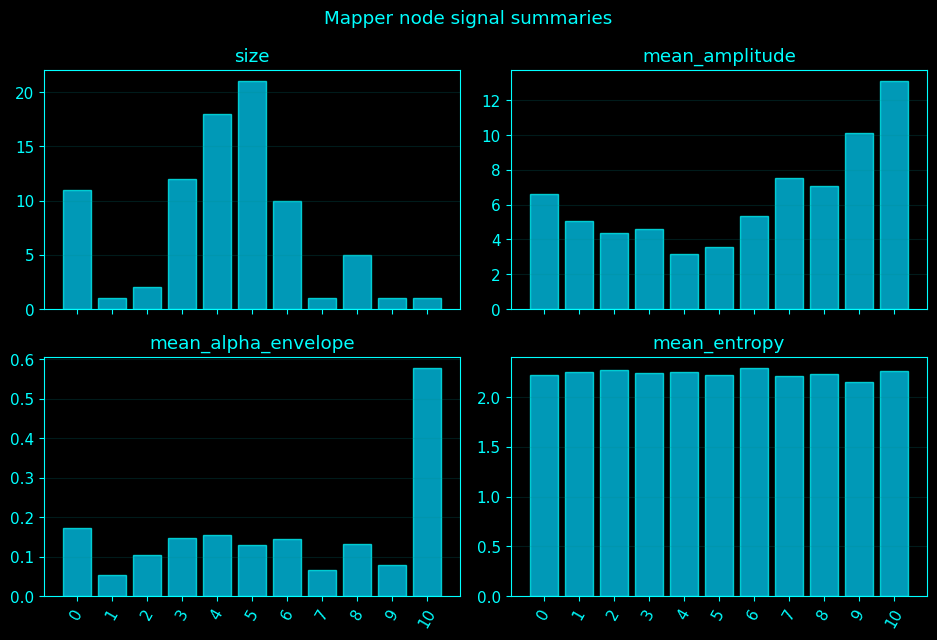

In [132]:
# Method 121: Mapper node signal summaries

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_121():

    i = 121
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    G = _mapper_graph(X, lens('pc1'), res, ov)
    rows = []
    for n, d in G.nodes(data=True):
        mem = sorted(d['members'])
        rows.append([n, d['size'], float(np.mean(F['amplitude'][mem])), float(np.mean(F['bandpower'][mem])), float(np.mean(F['entropy'][mem]))])
    out = pd.DataFrame(rows, columns=['node', 'size', 'mean_amplitude', 'mean_alpha_envelope', 'mean_entropy'])
    display(out)
    fig, axs = plt.subplots(2, 2, figsize=(9.5, 6.5), sharex=True, facecolor=TOPO_BG)
    axs = np.ravel(axs)
    for ax, col in zip(axs, ['size', 'mean_amplitude', 'mean_alpha_envelope', 'mean_entropy']):
        ax.bar(out['node'].astype(str), out[col].to_numpy(float), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.72)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=60)
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.2)
    fig.suptitle('Mapper node signal summaries')
    plt.tight_layout()
    plt.show()
    return


_topology_method_121()
del _topology_method_121


### 122. Mapper community detection

Community detection is performed on the Mapper graph using greedy modularity optimization. For partition \(c_i\), modularity compares observed within-community edge density with a degree-preserving null: \(Q=(2m)^{-1}\sum_{ij}(A_{ij}-k_ik_j/2m)\,\delta(c_i,c_j)\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


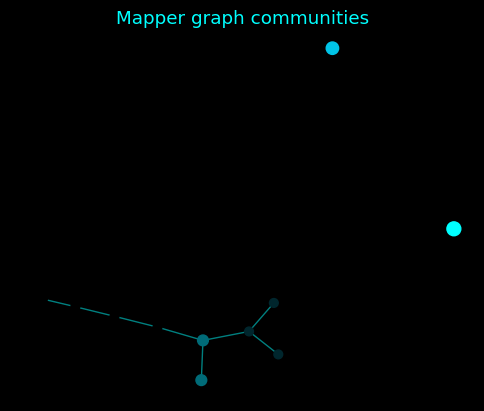

In [133]:
# Method 122: Mapper community detection

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_122():

    i = 122
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    G = _mapper_graph(X, lens('pc1'), res, ov)
    if G.number_of_edges():
        comm = list(nx.algorithms.community.greedy_modularity_communities(G))
        lab = {u: k for k, C in enumerate(comm) for u in C}
        vals = [lab[n] + 1 for n in G]
    else:
        vals = [1] * G.number_of_nodes()
    _draw_graph(G, 'Mapper graph communities', vals)
    return


_topology_method_122()
del _topology_method_122


### 123. Mapper graph persistence

Mapper graph persistence assigns each Mapper edge the dissimilarity \(1-J(A,B)\), where \(J=|A\cap B|/|A\cup B|\) is Jaccard overlap of node sample sets, then computes flag-complex persistence on that weighted graph. This is persistence of the Mapper overlap graph, not persistence of the original point cloud.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


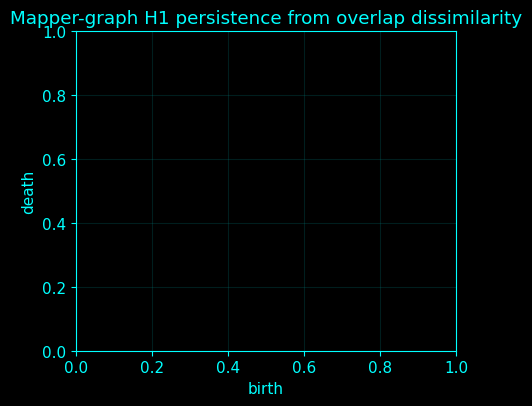

In [134]:
# Method 123: Mapper graph persistence

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_123():

    i = 123
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _flag_ph(D):
        D=np.asarray(D,float); n=len(D); cells=[]
        for i in range(n): cells.append((('v',i),0,0,[]))
        finite=np.isfinite(D)
        for i in range(n):
            for j in range(i+1,n):
                if finite[i,j]: cells.append((('e',i,j),float(D[i,j]),1,[('v',i),('v',j)]))
        for i in range(n):
            for j in range(i+1,n):
                if not finite[i,j]: continue
                for k in range(j+1,n):
                    if finite[i,k] and finite[j,k]: cells.append((('t',i,j,k),float(max(D[i,j],D[i,k],D[j,k])),2,[('e',i,j),('e',i,k),('e',j,k)]))
        return _ph_cells(cells,1)

    def _mapper_edge_persistence(G):
        n=G.number_of_nodes(); D=np.full((n,n),np.inf); np.fill_diagonal(D,0)
        for a,b in G.edges():
            A=G.nodes[a]['members']; B=G.nodes[b]['members']; j=len(A&B)/max(1,len(A|B)); D[a,b]=D[b,a]=1-j
        return _flag_ph(D) if n else [np.empty((0,2)),np.empty((0,2))]

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    ov = 0.35
    def lens(name):
        return F[name]
    G = _mapper_graph(X, lens('pc1'), res, ov)
    dg = _mapper_edge_persistence(G)
    _plot_diag(dg[1], 'Mapper-graph H1 persistence from overlap dissimilarity')
    return


_topology_method_123()
del _topology_method_123


### 124. Reeb graph approximation

A Reeb graph identifies points lying in the same connected component of a level set of a scalar function. Mapper with a sufficiently fine overlapping scalar cover is a finite-cover approximation to this construction; the notebook therefore labels this cell a **Reeb graph approximation**, not an exact Reeb graph.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


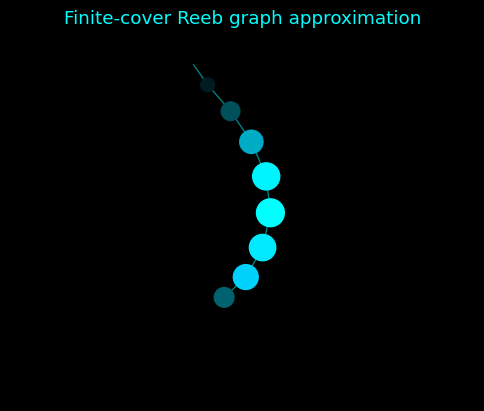

In [135]:
# Method 124: Reeb graph approximation

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_124():

    i = 124
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _filter_band(y,lo,hi):
        sos=signal.butter(4,[lo,hi],btype='bandpass',fs=_topo_fs,output='sos'); return signal.sosfiltfilt(sos,y)

    def _umap_or_fuzzy_spectral(X):
        try:
            import umap
            return umap.UMAP(n_components=2,n_neighbors=min(15,len(X)-1),random_state=0).fit_transform(X), 'UMAP'
        except Exception:
            # Explicit fallback: UMAP fuzzy-neighborhood graph followed by spectral coordinates; no SGD cross-entropy step.
            k=min(15,max(2,len(X)-1)); nn=NearestNeighbors(n_neighbors=k+1).fit(X); dist,ind=nn.kneighbors(X)
            rho=dist[:,1]; sigma=np.maximum(np.mean(dist[:,2:],axis=1),TOPO_EPS)
            W=np.zeros((len(X),len(X)))
            for i in range(len(X)):
                for dij,j in zip(dist[i,1:],ind[i,1:]): W[i,j]=math.exp(-max(0.0,dij-rho[i])/sigma[i])
            W=W+W.T-W*W.T
            emb=SpectralEmbedding(n_components=2,affinity='precomputed',random_state=0).fit_transform(W)
            return emb,'fuzzy-kNN spectral fallback (UMAP package unavailable)'

    def _mapper_dataset():
        n=min(len(_topo_x),_TOPO_MAPPER_POINTS)
        idx=np.linspace(0,len(_topo_x)-1,n).astype(int)
        raw=_topo_x[idx]
        q=min(5,raw.shape[1],len(raw)-1)
        X=PCA(q).fit_transform(raw)
        pc1=X[:,0]
        amp=np.linalg.norm(raw,axis=1)
        # local alpha envelope sampled at the same times
        hi=min(13,_topo_fs/2-.5); lo=min(8,max(.5,hi-2))
        if hi>lo:
            a=np.mean(np.abs(signal.hilbert(np.column_stack([_filter_band(_topo_x[:,j],lo,hi) for j in range(min(6,_topo_x.shape[1]))]),axis=0)),axis=1)[idx]
        else: a=amp.copy()
        # local entropy and spectral centroid proxies from short windows around sampled times
        ent=[]; cent=[]
        half=max(8,int(.10*_topo_fs))
        y=_topo_pc1
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            h,_=np.histogram(w,bins=12,density=False); p=h/(h.sum()+TOPO_EPS); ent.append(float(-np.sum(p[p>0]*np.log(p[p>0]))))
            f,P=signal.welch(w,fs=_topo_fs,nperseg=min(len(w),128)); cent.append(float(np.sum(f*P)/(np.sum(P)+TOPO_EPS)))
        # Katz fractal-dimension style local complexity lens
        fd=[]
        for ii in idx:
            w=y[max(0,ii-half):min(len(y),ii+half+1)]
            if len(w)<3: fd.append(1.0); continue
            L=np.sum(np.abs(np.diff(w))); d=np.max(np.abs(w-w[0])); N=len(w)
            fd.append(float(np.log10(N)/(np.log10(N)+np.log10((d+TOPO_EPS)/(L+TOPO_EPS)))))
        emb2,label=_umap_or_fuzzy_spectral(X)
        filters={'time':idx/max(1,len(_topo_x)-1),'amplitude':amp,'bandpower':a,'entropy':np.asarray(ent),'fractal_dimension':np.asarray(fd),'spectral_centroid':np.asarray(cent),'pc1':pc1,'umap':emb2[:,0]}
        return X,idx,filters,label

    def _cluster_subset(X,inds):
        inds=np.asarray(inds,int)
        if len(inds)==0:return []
        if len(inds)<=2:return [inds]
        D=pairwise_distances(X[inds]); nz=D[D>0]; eps=float(np.quantile(nz,.35)) if len(nz) else 1e-6
        lab=DBSCAN(eps=max(eps,1e-6),min_samples=2).fit_predict(X[inds])
        out=[]
        for k in sorted(set(lab)):
            if k==-1: continue
            out.append(inds[lab==k])
        # retain noise points as singleton nodes so cover support is not silently discarded
        for z in inds[lab==-1]: out.append(np.array([z],int))
        return out

    def _cover_intervals(v,n_intervals=7,overlap=.35):
        v=np.asarray(v,float); lo,hi=float(np.min(v)),float(np.max(v));
        if hi<=lo+TOPO_EPS: return [(lo-1e-9,hi+1e-9)]
        n=max(2,int(n_intervals)); ov=float(np.clip(overlap,0,.8)); width=(hi-lo)/(1+(n-1)*(1-ov)); step=width*(1-ov)
        return [(lo+k*step,lo+k*step+width+1e-12) for k in range(n)]

    def _mapper_graph(X,lenses,res=7,overlap=.35):
        X=np.asarray(X,float); L=np.asarray(lenses,float)
        if L.ndim==1:L=L[:,None]
        if L.shape[1]>2: raise ValueError('Mapper helper supports one or two filter coordinates')
        covers=[_cover_intervals(L[:,j],res,overlap) for j in range(L.shape[1])]
        boxes=[(a,) for a in range(len(covers[0]))] if L.shape[1]==1 else [(a,b) for a in range(len(covers[0])) for b in range(len(covers[1]))]
        nodes=[]
        for box in boxes:
            mask=np.ones(len(X),bool)
            for j,k in enumerate(box):
                lo,hi=covers[j][k]; mask &= (L[:,j]>=lo)&(L[:,j]<=hi)
            inds=np.where(mask)[0]
            for cl in _cluster_subset(X,inds): nodes.append({'members':set(map(int,cl)),'box':box})
        G=nx.Graph()
        for a,node in enumerate(nodes): G.add_node(a,size=len(node['members']),members=node['members'],box=node['box'])
        for a in range(len(nodes)):
            for b in range(a+1,len(nodes)):
                inter=nodes[a]['members']&nodes[b]['members']
                if inter: G.add_edge(a,b,overlap=len(inter))
        return G

    # Method mathematics and output.
    X, idx, F, umap_label = _mapper_dataset()
    res = _TOPO_MAPPER_RES
    def lens(name):
        return F[name]
    G = _mapper_graph(X, lens('pc1'), max(res + 2, 8), 0.5)
    _draw_graph(G, 'Finite-cover Reeb graph approximation')
    return


_topology_method_124()
del _topology_method_124


### 125. Merge tree analysis

For a scalar signal on a path graph, the sublevel merge tree tracks how connected components are born at minima and merge as the threshold rises. The elder rule retains the component with lower birth value; the resulting H0 birth–merge pairs are exactly the finite branches of the merge tree.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


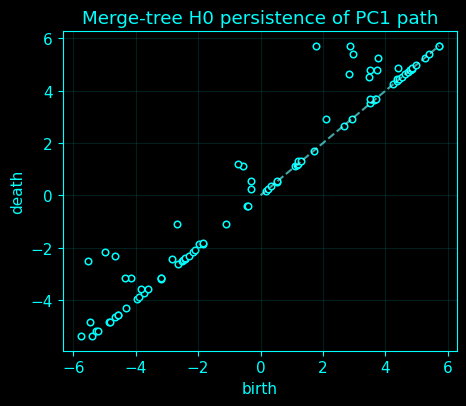

In [136]:
# Method 125: Merge tree analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_125():

    i = 125
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _path_h0_persistence(y):
        y=np.asarray(y,float); n=len(y); parent=np.arange(n); birth=y.copy(); active=np.zeros(n,bool); pairs=[]
        def find(a):
            while parent[a]!=a:
                parent[a]=parent[parent[a]]; a=parent[a]
            return a
        for v in np.argsort(y,kind='stable'):
            active[v]=True; parent[v]=v; birth[v]=y[v]
            neigh=[u for u in (v-1,v+1) if 0<=u<n and active[u]]
            roots=[]
            for u in neigh:
                r=find(u)
                if r not in roots: roots.append(r)
            if not roots: continue
            # elder rule: oldest (lowest birth) survives
            allr=roots+[v]; survivor=min(allr,key=lambda r:(birth[find(r)],find(r))); survivor=find(survivor)
            for r in allr:
                r=find(r)
                if r==survivor: continue
                pairs.append([birth[r],y[v]]); parent[r]=survivor
            parent[v]=survivor
        roots={find(i) for i in range(n) if active[i]}; ess=[[birth[r],np.inf] for r in roots]
        return np.asarray(pairs+ess,float).reshape(-1,2)

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _plot_diag(dgm,title):
        d=_finite(dgm); fig,ax=plt.subplots(figsize=(4.8,4.2),facecolor=TOPO_BG)
        if len(d):
            mx=max(TOPO_EPS,float(np.max(d)))
            ax.scatter(d[:,0],d[:,1],s=22,facecolors=TOPO_BG,edgecolors=TOPO_ACCENT,linewidths=1.1)
            ax.plot([0,mx],[0,mx],ls='--',color=TOPO_CYAN_SOFT,alpha=.65)
        ax.set_title(title); ax.set_xlabel('birth'); ax.set_ylabel('death')
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.22,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    y = signal.resample(_topo_pc1, min(400 if FAST_OPTION == 'full' else 220 if FAST_OPTION == 'balanced' else 140 if FAST_OPTION == 'fast' else 90, len(_topo_pc1)))
    d = _path_h0_persistence(y)
    _plot_diag(d, 'Merge-tree H0 persistence of PC1 path')
    return


_topology_method_125()
del _topology_method_125


### 126. Persistent merge trees

Persistent merge-tree analysis computes the path-graph H0 merge persistence in successive time windows. Total branch persistence, maximum branch lifetime and persistence entropy summarize how the merge-tree structure changes over time.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


,time_s,merge_total_persistence,merge_max_lifetime,merge_entropy
0,1.40,42.489619,4.975685,3.175813
1,2.64,49.984797,5.182750,3.167122
2,3.88,52.932633,5.535920,3.190845
3,5.12,44.484398,5.437144,3.111166
4,6.36,45.035979,4.018459,3.285944
5,7.60,48.449478,3.904650,3.338850
6,8.84,47.458513,4.549228,3.119396
7,10.08,51.142787,5.276069,3.048917
8,11.32,50.304053,3.864096,3.221599
9,12.56,52.291321,5.746254,3.214827


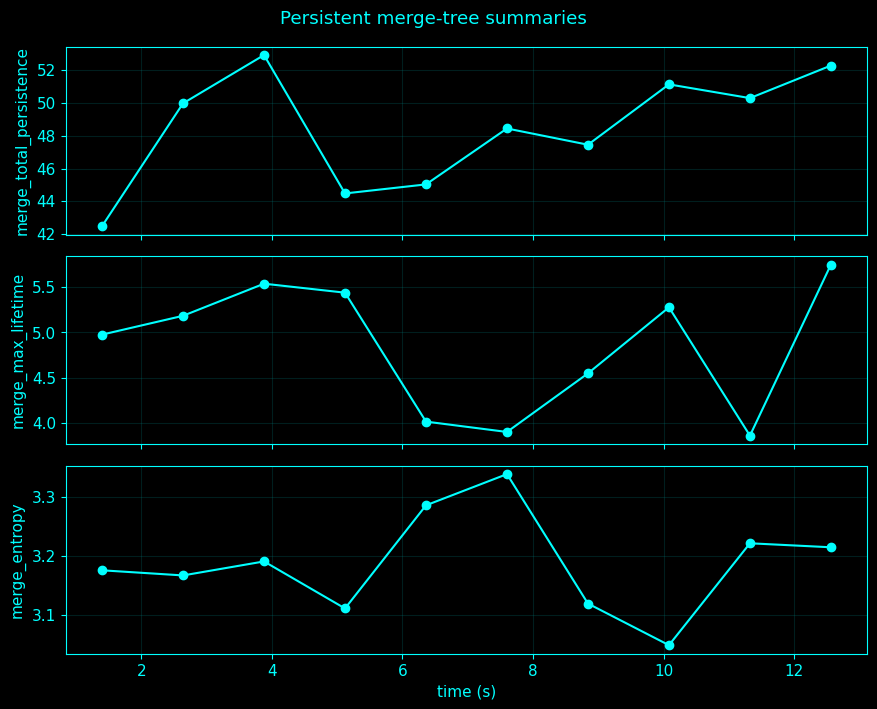

In [137]:
# Method 126: Persistent merge trees

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_126():

    i = 126
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _path_h0_persistence(y):
        y=np.asarray(y,float); n=len(y); parent=np.arange(n); birth=y.copy(); active=np.zeros(n,bool); pairs=[]
        def find(a):
            while parent[a]!=a:
                parent[a]=parent[parent[a]]; a=parent[a]
            return a
        for v in np.argsort(y,kind='stable'):
            active[v]=True; parent[v]=v; birth[v]=y[v]
            neigh=[u for u in (v-1,v+1) if 0<=u<n and active[u]]
            roots=[]
            for u in neigh:
                r=find(u)
                if r not in roots: roots.append(r)
            if not roots: continue
            # elder rule: oldest (lowest birth) survives
            allr=roots+[v]; survivor=min(allr,key=lambda r:(birth[find(r)],find(r))); survivor=find(survivor)
            for r in allr:
                r=find(r)
                if r==survivor: continue
                pairs.append([birth[r],y[v]]); parent[r]=survivor
            parent[v]=survivor
        roots={find(i) for i in range(n) if active[i]}; ess=[[birth[r],np.inf] for r in roots]
        return np.asarray(pairs+ess,float).reshape(-1,2)

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _windows(y,nw=None):
        y=np.asarray(y); nw=int(nw or _TOPO_SPEED['windows']); L=max(300,len(y)//max(4,nw//2)); step=max(1,(len(y)-L)//max(1,nw-1))
        ans=[]
        for st in range(0,max(1,len(y)-L+1),step):
            ans.append((st,st+L,y[st:st+L]))
            if len(ans)>=nw: break
        return ans

    # Method mathematics and output.
    rows = []
    for st, en, w in _windows(_topo_pc1, min(_TOPO_SPEED['windows'], 12)):
        yy = signal.resample(w, min(120, len(w)))
        d = _path_h0_persistence(yy)
        L = _life(d)
        rows.append([(st + en) / (2 * _topo_fs), L.sum(), L.max() if len(L) else 0, _pentropy(d)])
    out = pd.DataFrame(rows, columns=['time_s', 'merge_total_persistence', 'merge_max_lifetime', 'merge_entropy'])
    display(out)
    fig, axs = plt.subplots(3, 1, figsize=(9, 7.2), sharex=True, facecolor=TOPO_BG)
    for ax, col in zip(axs, ['merge_total_persistence', 'merge_max_lifetime', 'merge_entropy']):
        ax.plot(out['time_s'], out[col], color=TOPO_ACCENT, marker='o', linewidth=1.5)
        ax.set_ylabel(col)
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    axs[-1].set_xlabel('time (s)')
    fig.suptitle('Persistent merge-tree summaries')
    plt.tight_layout()
    plt.show()
    return


_topology_method_126()
del _topology_method_126


### 127. Contour tree analysis

For a scalar field on a simply connected domain, a contour tree is a cycle-free Reeb graph under generic conditions. The notebook constructs a finite quantized Reeb/contour approximation by connecting components in adjacent scalar bands and reports its cycle rank to diagnose departures from a tree.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


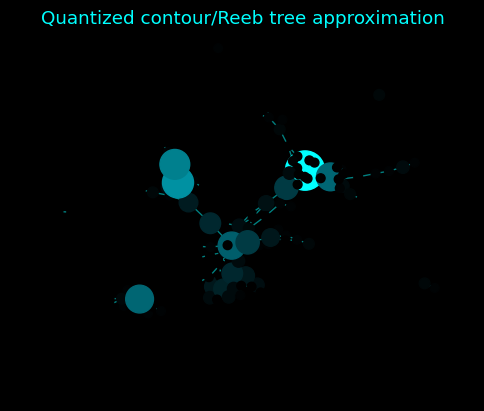

cycle_rank= 32


In [138]:
# Method 127: Contour tree analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_127():

    i = 127
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _component_graph_levels(A,mask=None,nlev=12):
        A=np.asarray(A,float); mask=np.isfinite(A) if mask is None else (np.asarray(mask,bool)&np.isfinite(A)); vals=A[mask]; qs=np.quantile(vals,np.linspace(0,1,nlev+1)); G=nx.Graph(); prev=[]; nid=0
        from scipy.ndimage import label
        for k in range(nlev):
            band=mask&(A>=qs[k])&(A<=qs[k+1] if k==nlev-1 else A<qs[k+1]); lab,num=label(band,structure=np.array([[0,1,0],[1,1,1],[0,1,0]])); cur=[]
            for j in range(1,num+1):
                pix=set(map(tuple,np.argwhere(lab==j))); G.add_node(nid,level=k,size=len(pix),pixels=pix,value=.5*(qs[k]+qs[k+1])); cur.append(nid); nid+=1
            # adjacent components in neighboring quantization bands form Reeb/contour edges
            for a in prev:
                pa=G.nodes[a]['pixels']
                for b in cur:
                    pb=G.nodes[b]['pixels']; touch=False
                    for r,c in pa:
                        if any((r+dr,c+dc) in pb for dr,dc in ((1,0),(-1,0),(0,1),(0,-1))): touch=True; break
                    if touch:G.add_edge(a,b)
            prev=cur
        return G

    def _draw_graph(G,title,node_values=None):
        fig,ax=plt.subplots(figsize=(6,4.8));
        if G.number_of_nodes():
            pos=nx.spring_layout(G,seed=0); vals=[G.nodes[n].get('size',1) for n in G] if node_values is None else node_values
            nx.draw_networkx_edges(G,pos,ax=ax,edge_color=TOPO_ACCENT,alpha=.5); nx.draw_networkx_nodes(G,pos,ax=ax,node_size=np.maximum(40,20*np.asarray(vals)),node_color=vals,cmap=TOPO_CMAP); ax.set_axis_off()
        ax.set_title(title); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    G = _component_graph_levels(_TOPO_TOPOMAP, _TOPO_SCALP_MASK, nlev=10)
    _draw_graph(G, 'Quantized contour/Reeb tree approximation')
    print('cycle_rank=', G.number_of_edges() - G.number_of_nodes() + nx.number_connected_components(G))
    return


_topology_method_127()
del _topology_method_127


### 128. Morse complex analysis

For a piecewise-linear scalar field, critical vertices can be classified from the topology of their lower and upper links. On the 8-neighbour grid ring, minima have empty lower link, maxima have empty upper link, and saddle candidates have at least two connected lower-link and upper-link components.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,row,col,value,type,lower_link_components,upper_link_components
0,4,12,0.049887,maximum,1,0
1,9,14,0.004136,minimum,0,1
2,9,9,0.004396,minimum,0,1
3,19,17,0.017402,minimum,0,1
4,9,10,0.004990,saddle,2,2
5,9,8,0.005725,saddle,2,2
6,10,7,0.007653,saddle,2,2
7,8,16,0.008010,saddle,2,2
8,12,7,0.008852,saddle,2,2
9,7,17,0.012781,saddle,2,2


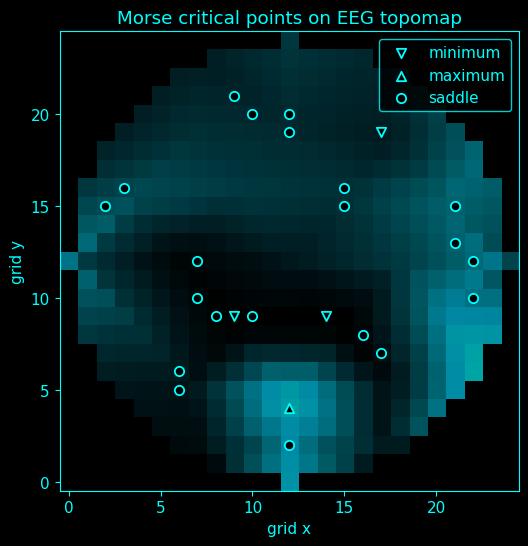

In [139]:
# Method 128: Morse complex analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_128():

    i = 128
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _cyclic_components(flags):
        f=np.asarray(flags,bool); n=len(f)
        if not f.any():return 0
        if f.all():return 1
        return int(np.sum(f & ~np.roll(f,1)))

    def _grid_critical_points(A,mask=None):
        A=np.asarray(A,float); mask=np.isfinite(A) if mask is None else (np.asarray(mask,bool)&np.isfinite(A)); rows=[]
        nr,nc=A.shape
        for r in range(1,nr-1):
            for c in range(1,nc-1):
                if not mask[r,c]:continue
                vals=[]; valid=True
                for dr,dc in _RING:
                    if not mask[r+dr,c+dc]: valid=False; break
                    vals.append(A[r+dr,c+dc])
                if not valid:continue
                vals=np.asarray(vals); lower=vals<A[r,c]; upper=vals>A[r,c]; lc=_cyclic_components(lower); uc=_cyclic_components(upper)
                kind='minimum' if lc==0 and uc>0 else 'maximum' if uc==0 and lc>0 else 'saddle' if lc>=2 and uc>=2 else None
                if kind: rows.append((r,c,float(A[r,c]),kind,lc,uc))
        return pd.DataFrame(rows,columns=['row','col','value','type','lower_link_components','upper_link_components'])

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    crit = _grid_critical_points(_TOPO_TOPOMAP, _TOPO_SCALP_MASK)
    out = crit.sort_values(['type', 'value']).reset_index(drop=True)
    display(out)
    fig, ax = plt.subplots(figsize=(6.2, 5.6), facecolor=TOPO_BG)
    ax.imshow(_TOPO_TOPOMAP, cmap=TOPO_CMAP, origin='lower', alpha=0.65)
    markers = {'minimum': 'v', 'maximum': '^', 'saddle': 'o'}
    for kind, mk in markers.items():
        q = crit[crit['type'] == kind]
        if len(q):
            ax.scatter(q['col'], q['row'], marker=mk, s=45, facecolors=TOPO_BG, edgecolors=TOPO_ACCENT, linewidths=1.3, label=kind)
    ax.set_title('Morse critical points on EEG topomap')
    ax.set_xlabel('grid x')
    ax.set_ylabel('grid y')
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_128()
del _topology_method_128


### 129. Morse-Smale complex analysis

A Morse–Smale complex partitions a domain by intersections of ascending and descending manifolds of critical points. The discrete approximation here follows steepest ascent and descent on the scalp grid; each vertex is labelled by its terminal maximum/minimum pair, producing finite Morse–Smale cells.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


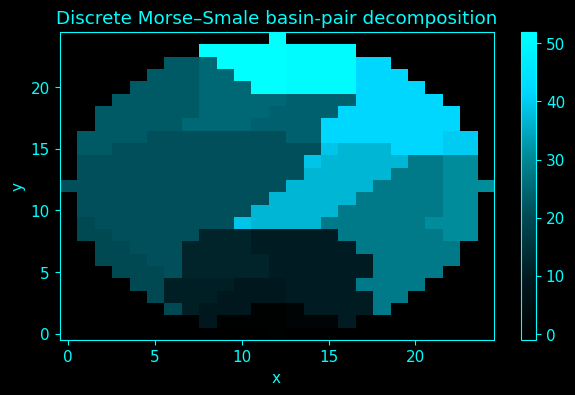

ascending basins= 6 descending basins= 8 Morse-Smale cells= 19


In [140]:
# Method 129: Morse-Smale complex analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_129():

    i = 129
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    def _steepest_basin_labels(A,mask,ascend=True):
        A=np.asarray(A,float); mask=np.asarray(mask,bool); nr,nc=A.shape; dest={}
        dirs=[(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]
        def flow(start):
            if start in dest:return dest[start]
            path=[]; cur=start
            while True:
                if cur in dest: end=dest[cur]; break
                path.append(cur); r,c=cur; cand=[]
                for dr,dc in dirs:
                    rr,cc=r+dr,c+dc
                    if 0<=rr<nr and 0<=cc<nc and mask[rr,cc]: cand.append((rr,cc))
                if not cand: end=cur; break
                nxt=(max if ascend else min)(cand,key=lambda q:A[q])
                if (A[nxt]<=A[cur] if ascend else A[nxt]>=A[cur]): end=cur; break
                cur=nxt
            for q in path:dest[q]=end
            return end
        labs=np.full((nr,nc),-1,int); ids={}
        for r,c in zip(*np.where(mask)):
            d=flow((r,c)); ids.setdefault(d,len(ids)); labs[r,c]=ids[d]
        return labs,ids

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    asc, ma = _steepest_basin_labels(_TOPO_TOPOMAP, _TOPO_SCALP_MASK, True)
    desc, mi = _steepest_basin_labels(_TOPO_TOPOMAP, _TOPO_SCALP_MASK, False)
    pair = np.where(_TOPO_SCALP_MASK, asc * (len(mi) + 1) + desc, -1)
    _imshow(pair, 'Discrete Morse–Smale basin-pair decomposition', 'x', 'y')
    print('ascending basins=', len(ma), 'descending basins=', len(mi), 'Morse-Smale cells=', len(np.unique(pair[pair >= 0])))
    return


_topology_method_129()
del _topology_method_129


### 130. Persistent Morse theory

Persistent Morse theory pairs critical events across the sublevel filtration: low-persistence critical-point pairs can be cancelled while long-lived pairs represent robust topology. The cell uses cubical persistence lifetimes as the cancellation scale rather than treating every detected critical vertex as equally important.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,homology_dim,birth,death,persistence
20,0,0.027889,0.038774,0.010886
7,0,0.010396,0.018056,0.007660
22,1,0.042697,0.049887,0.007190
6,0,0.010396,0.016653,0.006257
21,0,0.032691,0.038774,0.006083
16,0,0.017136,0.023115,0.005979
17,0,0.017402,0.023350,0.005948
19,0,0.030196,0.034810,0.004614
15,0,0.018186,0.021457,0.003271
5,0,0.010152,0.012781,0.002629


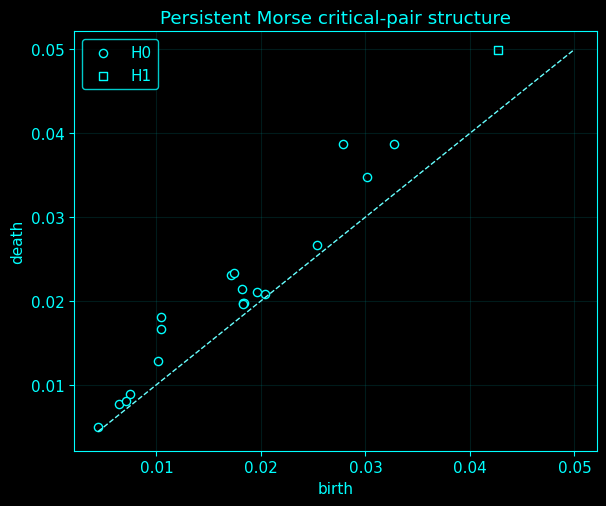

In [141]:
# Method 130: Persistent Morse theory

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_130():

    i = 130
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    rows = []
    for k, d in enumerate(dg):
        for b, de in _finite(d):
            if de - b > 1e-12:
                rows.append([k, b, de, de - b])
    out = pd.DataFrame(rows, columns=['homology_dim', 'birth', 'death', 'persistence']).sort_values('persistence', ascending=False).head(20)
    display(out)
    if len(out):
        fig, ax = plt.subplots(figsize=(6.2, 5.2), facecolor=TOPO_BG)
        for h, mk in [(0, 'o'), (1, 's')]:
            q = out[out['homology_dim'] == h]
            if len(q):
                ax.scatter(q['birth'], q['death'], s=35, marker=mk, facecolors=TOPO_BG, edgecolors=TOPO_ACCENT, label=f'H{h}')
        lo = min(float(out['birth'].min()), float(out['death'].min()))
        hi = max(float(out['birth'].max()), float(out['death'].max()))
        ax.plot([lo, hi], [lo, hi], color=TOPO_CYAN_SOFT, linestyle='--', linewidth=1.0)
        ax.set_title('Persistent Morse critical-pair structure')
        ax.set_xlabel('birth')
        ax.set_ylabel('death')
        ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.2)
        ax.legend()
        plt.tight_layout()
        plt.show()
    return


_topology_method_130()
del _topology_method_130


### 131. Critical point persistence

Critical-point persistence combines discrete link-based critical-point detection with cubical persistence. Morse theory relates changes in sublevel topology to critical levels; the persistence diagram identifies which such topological changes survive over broad threshold ranges.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,row,col,value,type,lower_link_components,upper_link_components
0,2,12,0.042697,saddle,2,2
1,4,12,0.049887,maximum,1,0
2,5,6,0.014499,saddle,2,2
3,6,6,0.016653,saddle,2,2
4,7,17,0.012781,saddle,2,2
5,8,16,0.008010,saddle,2,2
6,9,8,0.005725,saddle,2,2
7,9,9,0.004396,minimum,0,1
8,9,10,0.004990,saddle,2,2
9,9,14,0.004136,minimum,0,1


H0/H1 positive lifetimes: [22, 1]


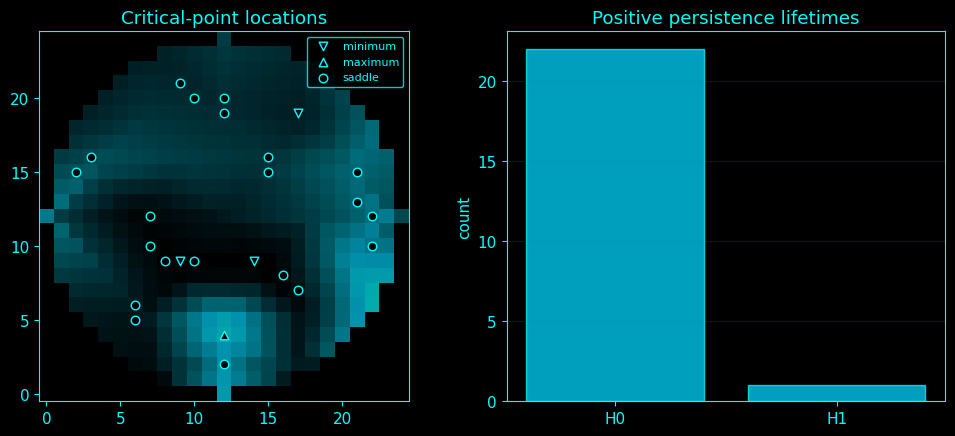

In [142]:
# Method 131: Critical point persistence

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_131():

    i = 131
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _cyclic_components(flags):
        f=np.asarray(flags,bool); n=len(f)
        if not f.any():return 0
        if f.all():return 1
        return int(np.sum(f & ~np.roll(f,1)))

    def _grid_critical_points(A,mask=None):
        A=np.asarray(A,float); mask=np.isfinite(A) if mask is None else (np.asarray(mask,bool)&np.isfinite(A)); rows=[]
        nr,nc=A.shape
        for r in range(1,nr-1):
            for c in range(1,nc-1):
                if not mask[r,c]:continue
                vals=[]; valid=True
                for dr,dc in _RING:
                    if not mask[r+dr,c+dc]: valid=False; break
                    vals.append(A[r+dr,c+dc])
                if not valid:continue
                vals=np.asarray(vals); lower=vals<A[r,c]; upper=vals>A[r,c]; lc=_cyclic_components(lower); uc=_cyclic_components(upper)
                kind='minimum' if lc==0 and uc>0 else 'maximum' if uc==0 and lc>0 else 'saddle' if lc>=2 and uc>=2 else None
                if kind: rows.append((r,c,float(A[r,c]),kind,lc,uc))
        return pd.DataFrame(rows,columns=['row','col','value','type','lower_link_components','upper_link_components'])

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    crit = _grid_critical_points(_TOPO_TOPOMAP, _TOPO_SCALP_MASK)
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    display(crit)
    life_counts = [len(_life(d)) for d in dg]
    print('H0/H1 positive lifetimes:', life_counts)
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.5), facecolor=TOPO_BG)
    axs[0].imshow(_TOPO_TOPOMAP, cmap=TOPO_CMAP, origin='lower', alpha=0.68)
    for kind, mk in {'minimum': 'v', 'maximum': '^', 'saddle': 'o'}.items():
        q = crit[crit['type'] == kind]
        if len(q):
            axs[0].scatter(q['col'], q['row'], marker=mk, s=38, facecolors=TOPO_BG, edgecolors=TOPO_ACCENT, label=kind)
    axs[0].set_title('Critical-point locations')
    axs[0].legend(fontsize=8)
    axs[1].bar(['H0', 'H1'], life_counts[:2], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[1].set_title('Positive persistence lifetimes')
    axs[1].set_ylabel('count')
    axs[1].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_131()
del _topology_method_131


### 132. Scalar-field topology of EEG maps

Scalar-field topology of the EEG scalp map combines critical-point counts, cubical H1 persistence, persistence entropy and the Euler-characteristic curve. These are complementary summaries of one interpolated alpha-power scalar field, not interchangeable definitions of topology.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


,critical_type
type,
saddle,21
minimum,3
maximum,1


H1 total= 0.007190155927205337 H1 entropy= -1.000088900581841e-12 Euler curve range= 7.0


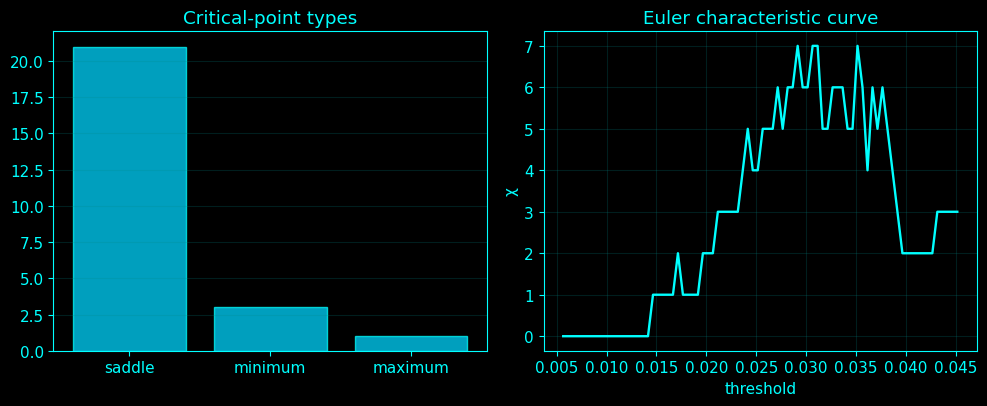

In [143]:
# Method 132: Scalar-field topology of EEG maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_132():

    i = 132
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _bandpower_values(seg,lo=8,hi=13):
        seg=np.asarray(seg,float); vals=[]
        for j in range(seg.shape[1]):
            f,P=signal.welch(seg[:,j],fs=_topo_fs,nperseg=min(512,len(seg)))
            m=(f>=lo)&(f<=min(hi,_topo_fs/2-.5)); vals.append(float(np.trapezoid(P[m],f[m])) if np.sum(m)>1 else float(P[m][0]) if np.any(m) else 0.0)
        return np.asarray(vals)

    def _ph_cells(cells,maxdim=2):
        """Persistent homology over Z2 for an arbitrary finite filtered cell complex.
        cells: list of (cell_id, filtration, dimension, boundary_ids)."""
        cells=sorted(cells,key=lambda z:(float(z[1]),int(z[2]),str(z[0])))
        index={z[0]:i for i,z in enumerate(cells)}
        R=[]; low_to_col={}; births=set(); pairs=[]
        for j,(cid,filt,dim,boundary) in enumerate(cells):
            col={index[b] for b in boundary if b in index}
            while col:
                low=max(col)
                if low in low_to_col: col ^= R[low_to_col[low]]
                else: break
            R.append(set(col))
            if col:
                low=max(col); low_to_col[low]=j; bdim=cells[low][2]
                if bdim<=maxdim: pairs.append((bdim,float(cells[low][1]),float(filt)))
            else: births.add(j)
        paired=set(low_to_col)
        out=[]
        for d in range(maxdim+1):
            arr=[[b,de] for dd,b,de in pairs if dd==d]
            for j in sorted(births-paired):
                if cells[j][2]==d: arr.append([float(cells[j][1]),np.inf])
            out.append(np.asarray(arr,float).reshape(-1,2) if arr else np.empty((0,2)))
        return out

    def _cubical_ph(A,upper=False):
        A=np.asarray(A,float); A=(-A if upper else A); nr,nc=A.shape; cells=[]
        # lower-star filtration on grid vertices; edge/square value=max of incident vertices
        for r in range(nr):
            for c in range(nc): cells.append((('v',r,c),float(A[r,c]),0,[]))
        for r in range(nr):
            for c in range(nc-1): cells.append((('eh',r,c),float(max(A[r,c],A[r,c+1])),1,[('v',r,c),('v',r,c+1)]))
        for r in range(nr-1):
            for c in range(nc): cells.append((('ev',r,c),float(max(A[r,c],A[r+1,c])),1,[('v',r,c),('v',r+1,c)]))
        for r in range(nr-1):
            for c in range(nc-1):
                val=float(np.max(A[r:r+2,c:c+2])); bd=[('eh',r,c),('eh',r+1,c),('ev',r,c),('ev',r,c+1)]
                cells.append((('sq',r,c),val,2,bd))
        dg=_ph_cells(cells,1)
        if upper:
            # transform filtration coordinates back to original superlevel threshold convention
            for d in range(len(dg)):
                if len(dg[d]): dg[d]=-dg[d][:,::-1]
        return dg

    def _ec_binary_vertices(M):
        M=np.asarray(M,bool); V=int(M.sum())
        Eh=int(np.sum(M[:,:-1]&M[:,1:])); Ev=int(np.sum(M[:-1,:]&M[1:,:])); E=Eh+Ev
        F=int(np.sum(M[:-1,:-1]&M[1:,:-1]&M[:-1,1:]&M[1:,1:]))
        return V-E+F

    def _ec_curve_field(A,grid=None,superlevel=False):
        A=np.asarray(A,float); finite=np.isfinite(A); vals=A[finite]
        if grid is None: grid=np.linspace(np.quantile(vals,.02),np.quantile(vals,.98),80)
        chi=[]
        for t in grid:
            M=finite & ((A>=t) if superlevel else (A<=t)); chi.append(_ec_binary_vertices(M))
        return np.asarray(grid),np.asarray(chi,float)

    def _cyclic_components(flags):
        f=np.asarray(flags,bool); n=len(f)
        if not f.any():return 0
        if f.all():return 1
        return int(np.sum(f & ~np.roll(f,1)))

    def _grid_critical_points(A,mask=None):
        A=np.asarray(A,float); mask=np.isfinite(A) if mask is None else (np.asarray(mask,bool)&np.isfinite(A)); rows=[]
        nr,nc=A.shape
        for r in range(1,nr-1):
            for c in range(1,nc-1):
                if not mask[r,c]:continue
                vals=[]; valid=True
                for dr,dc in _RING:
                    if not mask[r+dr,c+dc]: valid=False; break
                    vals.append(A[r+dr,c+dc])
                if not valid:continue
                vals=np.asarray(vals); lower=vals<A[r,c]; upper=vals>A[r,c]; lc=_cyclic_components(lower); uc=_cyclic_components(upper)
                kind='minimum' if lc==0 and uc>0 else 'maximum' if uc==0 and lc>0 else 'saddle' if lc>=2 and uc>=2 else None
                if kind: rows.append((r,c,float(A[r,c]),kind,lc,uc))
        return pd.DataFrame(rows,columns=['row','col','value','type','lower_link_components','upper_link_components'])

    def _finite(dgm):
        d=np.asarray(dgm,float).reshape(-1,2)
        return d[np.isfinite(d[:,1])] if len(d) else d

    def _life(dgm):
        d=_finite(dgm)
        if not len(d): return np.empty(0)
        L=np.maximum(d[:,1]-d[:,0],0.0)
        scale=max(1.0,float(np.nanmax(np.abs(d))))
        return L[L > 1e-12*scale]

    def _pentropy(dgm):
        L=_life(dgm); s=L.sum()
        if s<=TOPO_EPS:return 0.0
        p=L/s; return float(-(p*np.log(p+TOPO_EPS)).sum())

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method-local derived quantities required by this method.
    _TOPO_ALPHA_BP = _bandpower_values(_topo_x, 8, min(13, _topo_fs / 2 - 0.5))
    _TOPO_XG, _TOPO_YG, _TOPO_TOPOMAP, _TOPO_SCALP_MASK = _scalp_grid(_TOPO_ALPHA_BP, n=25)

    # Method mathematics and output.
    crit = _grid_critical_points(_TOPO_TOPOMAP, _TOPO_SCALP_MASK)
    dg = _cubical_ph(np.nan_to_num(_TOPO_TOPOMAP, nan=np.nanmax(_TOPO_TOPOMAP)))
    g, c = _ec_curve_field(_TOPO_TOPOMAP, superlevel=True)
    counts = crit['type'].value_counts()
    out = pd.DataFrame({'critical_type': counts})
    display(out)
    print('H1 total=', float(_life(dg[1]).sum()), 'H1 entropy=', _pentropy(dg[1]), 'Euler curve range=', float(np.ptp(c)))
    fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), facecolor=TOPO_BG)
    axs[0].bar(counts.index, counts.to_numpy(), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    axs[0].set_title('Critical-point types')
    axs[0].grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    axs[1].plot(g, c, color=TOPO_ACCENT, linewidth=1.7)
    axs[1].set_title('Euler characteristic curve')
    axs[1].set_xlabel('threshold')
    axs[1].set_ylabel('χ')
    axs[1].grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_132()
del _topology_method_132


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and role — cohomology and Hodge helpers for topology methods 133–169</h3>
<p>This block constructs chain/cochain boundary operators over \(\mathbb Z_2\), representative cycles/cocycles, Alexander–Whitney cup products, \(Sq^1\) on degree-one classes via cup square, conditional triple Massey products, and real-valued Hodge Laplacians. Betti numbers obey \(\beta_k=\dim\ker\partial_k-\mathrm{rank}\,\partial_{k+1}\); Hodge harmonic dimensions reproduce the corresponding real cohomology ranks.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [144]:
# =======================================================
# TOPOLOGY CATALOGUE IMPORTS — methods 133–169
# No shared mathematical helper functions.
# =======================================================
from scipy.linalg import null_space


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Execution router — topology methods 133–169</h3>
<p>This dispatcher selects the requested homology/cohomology, cup-product, Steenrod/Massey, Hodge, or simplicial-signal-processing calculation. Undefined higher operations are reported as such unless their algebraic defining conditions are satisfied.</p>
</div>

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


### 133. Persistent cohomology

Over a field, persistent cohomology has the same barcode interval decomposition as persistent homology, but works with cochains. At each graph threshold the notebook computes \(H^1=\ker\delta^1/\operatorname{im}\delta^0\) and \(H^2=\ker\delta^2/\operatorname{im}\delta^1\) over \(\mathbb Z_2\), where \(\delta^k=(\partial_{k+1})^T\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A derivative measures how quickly one quantity changes when another changes. Partial derivatives are used when a function depends on several variables.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,similarity_threshold,dim_H1_cohomology,dim_H2_cohomology
0,0.869410,0,0
1,0.846964,0,0
2,0.837220,0,0
3,0.716079,0,0


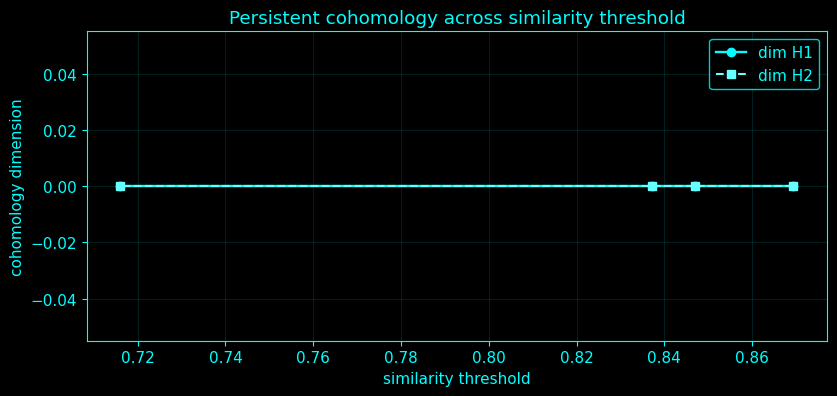

In [145]:
# Method 133: Persistent cohomology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_133():

    i = 133
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    rows = []
    for q in [0.75, 0.68, 0.6, 0.52]:
        sp, _, t = _flag_simplices_similarity(S, q, 3)
        b1, b2, b3 = _complex_boundaries(sp)
        rows.append([t, _cohom_basis_H1(b1, b2).shape[1], _cohom_basis_H2(b2, b3).shape[1]])
    out = pd.DataFrame(rows, columns=['similarity_threshold', 'dim_H1_cohomology', 'dim_H2_cohomology'])
    display(out)
    fig, ax = plt.subplots(figsize=(8.5, 4.1), facecolor=TOPO_BG)
    ax.plot(out['similarity_threshold'], out['dim_H1_cohomology'], color=TOPO_ACCENT, marker='o', linewidth=1.7, label='dim H1')
    ax.plot(out['similarity_threshold'], out['dim_H2_cohomology'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.5, label='dim H2')
    ax.set_title('Persistent cohomology across similarity threshold')
    ax.set_xlabel('similarity threshold')
    ax.set_ylabel('cohomology dimension')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return


_topology_method_133()
del _topology_method_133


### 134. Representative cocycles

A representative H1 cocycle is an edge 1-cochain \(a\) satisfying \(\delta^1a=0\) but not \(a=\delta^0f\). The cell obtains a quotient basis of \(\ker B_2^T/\operatorname{im}B_1^T\) over \(\mathbb Z_2\) and lists the edges on which the first cocycle is nonzero.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [146]:
# Method 134: Representative cocycles

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_134():

    i = 134
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    if Hc.shape[1] == 0:
        print('No nontrivial H1 cocycle at this threshold.')
        return
    a = Hc[:, 0]
    out = pd.DataFrame({'edge': [simp[1][j] for j in np.where(a)[0]], 'cocycle_value': 1})
    display(out)
    G = nx.Graph()
    G.add_nodes_from(range(len(simp[0])))
    G.add_edges_from(out['edge'].tolist())
    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=(6, 5.2), facecolor=TOPO_BG)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=TOPO_ACCENT, width=2.0, alpha=0.85)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=TOPO_BG, edgecolors=TOPO_CYAN_FILL, node_size=280, linewidths=1.3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color=TOPO_ACCENT, font_size=8)
    ax.set_title('Representative H1 cocycle support')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    return


_topology_method_134()
del _topology_method_134


No nontrivial H1 cocycle at this threshold.


### 135. Representative cycles

A representative H1 cycle is an edge chain \(z\) with \(B_1z=0\), modulo triangle boundaries \(\operatorname{im}B_2\). The basis is computed directly as \(\ker B_1/\operatorname{im}B_2\) over \(\mathbb Z_2\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [147]:
# Method 135: Representative cycles

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_135():

    i = 135
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _hom_basis_H1(B1,B2):
        # H_1 = ker(B1) / im(B2)
        K=_gf2_nullspace(np.rint(B1).astype(np.uint8)%2); I=np.rint(B2).astype(np.uint8)%2
        return _gf2_quotient_basis(K,I)

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hh = _hom_basis_H1(B1, B2)
    if Hh.shape[1] == 0:
        print('No nontrivial H1 cycle at this threshold.')
        return
    z = Hh[:, 0]
    out = pd.DataFrame({'edge': [simp[1][j] for j in np.where(z)[0]], 'cycle_coefficient_mod2': 1})
    display(out)
    G = nx.Graph()
    G.add_nodes_from(range(len(simp[0])))
    G.add_edges_from(out['edge'].tolist())
    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=(6, 5.2), facecolor=TOPO_BG)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=TOPO_ACCENT, width=2.0, alpha=0.85)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=TOPO_BG, edgecolors=TOPO_CYAN_FILL, node_size=280, linewidths=1.3)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color=TOPO_ACCENT, font_size=8)
    ax.set_title('Representative H1 cycle support')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    return


_topology_method_135()
del _topology_method_135


No nontrivial H1 cycle at this threshold.


### 136. Persistent cycle localization

Persistent cycle localization maps algebraic H1 representatives back to their supporting graph edges. Representatives are not unique: adding a triangle boundary yields the same homology class, so the displayed support is one valid basis representative rather than a canonical anatomical loop.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [148]:
# Method 136: Persistent cycle localization

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_136():

    i = 136
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _hom_basis_H1(B1,B2):
        # H_1 = ker(B1) / im(B2)
        K=_gf2_nullspace(np.rint(B1).astype(np.uint8)%2); I=np.rint(B2).astype(np.uint8)%2
        return _gf2_quotient_basis(K,I)

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hh = _hom_basis_H1(B1, B2)
    if Hh.shape[1] == 0:
        print('No nontrivial H1 generator at this threshold.')
        return
    rows = []
    for k in range(Hh.shape[1]):
        idx = np.where(Hh[:, k])[0]
        rows.append([k, len(idx), [simp[1][j] for j in idx]])
    out = pd.DataFrame(rows, columns=['generator', 'edge_count', 'representative_edges'])
    display(out)
    fig, ax = plt.subplots(figsize=(8, 4.1), facecolor=TOPO_BG)
    ax.bar(out['generator'].astype(str), out['edge_count'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Persistent H1 generator support sizes' if i == 137 else 'Persistent cycle localization')
    ax.set_xlabel('generator')
    ax.set_ylabel('edge count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_136()
del _topology_method_136


No nontrivial H1 generator at this threshold.


### 137. Persistent H1 generators

Persistent H1 generators are explicit basis vectors for \(H_1\). Each generator is a closed edge chain not homologous to a combination of triangle boundaries; the cell reports its support size and representative edges.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [149]:
# Method 137: Persistent H1 generators

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_137():

    i = 137
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _hom_basis_H1(B1,B2):
        # H_1 = ker(B1) / im(B2)
        K=_gf2_nullspace(np.rint(B1).astype(np.uint8)%2); I=np.rint(B2).astype(np.uint8)%2
        return _gf2_quotient_basis(K,I)

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hh = _hom_basis_H1(B1, B2)
    if Hh.shape[1] == 0:
        print('No nontrivial H1 generator at this threshold.')
        return
    rows = []
    for k in range(Hh.shape[1]):
        idx = np.where(Hh[:, k])[0]
        rows.append([k, len(idx), [simp[1][j] for j in idx]])
    out = pd.DataFrame(rows, columns=['generator', 'edge_count', 'representative_edges'])
    display(out)
    fig, ax = plt.subplots(figsize=(8, 4.1), facecolor=TOPO_BG)
    ax.bar(out['generator'].astype(str), out['edge_count'], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Persistent H1 generator support sizes' if i == 137 else 'Persistent cycle localization')
    ax.set_xlabel('generator')
    ax.set_ylabel('edge count')
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_137()
del _topology_method_137


No nontrivial H1 generator at this threshold.


### 138. Circular coordinates from H1 cocycles

Circular coordinates can be constructed from an integral H1 cocycle. On a graph, a cycle-basis matrix \(C\) is used to build a minimum-norm edge cochain \(\alpha\) with integer periods \(C\alpha=e_1\). Integrating \(\alpha\) along a spanning tree gives a vertex function \(\theta\bmod1\), which is path-independent modulo integers.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


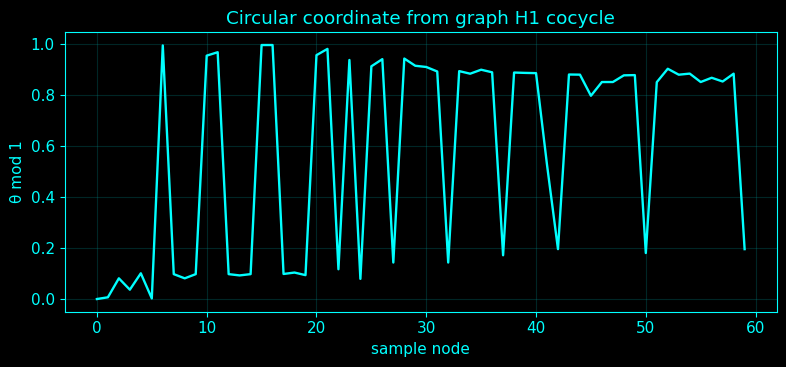

In [150]:
# Method 138: Circular coordinates from H1 cocycles

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_138():

    i = 138
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _graph_integral_cocycle_coordinates(G):
        # Integer-period graph cocycle via a fundamental cycle basis and minimum-norm dual cochain.
        if G.number_of_edges()==0:return np.array([]),np.zeros((0,0)),[]
        edges=[tuple(sorted(e)) for e in G.edges()]; eidx={e:i for i,e in enumerate(edges)}; cycles=nx.cycle_basis(G)
        if not cycles:return np.zeros(G.number_of_nodes()),np.zeros((len(edges),0)),cycles
        C=[]
        for cyc in cycles:
            row=np.zeros(len(edges)); seq=cyc+[cyc[0]]
            for a,b in zip(seq[:-1],seq[1:]):
                e=tuple(sorted((a,b))); row[eidx[e]] += 1 if a<b else -1
            C.append(row)
        C=np.asarray(C,float); alpha=C.T@np.linalg.pinv(C@C.T)[:,0]  # periods: first basis cycle=1, others=0
        T=nx.minimum_spanning_tree(G); root=list(G.nodes())[0]; theta=np.zeros(G.number_of_nodes())
        for v in G.nodes():
            if v==root:continue
            path=nx.shortest_path(T,root,v); val=0.
            for a,b in zip(path[:-1],path[1:]):
                e=tuple(sorted((a,b))); val += alpha[eidx[e]]*(1 if a<b else -1)
            theta[v]=val%1.0
        return theta,alpha[:,None],cycles

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(80, _TOPO_MAPPER_POINTS))
    D = squareform(pdist(X))
    k = min(5, len(X) - 1)
    G = nx.Graph()
    G.add_nodes_from(range(len(X)))
    for a in range(len(X)):
        for b in np.argsort(D[a])[1:k + 1]:
            G.add_edge(a, int(b), weight=float(D[a, b]))
    th1, _, cyc = _graph_integral_cocycle_coordinates(G)
    trueph = np.angle(signal.hilbert(_topo_pc1))
    samp = np.linspace(0, len(trueph) - 1, len(th1)).astype(int)
    circ = abs(np.mean(np.exp(1j * (2 * np.pi * th1 - trueph[samp])))) if len(th1) else np.nan
    _plot_line(np.arange(len(th1)), th1, 'Circular coordinate from graph H1 cocycle', 'sample node', 'θ mod 1')
    return


_topology_method_138()
del _topology_method_138


### 139. Toroidal coordinates from multiple H1 generators

Two independent circle-valued coordinates \((\theta_1,\theta_2)\in S^1\times S^1\) form a toroidal coordinate system. The notebook obtains a second graph-H1 coordinate after removing a dominant chord from the first cycle structure; it is a finite graph construction, not proof that the underlying EEG manifold is a torus.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


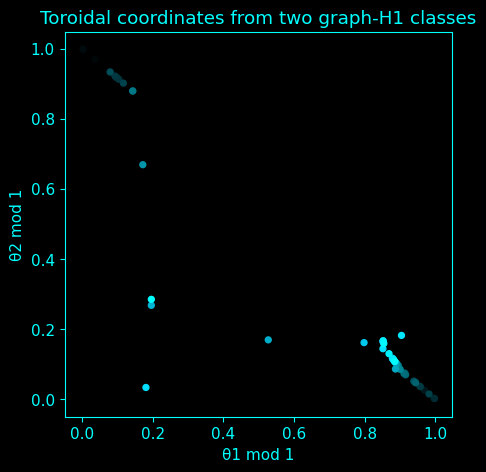

In [151]:
# Method 139: Toroidal coordinates from multiple H1 generators

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_139():

    i = 139
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _graph_integral_cocycle_coordinates(G):
        # Integer-period graph cocycle via a fundamental cycle basis and minimum-norm dual cochain.
        if G.number_of_edges()==0:return np.array([]),np.zeros((0,0)),[]
        edges=[tuple(sorted(e)) for e in G.edges()]; eidx={e:i for i,e in enumerate(edges)}; cycles=nx.cycle_basis(G)
        if not cycles:return np.zeros(G.number_of_nodes()),np.zeros((len(edges),0)),cycles
        C=[]
        for cyc in cycles:
            row=np.zeros(len(edges)); seq=cyc+[cyc[0]]
            for a,b in zip(seq[:-1],seq[1:]):
                e=tuple(sorted((a,b))); row[eidx[e]] += 1 if a<b else -1
            C.append(row)
        C=np.asarray(C,float); alpha=C.T@np.linalg.pinv(C@C.T)[:,0]  # periods: first basis cycle=1, others=0
        T=nx.minimum_spanning_tree(G); root=list(G.nodes())[0]; theta=np.zeros(G.number_of_nodes())
        for v in G.nodes():
            if v==root:continue
            path=nx.shortest_path(T,root,v); val=0.
            for a,b in zip(path[:-1],path[1:]):
                e=tuple(sorted((a,b))); val += alpha[eidx[e]]*(1 if a<b else -1)
            theta[v]=val%1.0
        return theta,alpha[:,None],cycles

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(80, _TOPO_MAPPER_POINTS))
    D = squareform(pdist(X))
    k = min(5, len(X) - 1)
    G = nx.Graph()
    G.add_nodes_from(range(len(X)))
    for a in range(len(X)):
        for b in np.argsort(D[a])[1:k + 1]:
            G.add_edge(a, int(b), weight=float(D[a, b]))
    th1, _, cyc = _graph_integral_cocycle_coordinates(G)
    G2 = G.copy()
    if cyc:
        c = cyc[0]
        seq = c + [c[0]]
        e = max(zip(seq[:-1], seq[1:]), key=lambda ab: D[ab[0], ab[1]])
        G2.remove_edge(*e)
    th2, _, _ = _graph_integral_cocycle_coordinates(G2)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(th1, th2, s=18, c=np.arange(len(th1)), cmap=TOPO_CMAP)
    ax.set_xlabel('θ1 mod 1')
    ax.set_ylabel('θ2 mod 1')
    ax.set_title('Toroidal coordinates from two graph-H1 classes')
    plt.show()
    return
    trueph = np.angle(signal.hilbert(_topo_pc1))
    samp = np.linspace(0, len(trueph) - 1, len(th1)).astype(int)
    circ = abs(np.mean(np.exp(1j * (2 * np.pi * th1 - trueph[samp])))) if len(th1) else np.nan
    _plot_line(np.arange(len(th1)), th1, 'Circular coordinate from graph H1 cocycle', 'sample node', 'θ mod 1')
    return


_topology_method_139()
del _topology_method_139


### 140. Cohomology-based phase coordinates

The cocycle-derived circular coordinate is compared with the analytic Hilbert phase of the PC1 signal using circular alignment \(|\langle e^{i(2\pi\theta-\phi)}\rangle|\). Agreement tests whether the topological coordinate follows an oscillatory phase variable.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [152]:
# Method 140: Cohomology-based phase coordinates

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_140():

    i = 140
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _delay_embed(y,m=3,tau=2,max_points=None):
        y=np.asarray(y,float).ravel(); m=int(m); tau=int(tau)
        n=len(y)-(m-1)*tau
        if n<3: return np.empty((0,m))
        X=np.column_stack([y[j*tau:j*tau+n] for j in range(m)])
        if max_points is None: max_points=_TOPO_SPEED['points']
        if len(X)>max_points:
            idx=np.linspace(0,len(X)-1,max_points).astype(int); X=X[idx]
        X=(X-X.mean(0,keepdims=True))/(X.std(0,keepdims=True)+TOPO_EPS)
        return X

    def _graph_integral_cocycle_coordinates(G):
        # Integer-period graph cocycle via a fundamental cycle basis and minimum-norm dual cochain.
        if G.number_of_edges()==0:return np.array([]),np.zeros((0,0)),[]
        edges=[tuple(sorted(e)) for e in G.edges()]; eidx={e:i for i,e in enumerate(edges)}; cycles=nx.cycle_basis(G)
        if not cycles:return np.zeros(G.number_of_nodes()),np.zeros((len(edges),0)),cycles
        C=[]
        for cyc in cycles:
            row=np.zeros(len(edges)); seq=cyc+[cyc[0]]
            for a,b in zip(seq[:-1],seq[1:]):
                e=tuple(sorted((a,b))); row[eidx[e]] += 1 if a<b else -1
            C.append(row)
        C=np.asarray(C,float); alpha=C.T@np.linalg.pinv(C@C.T)[:,0]  # periods: first basis cycle=1, others=0
        T=nx.minimum_spanning_tree(G); root=list(G.nodes())[0]; theta=np.zeros(G.number_of_nodes())
        for v in G.nodes():
            if v==root:continue
            path=nx.shortest_path(T,root,v); val=0.
            for a,b in zip(path[:-1],path[1:]):
                e=tuple(sorted((a,b))); val += alpha[eidx[e]]*(1 if a<b else -1)
            theta[v]=val%1.0
        return theta,alpha[:,None],cycles

    # Method mathematics and output.
    X = _delay_embed(_topo_pc1, 3, max(1, int(0.01 * _topo_fs)), max_points=min(80, _TOPO_MAPPER_POINTS))
    D = squareform(pdist(X))
    k = min(5, len(X) - 1)
    G = nx.Graph()
    G.add_nodes_from(range(len(X)))
    for a in range(len(X)):
        for b in np.argsort(D[a])[1:k + 1]:
            G.add_edge(a, int(b), weight=float(D[a, b]))
    th1, _, cyc = _graph_integral_cocycle_coordinates(G)
    trueph = np.angle(signal.hilbert(_topo_pc1))
    samp = np.linspace(0, len(trueph) - 1, len(th1)).astype(int)
    circ = abs(np.mean(np.exp(1j * (2 * np.pi * th1 - trueph[samp])))) if len(th1) else np.nan
    print('Circular alignment with analytic PC1 phase =', float(circ))
    return


_topology_method_140()
del _topology_method_140


Circular alignment with analytic PC1 phase = 0.19084184778603622


### 141. Cohomology-based EEG phase maps

For the channel graph, an integral-period graph cocycle is integrated to a circle-valued coordinate on electrodes and interpolated over the scalp. The resulting phase map is cohomology-derived; it is not the same as instantaneous Hilbert phase at each electrode.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


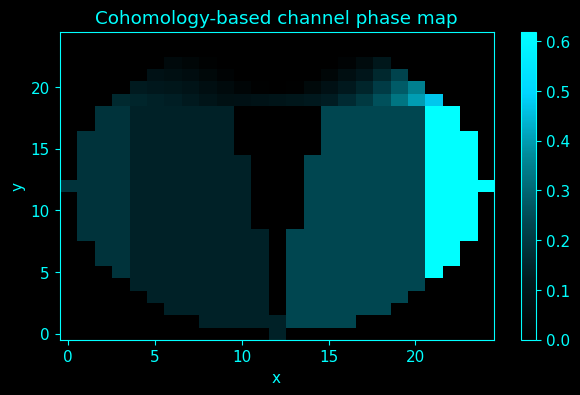

In [153]:
# Method 141: Cohomology-based EEG phase maps

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_141():

    i = 141
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _graph_integral_cocycle_coordinates(G):
        # Integer-period graph cocycle via a fundamental cycle basis and minimum-norm dual cochain.
        if G.number_of_edges()==0:return np.array([]),np.zeros((0,0)),[]
        edges=[tuple(sorted(e)) for e in G.edges()]; eidx={e:i for i,e in enumerate(edges)}; cycles=nx.cycle_basis(G)
        if not cycles:return np.zeros(G.number_of_nodes()),np.zeros((len(edges),0)),cycles
        C=[]
        for cyc in cycles:
            row=np.zeros(len(edges)); seq=cyc+[cyc[0]]
            for a,b in zip(seq[:-1],seq[1:]):
                e=tuple(sorted((a,b))); row[eidx[e]] += 1 if a<b else -1
            C.append(row)
        C=np.asarray(C,float); alpha=C.T@np.linalg.pinv(C@C.T)[:,0]  # periods: first basis cycle=1, others=0
        T=nx.minimum_spanning_tree(G); root=list(G.nodes())[0]; theta=np.zeros(G.number_of_nodes())
        for v in G.nodes():
            if v==root:continue
            path=nx.shortest_path(T,root,v); val=0.
            for a,b in zip(path[:-1],path[1:]):
                e=tuple(sorted((a,b))); val += alpha[eidx[e]]*(1 if a<b else -1)
            theta[v]=val%1.0
        return theta,alpha[:,None],cycles

    def _imshow(A,title,xlabel='',ylabel=''):
        fig,ax=plt.subplots(figsize=(7,4)); im=ax.imshow(A,aspect='auto',origin='lower',cmap=TOPO_CMAP); ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); plt.colorbar(im,ax=ax); plt.show()

    def _scalp_grid(values,n=25):
        vals=np.asarray(values,float); names=_topo_names[:len(vals)]
        pts=[]; vv=[]
        for nm,v in zip(names,vals):
            if nm in _SCALP_POS: pts.append(_SCALP_POS[nm]); vv.append(v)
        pts=np.asarray(pts,float); vv=np.asarray(vv,float); gx=np.linspace(-1,1,n); gy=np.linspace(-1,1,n); Xg,Yg=np.meshgrid(gx,gy)
        Z=griddata(pts,vv,(Xg,Yg),method='linear'); Zn=griddata(pts,vv,(Xg,Yg),method='nearest'); Z=np.where(np.isfinite(Z),Z,Zn)
        mask=Xg**2+Yg**2<=1.0; Z=np.where(mask,Z,np.nan)
        return Xg,Yg,Z,mask

    # Method mathematics and output.
    S = _channel_similarity()
    G = nx.Graph()
    n = len(S)
    vals = S[np.triu_indices(n, 1)]
    cut = np.quantile(vals, 0.65)
    G.add_nodes_from(range(n))
    for a in range(n):
        for b in range(a + 1, n):
            if S[a, b] >= cut:
                G.add_edge(a, b)
    if not nx.is_connected(G):
        K = nx.Graph()
        K.add_nodes_from(range(n))
        for a in range(n):
            for b in range(a + 1, n):
                K.add_edge(a, b, weight=1 - S[a, b])
        G.add_edges_from(nx.minimum_spanning_tree(K).edges())
    theta, _, _ = _graph_integral_cocycle_coordinates(G)
    _, _, Z, _ = _scalp_grid(theta, 25)
    _imshow(Z, 'Cohomology-based channel phase map', 'x', 'y')
    return


_topology_method_141()
del _topology_method_141


### 142. Cup-product structure

The Alexander–Whitney cup product of two 1-cocycles is the 2-cochain \((a\smile b)[v_0v_1v_2]=a[v_0v_1]b[v_1v_2]\) over \(\mathbb Z_2\). Its H2 cohomology class reveals multiplicative structure not captured by Betti numbers alone.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [154]:
# Method 142: Cup-product structure

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_142():

    i = 142
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_class_nonzero_2(c,B2,B3):
        c=np.asarray(c,dtype=np.uint8)%2
        if B3.shape[1] and np.any((np.rint(B3).astype(np.uint8).T@c)%2): return False
        return not _gf2_in_span(c,np.rint(B2).astype(np.uint8).T%2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _cup11(a,b,simp):
        # Alexander–Whitney: (a cup b)[v0,v1,v2]=a[v0,v1] b[v1,v2] over F2
        eidx={e:i for i,e in enumerate(simp.get(1,[]))}; out=np.zeros(len(simp.get(2,[])),dtype=np.uint8)
        for q,(i,j,k) in enumerate(simp.get(2,[])):
            out[q]=(a[eidx[(i,j)]]*b[eidx[(j,k)]])%2
        return out

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    H2c = _cohom_basis_H2(B2, B3)
    if Hc.shape[1] < 1:
        print('H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.')
        return
    cups = []
    for a in range(Hc.shape[1]):
        for b in range(Hc.shape[1]):
            cups.append((a, b, _cup11(Hc[:, a], Hc[:, b], simp)))
    nonzero = [(a, b) for a, b, c in cups if _cohom_class_nonzero_2(c, B2, B3)]
    print('Nontrivial H1×H1→H2 cup-product classes:', nonzero)
    M = np.zeros((Hc.shape[1], Hc.shape[1]), int)
    for a, b in nonzero:
        M[a, b] = 1
    fig, ax = plt.subplots(figsize=(5.5, 4.8), facecolor=TOPO_BG)
    im = ax.imshow(M, cmap=TOPO_CMAP, vmin=0, vmax=1, origin='lower')
    ax.set_title('Cup-product structure H1 × H1 → H2')
    ax.set_xlabel('H1 basis b')
    ax.set_ylabel('H1 basis a')
    ax.set_xticks(range(Hc.shape[1]))
    ax.set_yticks(range(Hc.shape[1]))
    plt.tight_layout()
    plt.show()
    return
    out = {'H1_rank': Hc.shape[1], 'H2_rank': H2c.shape[1], 'cup_nontrivial': len(nonzero), 'Sq1_nontrivial': sum((_cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3) for a in range(Hc.shape[1])))}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Higher-order cohomology interactions')
    ax.set_ylabel('rank / count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_142()
del _topology_method_142


H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.


### 143. Persistent cup products

Persistent cup products recompute H1 cocycles and their H1×H1→H2 products along the filtration. The notebook records how many cup-product classes remain non-exact at each threshold, giving a filtration-dependent ring-structure summary.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [155]:
# Method 143: Persistent cup products

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_143():

    i = 143
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_class_nonzero_2(c,B2,B3):
        c=np.asarray(c,dtype=np.uint8)%2
        if B3.shape[1] and np.any((np.rint(B3).astype(np.uint8).T@c)%2): return False
        return not _gf2_in_span(c,np.rint(B2).astype(np.uint8).T%2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _cup11(a,b,simp):
        # Alexander–Whitney: (a cup b)[v0,v1,v2]=a[v0,v1] b[v1,v2] over F2
        eidx={e:i for i,e in enumerate(simp.get(1,[]))}; out=np.zeros(len(simp.get(2,[])),dtype=np.uint8)
        for q,(i,j,k) in enumerate(simp.get(2,[])):
            out[q]=(a[eidx[(i,j)]]*b[eidx[(j,k)]])%2
        return out

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    H2c = _cohom_basis_H2(B2, B3)
    if Hc.shape[1] < 1:
        print('H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.')
        return
    cups = []
    for a in range(Hc.shape[1]):
        for b in range(Hc.shape[1]):
            cups.append((a, b, _cup11(Hc[:, a], Hc[:, b], simp)))
    nonzero = [(a, b) for a, b, c in cups if _cohom_class_nonzero_2(c, B2, B3)]
    rows = []
    for q in [0.72, 0.64, 0.56]:
        sp, _, t = _flag_simplices_similarity(S, q, 3)
        b1, b2, b3 = _complex_boundaries(sp)
        hc = _cohom_basis_H1(b1, b2)
        cnt = 0
        for a in range(hc.shape[1]):
            for b in range(hc.shape[1]):
                cnt += int(_cohom_class_nonzero_2(_cup11(hc[:, a], hc[:, b], sp), b2, b3))
        rows.append([t, hc.shape[1], cnt])
    out = pd.DataFrame(rows, columns=['threshold', 'dim_H1', 'nontrivial_cup_classes'])
    display(out)
    fig, ax = plt.subplots(figsize=(8, 4.0), facecolor=TOPO_BG)
    ax.plot(out['threshold'], out['dim_H1'], color=TOPO_ACCENT, marker='o', linewidth=1.7, label='dim H1')
    ax.plot(out['threshold'], out['nontrivial_cup_classes'], color=TOPO_CYAN_SOFT, marker='s', linestyle='--', linewidth=1.5, label='nontrivial cups')
    ax.set_title('Persistent cup products')
    ax.set_xlabel('similarity threshold')
    ax.set_ylabel('count')
    ax.grid(True, color=TOPO_CYAN_DIM, alpha=0.22)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return
    out = {'H1_rank': Hc.shape[1], 'H2_rank': H2c.shape[1], 'cup_nontrivial': len(nonzero), 'Sq1_nontrivial': sum((_cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3) for a in range(Hc.shape[1])))}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Higher-order cohomology interactions')
    ax.set_ylabel('rank / count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_143()
del _topology_method_143


H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.


### 144. Cohomology ring summaries

A cohomology ring is \(H^*(K)=\bigoplus_k H^k(K)\) together with the cup product. The summary reports H0/H1/H2 dimensions and the number of nontrivial products between H1 basis classes.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [156]:
# Method 144: Cohomology ring summaries

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_144():

    i = 144
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_class_nonzero_2(c,B2,B3):
        c=np.asarray(c,dtype=np.uint8)%2
        if B3.shape[1] and np.any((np.rint(B3).astype(np.uint8).T@c)%2): return False
        return not _gf2_in_span(c,np.rint(B2).astype(np.uint8).T%2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _cup11(a,b,simp):
        # Alexander–Whitney: (a cup b)[v0,v1,v2]=a[v0,v1] b[v1,v2] over F2
        eidx={e:i for i,e in enumerate(simp.get(1,[]))}; out=np.zeros(len(simp.get(2,[])),dtype=np.uint8)
        for q,(i,j,k) in enumerate(simp.get(2,[])):
            out[q]=(a[eidx[(i,j)]]*b[eidx[(j,k)]])%2
        return out

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    H2c = _cohom_basis_H2(B2, B3)
    if Hc.shape[1] < 1:
        print('H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.')
        return
    cups = []
    for a in range(Hc.shape[1]):
        for b in range(Hc.shape[1]):
            cups.append((a, b, _cup11(Hc[:, a], Hc[:, b], simp)))
    nonzero = [(a, b) for a, b, c in cups if _cohom_class_nonzero_2(c, B2, B3)]
    out = {'dim_H0': int(len(simp[0]) - _gf2_rank(np.rint(B1).astype(np.uint8) % 2)), 'dim_H1': Hc.shape[1], 'dim_H2': H2c.shape[1], 'nontrivial_H1_cups': len(nonzero)}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.1), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Cohomology ring summary')
    ax.set_ylabel('dimension / count')
    ax.tick_params(axis='x', rotation=22)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return
    out = {'H1_rank': Hc.shape[1], 'H2_rank': H2c.shape[1], 'cup_nontrivial': len(nonzero), 'Sq1_nontrivial': sum((_cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3) for a in range(Hc.shape[1])))}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Higher-order cohomology interactions')
    ax.set_ylabel('rank / count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_144()
del _topology_method_144


H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.


### 145. Steenrod operations

Steenrod squares are cohomology operations over \(\mathbb Z_2\). The unstable axiom gives \(Sq^n(x)=x\smile x\) for \(x\in H^n\); therefore for H1 classes this cell computes \(Sq^1(a)=a\smile a\in H^2\). It does not claim to implement the full Steenrod algebra in all degrees.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [157]:
# Method 145: Steenrod operations

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_145():

    i = 145
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_class_nonzero_2(c,B2,B3):
        c=np.asarray(c,dtype=np.uint8)%2
        if B3.shape[1] and np.any((np.rint(B3).astype(np.uint8).T@c)%2): return False
        return not _gf2_in_span(c,np.rint(B2).astype(np.uint8).T%2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _cup11(a,b,simp):
        # Alexander–Whitney: (a cup b)[v0,v1,v2]=a[v0,v1] b[v1,v2] over F2
        eidx={e:i for i,e in enumerate(simp.get(1,[]))}; out=np.zeros(len(simp.get(2,[])),dtype=np.uint8)
        for q,(i,j,k) in enumerate(simp.get(2,[])):
            out[q]=(a[eidx[(i,j)]]*b[eidx[(j,k)]])%2
        return out

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    H2c = _cohom_basis_H2(B2, B3)
    if Hc.shape[1] < 1:
        print('H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.')
        return
    cups = []
    for a in range(Hc.shape[1]):
        for b in range(Hc.shape[1]):
            cups.append((a, b, _cup11(Hc[:, a], Hc[:, b], simp)))
    nonzero = [(a, b) for a, b, c in cups if _cohom_class_nonzero_2(c, B2, B3)]
    sq = [a for a in range(Hc.shape[1]) if _cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3)]
    print('Nontrivial Sq^1(a)=a∪a classes for H1 basis indices:', sq)
    if Hc.shape[1]:
        vals = np.array([int(a in sq) for a in range(Hc.shape[1])])
        fig, ax = plt.subplots(figsize=(7.5, 3.8), facecolor=TOPO_BG)
        ax.bar(np.arange(Hc.shape[1]), vals, color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title('Steenrod Sq¹ support across H1 basis')
        ax.set_xlabel('H1 basis index')
        ax.set_ylabel('nontrivial')
        ax.set_yticks([0, 1])
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
        plt.tight_layout()
        plt.show()
    return
    out = {'H1_rank': Hc.shape[1], 'H2_rank': H2c.shape[1], 'cup_nontrivial': len(nonzero), 'Sq1_nontrivial': sum((_cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3) for a in range(Hc.shape[1])))}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Higher-order cohomology interactions')
    ax.set_ylabel('rank / count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_145()
del _topology_method_145


H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.


### 146. Massey products

A triple Massey product \(\langle a,b,c\rangle\) is defined only if \(a\smile b\) and \(b\smile c\) are exact. Over \(\mathbb Z_2\), choose cochains \(x,y\) with \(\delta x=a\smile b\), \(\delta y=b\smile c\); then \(a\smile y+x\smile c\) is a degree-2 cocycle representing one element of the Massey set. The cell reports undefined cases rather than forcing a value.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [158]:
# Method 146: Massey products

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_146():

    i = 146
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_class_nonzero_2(c,B2,B3):
        c=np.asarray(c,dtype=np.uint8)%2
        if B3.shape[1] and np.any((np.rint(B3).astype(np.uint8).T@c)%2): return False
        return not _gf2_in_span(c,np.rint(B2).astype(np.uint8).T%2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _cup11(a,b,simp):
        # Alexander–Whitney: (a cup b)[v0,v1,v2]=a[v0,v1] b[v1,v2] over F2
        eidx={e:i for i,e in enumerate(simp.get(1,[]))}; out=np.zeros(len(simp.get(2,[])),dtype=np.uint8)
        for q,(i,j,k) in enumerate(simp.get(2,[])):
            out[q]=(a[eidx[(i,j)]]*b[eidx[(j,k)]])%2
        return out

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _gf2_solve(A,b):
        A=np.asarray(A,dtype=np.uint8)%2; b=np.asarray(b,dtype=np.uint8).ravel()%2
        aug=np.column_stack([A,b]); R,piv=_gf2_rref(aug); n=A.shape[1]
        # inconsistent row: all coefficient zero but RHS one
        for r in range(R.shape[0]):
            if not R[r,:n].any() and R[r,n]: return None
        x=np.zeros(n,dtype=np.uint8)
        for r,p in enumerate([q for q in piv if q<n]): x[p]=R[r,n]
        return x

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    H2c = _cohom_basis_H2(B2, B3)
    if Hc.shape[1] < 1:
        print('H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.')
        return
    cups = []
    for a in range(Hc.shape[1]):
        for b in range(Hc.shape[1]):
            cups.append((a, b, _cup11(Hc[:, a], Hc[:, b], simp)))
    nonzero = [(a, b) for a, b, c in cups if _cohom_class_nonzero_2(c, B2, B3)]
    if Hc.shape[1] < 1:
        print('No H1 classes.')
        return
    a = b = c = Hc[:, 0]
    cab = _cup11(a, b, simp)
    cbc = _cup11(b, c, simp)
    D1 = np.rint(B2).astype(np.uint8).T % 2
    x = _gf2_solve(D1, cab)
    y = _gf2_solve(D1, cbc)
    if x is None or y is None:
        print('Triple Massey product is not defined for the selected class because a pairwise cup product is non-exact.')
        return
    m = _cup11(a, y, simp) ^ _cup11(x, c, simp)
    print('Triple Massey representative nontrivial in H2 =', _cohom_class_nonzero_2(m, B2, B3))
    return
    out = {'H1_rank': Hc.shape[1], 'H2_rank': H2c.shape[1], 'cup_nontrivial': len(nonzero), 'Sq1_nontrivial': sum((_cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3) for a in range(Hc.shape[1])))}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Higher-order cohomology interactions')
    ax.set_ylabel('rank / count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_146()
del _topology_method_146


H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.


### 147. Higher-order cohomology interactions

Higher-order cohomology interactions are summarized jointly by H1/H2 ranks, nontrivial cup products and nontrivial H1 Steenrod squares. These operations can distinguish complexes with identical Betti numbers but different multiplicative structure.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Persistent homology summarizes how topological features appear and disappear as a distance or filtration threshold increases. In dimension 0 the features are connected components; in dimension 1 they are loops; higher dimensions represent higher-order cavities. Each feature receives a birth scale and a death scale, and its lifetime is the difference between them. Long lifetimes are often treated as more structurally important than very short ones, although noise and sampling density can still affect the diagram.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [159]:
# Method 147: Higher-order cohomology interactions

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_147():

    i = 147
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _gf2_rref(A):
        A=np.asarray(A,dtype=np.uint8).copy()%2; m,n=A.shape; piv=[]; r=0
        for c in range(n):
            q=np.where(A[r:,c]==1)[0]
            if not len(q): continue
            q=r+q[0]; A[[r,q]]=A[[q,r]]
            for i in range(m):
                if i!=r and A[i,c]: A[i]^=A[r]
            piv.append(c); r+=1
            if r==m: break
        return A,piv

    def _gf2_nullspace(A):
        A=np.asarray(A,dtype=np.uint8)%2; R,piv=_gf2_rref(A); n=A.shape[1]; free=[j for j in range(n) if j not in piv]; out=[]
        for f in free:
            x=np.zeros(n,dtype=np.uint8); x[f]=1
            for ri,p in enumerate(piv): x[p]=R[ri,f]
            out.append(x)
        return np.column_stack(out) if out else np.zeros((n,0),dtype=np.uint8)

    def _gf2_rank(A): return len(_gf2_rref(np.asarray(A,dtype=np.uint8))[1])

    def _gf2_in_span(v,M):
        v=np.asarray(v,dtype=np.uint8).reshape(-1,1)%2; M=np.asarray(M,dtype=np.uint8)%2
        if M.size==0:return not np.any(v)
        return _gf2_rank(M)==_gf2_rank(np.column_stack([M,v]))

    def _gf2_quotient_basis(kernel_cols,image_cols):
        K=np.asarray(kernel_cols,dtype=np.uint8)%2; I=np.asarray(image_cols,dtype=np.uint8)%2
        if I.ndim==1:I=I[:,None]
        span=I.copy() if I.size else np.zeros((K.shape[0],0),dtype=np.uint8); out=[]
        for j in range(K.shape[1]):
            v=K[:,j]
            if not _gf2_in_span(v,span): out.append(v); span=np.column_stack([span,v])
        return np.column_stack(out) if out else np.zeros((K.shape[0],0),dtype=np.uint8)

    def _cohom_basis_H1(B1,B2):
        # H^1 = ker(delta1=B2^T) / im(delta0=B1^T)
        K=_gf2_nullspace((np.rint(B2).astype(np.uint8)%2).T); I=np.rint(B1).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_basis_H2(B2,B3):
        K=_gf2_nullspace((np.rint(B3).astype(np.uint8)%2).T); I=np.rint(B2).astype(np.uint8).T%2
        return _gf2_quotient_basis(K,I)

    def _cohom_class_nonzero_2(c,B2,B3):
        c=np.asarray(c,dtype=np.uint8)%2
        if B3.shape[1] and np.any((np.rint(B3).astype(np.uint8).T@c)%2): return False
        return not _gf2_in_span(c,np.rint(B2).astype(np.uint8).T%2)

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _cup11(a,b,simp):
        # Alexander–Whitney: (a cup b)[v0,v1,v2]=a[v0,v1] b[v1,v2] over F2
        eidx={e:i for i,e in enumerate(simp.get(1,[]))}; out=np.zeros(len(simp.get(2,[])),dtype=np.uint8)
        for q,(i,j,k) in enumerate(simp.get(2,[])):
            out[q]=(a[eidx[(i,j)]]*b[eidx[(j,k)]])%2
        return out

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    Hc = _cohom_basis_H1(B1, B2)
    H2c = _cohom_basis_H2(B2, B3)
    if Hc.shape[1] < 1:
        print('H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.')
        return
    cups = []
    for a in range(Hc.shape[1]):
        for b in range(Hc.shape[1]):
            cups.append((a, b, _cup11(Hc[:, a], Hc[:, b], simp)))
    nonzero = [(a, b) for a, b, c in cups if _cohom_class_nonzero_2(c, B2, B3)]
    out = {'H1_rank': Hc.shape[1], 'H2_rank': H2c.shape[1], 'cup_nontrivial': len(nonzero), 'Sq1_nontrivial': sum((_cohom_class_nonzero_2(_cup11(Hc[:, a], Hc[:, a], simp), B2, B3) for a in range(Hc.shape[1])))}
    print(out)
    fig, ax = plt.subplots(figsize=(7.5, 4.0), facecolor=TOPO_BG)
    ax.bar(list(out), list(out.values()), color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
    ax.set_title('Higher-order cohomology interactions')
    ax.set_ylabel('rank / count')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    plt.tight_layout()
    plt.show()
    return


_topology_method_147()
del _topology_method_147


H1 cohomology is trivial at the selected threshold; cup-derived operation is zero/undefined.


### 148. Graph Laplacian spectral topology

For weighted adjacency \(W\), the combinatorial graph Laplacian is \(L=D-W\), with \(D_{ii}=\sum_jW_{ij}\). Its zero-eigenspace counts connected components, while nonzero eigenvalues encode connectivity scales.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


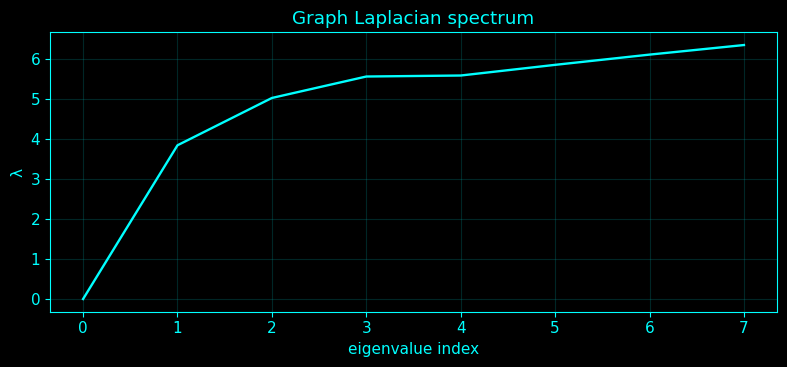

In [160]:
# Method 148: Graph Laplacian spectral topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_148():

    i = 148
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    W = S.copy()
    np.fill_diagonal(W, 0)
    Dg = np.diag(W.sum(1))
    L = Dg - W
    ev = np.linalg.eigvalsh((L + L.T) / 2)
    _plot_line(np.arange(len(ev)), ev, 'Normalized graph Laplacian spectrum' if i == 149 else 'Graph Laplacian spectrum', 'eigenvalue index', 'λ')
    return


_topology_method_148()
del _topology_method_148


### 149. Normalized graph Laplacian topology

The symmetric normalized graph Laplacian is \(L_{sym}=I-D^{-1/2}WD^{-1/2}\). Its spectrum lies in \([0,2]\) for nonnegative weights and reduces degree-scale effects relative to the combinatorial Laplacian.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


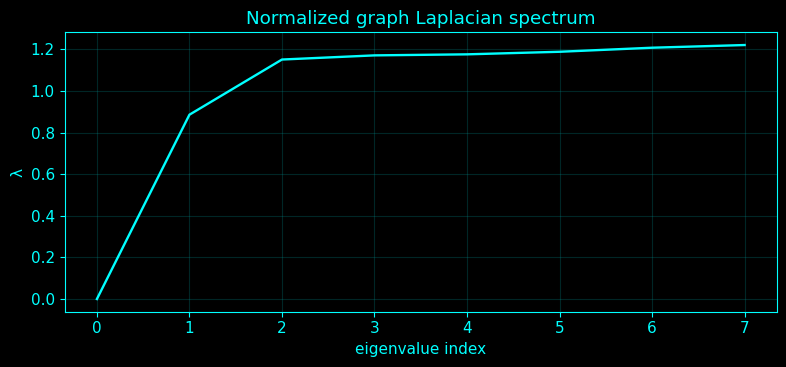

In [161]:
# Method 149: Normalized graph Laplacian topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_149():

    i = 149
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    W = S.copy()
    np.fill_diagonal(W, 0)
    Dg = np.diag(W.sum(1))
    L = Dg - W
    ds = np.sqrt(np.maximum(np.diag(Dg), TOPO_EPS))
    L = np.eye(len(W)) - W / np.outer(ds, ds)
    ev = np.linalg.eigvalsh((L + L.T) / 2)
    _plot_line(np.arange(len(ev)), ev, 'Normalized graph Laplacian spectrum' if i == 149 else 'Graph Laplacian spectrum', 'eigenvalue index', 'λ')
    return


_topology_method_149()
del _topology_method_149


### 150. Laplacian spectral gap analysis

The Laplacian spectral gap is the first positive eigenvalue above the zero eigenspace. For a connected graph this is \(\lambda_2\), and larger values generally indicate stronger global connectivity.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [162]:
# Method 150: Laplacian spectral gap analysis

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_150():

    i = 150
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    W = S.copy()
    np.fill_diagonal(W, 0)
    Dg = np.diag(W.sum(1))
    L = Dg - W
    ev = np.linalg.eigvalsh((L + L.T) / 2)
    print(('Laplacian spectral gap' if i == 150 else 'Algebraic connectivity λ2') + ' =', float(ev[1] if len(ev) > 1 else 0))
    return
    _plot_line(np.arange(len(ev)), ev, 'Normalized graph Laplacian spectrum' if i == 149 else 'Graph Laplacian spectrum', 'eigenvalue index', 'λ')
    return


_topology_method_150()
del _topology_method_150


Laplacian spectral gap = 3.8508746473734727


### 151. Algebraic connectivity topology

Algebraic connectivity is specifically \(\lambda_2(L)\) of the combinatorial graph Laplacian. It is zero exactly when the graph is disconnected (counting multiplicity of zero eigenvalues).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [163]:
# Method 151: Algebraic connectivity topology

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_151():

    i = 151
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    W = S.copy()
    np.fill_diagonal(W, 0)
    Dg = np.diag(W.sum(1))
    L = Dg - W
    ev = np.linalg.eigvalsh((L + L.T) / 2)
    print(('Laplacian spectral gap' if i == 150 else 'Algebraic connectivity λ2') + ' =', float(ev[1] if len(ev) > 1 else 0))
    return
    _plot_line(np.arange(len(ev)), ev, 'Normalized graph Laplacian spectrum' if i == 149 else 'Graph Laplacian spectrum', 'eigenvalue index', 'λ')
    return


_topology_method_151()
del _topology_method_151


Algebraic connectivity λ2 = 3.8508746473734727


### 152. Simplicial Hodge Laplacian

For oriented boundary matrices \(B_k:C_k\to C_{k-1}\), the k-Hodge Laplacian is \(L_k=B_k^TB_k+B_{k+1}B_{k+1}^T\). The discrete Hodge theorem gives \(\dim\ker L_k=\beta_k\) over the reals.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


,k,matrix_size,harmonic_dim
0,0,8,2
1,1,11,0
2,2,5,0


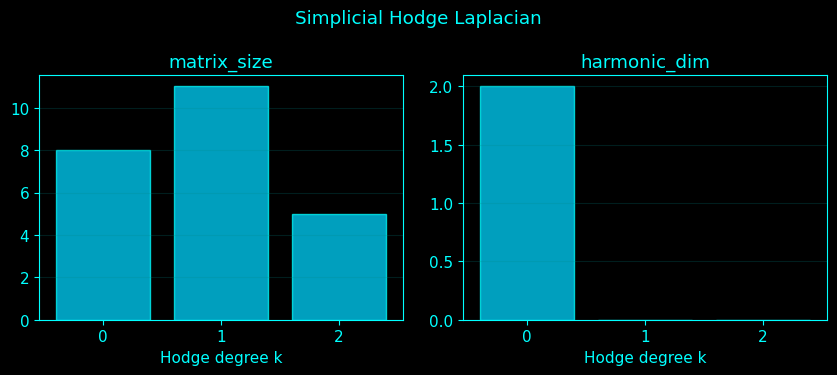

In [164]:
# Method 152: Simplicial Hodge Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_152():

    i = 152
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _null_basis_real(A,tol=1e-9):
        A=np.asarray(A,float)
        if A.size==0:return np.zeros((A.shape[1] if A.ndim==2 else 0,0))
        w,V=np.linalg.eigh((A+A.T)/2); t=tol*max(1.,float(np.max(np.abs(w))) if len(w) else 1.); return V[:,np.abs(w)<=t]

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    out = pd.DataFrame({'k': [0, 1, 2], 'matrix_size': [L0.shape[0], L1.shape[0], L2.shape[0]], 'harmonic_dim': [_null_basis_real(L0).shape[1], _null_basis_real(L1).shape[1], _null_basis_real(L2).shape[1]]})
    display(out)
    fig, axs = plt.subplots(1, 2, figsize=(8.5, 3.8), facecolor=TOPO_BG)
    for ax, col in zip(axs, ['matrix_size', 'harmonic_dim']):
        ax.bar(out['k'].astype(str), out[col], color=TOPO_CYAN_FILL, edgecolor=TOPO_ACCENT, alpha=0.75)
        ax.set_title(col)
        ax.set_xlabel('Hodge degree k')
        ax.grid(True, axis='y', color=TOPO_CYAN_DIM, alpha=0.22)
    fig.suptitle('Simplicial Hodge Laplacian')
    plt.tight_layout()
    plt.show()
    return
    L = {153: L0, 154: L1, 155: L2}[i]
    ev = np.linalg.eigvalsh((L + L.T) / 2) if L.size else np.array([])
    _plot_line(np.arange(len(ev)), ev, f'{i - 153}-Hodge Laplacian spectrum', 'index', 'λ')
    return


_topology_method_152()
del _topology_method_152


### 153. 0-Hodge Laplacian

The 0-Hodge Laplacian is \(L_0=B_1B_1^T\), identical to the unweighted graph Laplacian of the 1-skeleton. Its harmonic dimension equals \(\beta_0\).

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


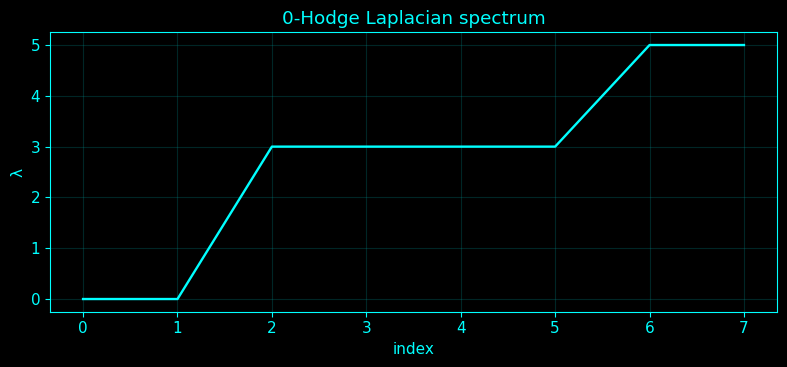

In [165]:
# Method 153: 0-Hodge Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_153():

    i = 153
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    L = {153: L0, 154: L1, 155: L2}[i]
    ev = np.linalg.eigvalsh((L + L.T) / 2) if L.size else np.array([])
    _plot_line(np.arange(len(ev)), ev, f'{i - 153}-Hodge Laplacian spectrum', 'index', 'λ')
    return


_topology_method_153()
del _topology_method_153


### 154. 1-Hodge Laplacian

The 1-Hodge Laplacian is \(L_1=B_1^TB_1+B_2B_2^T\). The lower term penalizes divergence and the upper term penalizes curl around triangles; its nullspace consists of harmonic representatives of H1.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Statistical significance should be read relative to the stated null model and testing procedure; it is strongest when accompanied by an effect size, uncertainty estimate, and correction for the number of comparisons when many tests are run.</p></div>


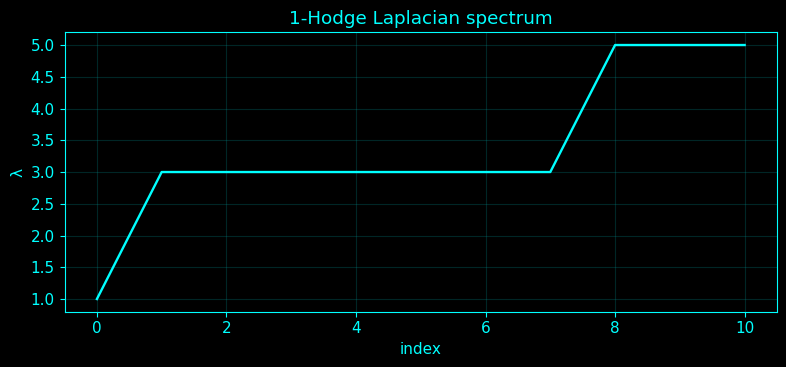

In [166]:
# Method 154: 1-Hodge Laplacian

# Self-contained mathematical implementation. Shared catalogue cells provide only constants/imports/raw input.

def _topology_method_154():

    i = 154
    # Method-local preprocessing: no mathematical state is reused from another catalogue method.
    _topo_local_raw = np.asarray(_topo_raw[:_TOPO_SPEED['max_samples']], float)
    _topo_local_raw = signal.detrend(_topo_local_raw, axis=0, type='constant')
    _topo_down = int(_TOPO_SPEED['down'])
    _topo_x = (
        signal.resample_poly(_topo_local_raw, up=1, down=_topo_down, axis=0)
        if _topo_down > 1 else _topo_local_raw.copy()
    )
    _topo_fs = _topo_fs0 / _topo_down
    _topo_x = (
        _topo_x - np.nanmean(_topo_x, axis=0, keepdims=True)
    ) / (
        np.nanstd(_topo_x, axis=0, keepdims=True) + TOPO_EPS
    )
    _topo_names = _TOPO_NAMES[:_topo_x.shape[1]]
    _topo_pc1 = PCA(n_components=1).fit_transform(_topo_x).ravel()

    # Method-local mathematical definitions required by this cell only.
    def _channel_similarity(nch=None):
        if nch is None:nch=min(_topo_x.shape[1],12 if FAST_OPTION=='full' else 10 if FAST_OPTION=='balanced' else 9 if FAST_OPTION=='fast' else 8)
        return np.abs(np.nan_to_num(np.corrcoef(_topo_x[:,:nch].T)))

    def _boundary_matrix(low,high):
        il={s:i for i,s in enumerate(low)}; B=np.zeros((len(low),len(high)),float)
        for j,s in enumerate(high):
            for q in range(len(s)):
                face=s[:q]+s[q+1:]; B[il[face],j]=(-1.)**q
        return B

    def _complex_boundaries(simp):
        B1=_boundary_matrix(simp[0],simp.get(1,[])); B2=_boundary_matrix(simp.get(1,[]),simp.get(2,[])); B3=_boundary_matrix(simp.get(2,[]),simp.get(3,[])); return B1,B2,B3

    def _flag_simplices_similarity(S,quantile=.60,maxdim=3):
        S=np.asarray(S,float); n=len(S); vals=S[np.triu_indices(n,1)]; th=float(np.quantile(vals,quantile)); A=S>=th; np.fill_diagonal(A,False)
        simplices={0:[(i,) for i in range(n)]}
        simplices[1]=[(i,j) for i in range(n) for j in range(i+1,n) if A[i,j]]
        if maxdim>=2:
            simplices[2]=[(i,j,k) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) if A[i,j] and A[i,k] and A[j,k]]
        if maxdim>=3:
            simplices[3]=[(i,j,k,l) for i in range(n) for j in range(i+1,n) for k in range(j+1,n) for l in range(k+1,n) if all(A[a,b] for a,b in combinations((i,j,k,l),2))]
        return simplices,A,th

    def _hodge_laplacians(B1,B2,B3):
        L0=B1@B1.T
        L1=B1.T@B1 + B2@B2.T
        L2=B2.T@B2 + B3@B3.T
        return L0,L1,L2

    def _plot_line(x,y,title,xlabel='x',ylabel='value'):
        fig,ax=plt.subplots(figsize=(8,3.8),facecolor=TOPO_BG)
        ax.plot(x,y,color=TOPO_ACCENT,lw=1.7)
        ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
        ax.grid(True,color=TOPO_CYAN_DIM,alpha=.28,linewidth=.8)
        for spine in ax.spines.values(): spine.set_color(TOPO_ACCENT)
        plt.tight_layout(); plt.show()

    # Method mathematics and output.
    S = _channel_similarity()
    simp, A, th = _flag_simplices_similarity(S, 0.6, 3)
    B1, B2, B3 = _complex_boundaries(simp)
    L0, L1, L2 = _hodge_laplacians(B1, B2, B3)
    L = {153: L0, 154: L1, 155: L2}[i]
    ev = np.linalg.eigvalsh((L + L.T) / 2) if L.size else np.array([])
    _plot_line(np.arange(len(ev)), ev, f'{i - 153}-Hodge Laplacian spectrum', 'index', 'λ')
    return


_topology_method_154()
del _topology_method_154


### 155. 2-Hodge Laplacian

The 2-Hodge Laplacian is \(L_2=B_2^TB_2+B_3B_3^T\). Its kernel represents H2 classes when tetrahedra are included in the complex.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>
